In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc
from scipy.fft import fft, fftfreq

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])



import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [2]:
# Open processed files
from open_data import *

In [3]:
data20 = processed_data_20cm
data30 = processed_data_30cm

In [4]:
freqs20 = list(data20.keys())
volts20 = []

for i in range(len(freqs20)):
    volts20.append(list(data20[freqs20[i]].keys()))

In [5]:
freqs30 = list(data30.keys())
volts30 = []

for i in range(len(freqs30)):
    volts30.append(list(data30[freqs30[i]].keys()))

In [41]:
def plot_fft(p0_r1, p0_r2, p0_r3):
    fs = 250  # sample rate [Hz]

    # --- FFT of run 1 ---
    n_r1 = len(p0_r1)
    fft_r1 = fft(p0_r1)
    freqs_r1 = fftfreq(n_r1, d=1/fs)

    mask_r1 = freqs_r1 >= 0
    freqs_r1 = freqs_r1[mask_r1]
    amp0_r1 = (2.0 / n_r1) * np.abs(fft_r1[mask_r1])  # single-sided amplitude spectrum

    # --- FFT of run 2 ---
    n_r2 = len(p0_r2)
    fft_r2 = fft(p0_r2)
    freqs_r2 = fftfreq(n_r2, d=1/fs)

    mask_r2 = freqs_r2 >= 0
    freqs_r2 = freqs_r2[mask_r2]
    amp0_r2 = (2.0 / n_r2) * np.abs(fft_r2[mask_r2])

    # --- FFT of run 3 ---
    n_r3 = len(p0_r3)
    fft_r3 = fft(p0_r3)
    freqs_r3 = fftfreq(n_r3, d=1/fs)

    mask_r3 = freqs_r3 >= 0
    freqs_r3 = freqs_r3[mask_r3]
    amp0_r3 = (2.0 / n_r3) * np.abs(fft_r3[mask_r3])

    # --- Plot ---
    plt.figure(figsize=(8, 4))
    plt.plot(freqs_r1, amp0_r1, label=r'R1')
    plt.plot(freqs_r2, amp0_r2, label=r'R2')
    plt.plot(freqs_r3, amp0_r3, label=r'R3')

    # Dominant peak(s) for each run
    peak_freqs_r1 = freqs_r1[np.argsort(amp0_r1)[-1:]]
    peak_freqs_r2 = freqs_r2[np.argsort(amp0_r2)[-1:]]
    peak_freqs_r3 = freqs_r3[np.argsort(amp0_r3)[-1:]]

    textstr = (
        f"R1 peak: {peak_freqs_r1.round(2)} Hz\n"
        f"R2 peak: {peak_freqs_r2.round(2)} Hz\n"
        f"R3 peak: {peak_freqs_r3.round(2)} Hz"
    )
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(
        0.95, 0.95, textstr,
        transform=plt.gca().transAxes,
        fontsize=10,
        va='top', ha='right',
        bbox=props
    )

    plt.xlabel(r'Frequency [Hz]')
    plt.ylabel(r'Amplitude')
    plt.xlim(0, 10)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.title(f'FFT of $P_0$, f = {f} Hz, A= {v} V, No Plates')
    plt.show()
    fr = str(f).replace(".", "")
    vo = str(v).replace(".", "")
    plt.savefig(f'/Users/kjesta/Desktop/Master prosjekt/Figurer/fft_checks/fft_f{fr}_a{vo}_no_plates.png', dpi=200)

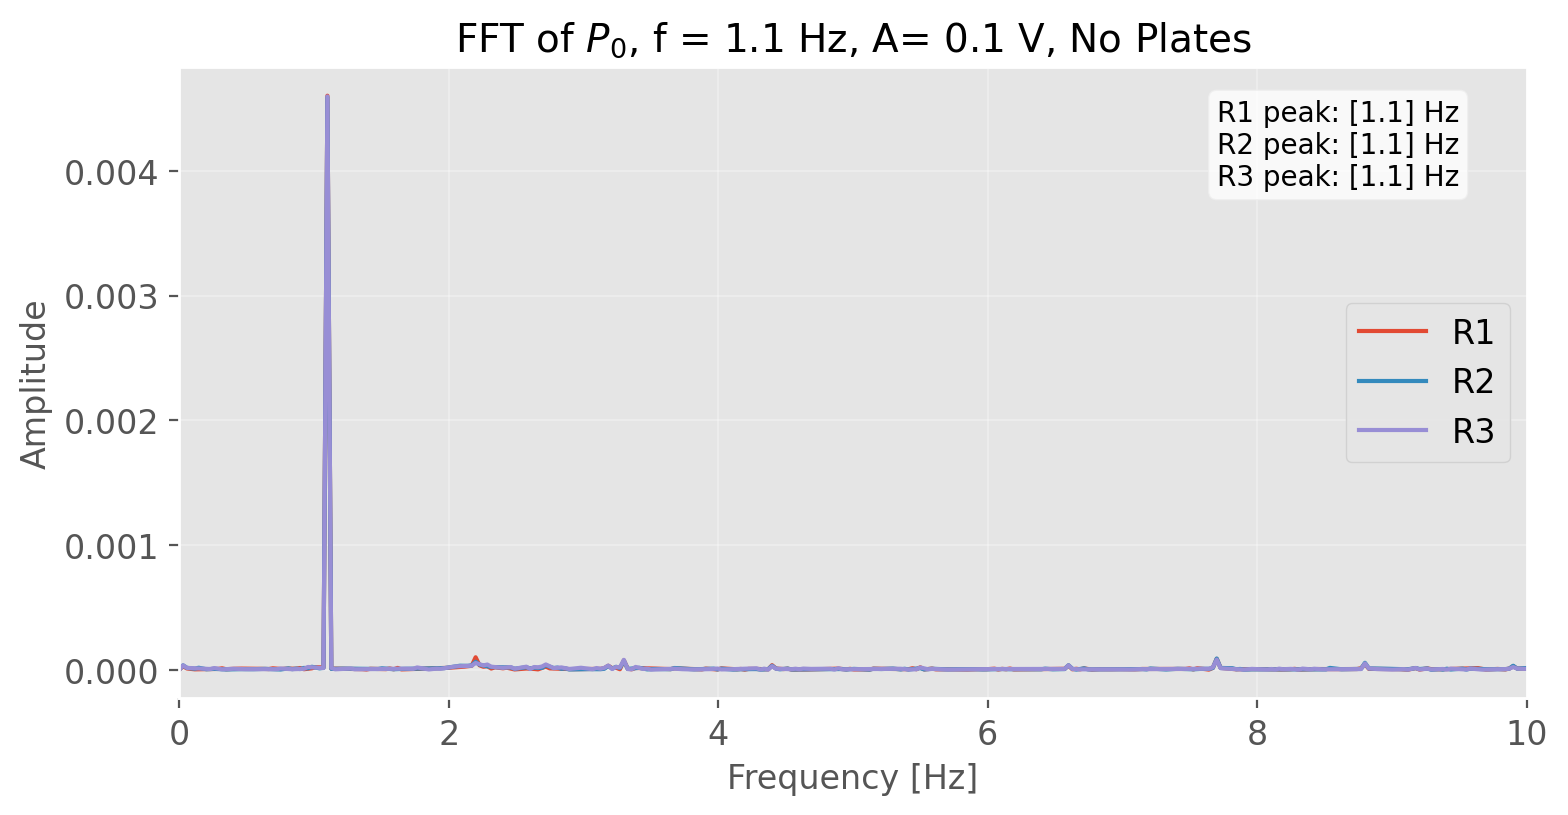

<Figure size 1280x960 with 0 Axes>

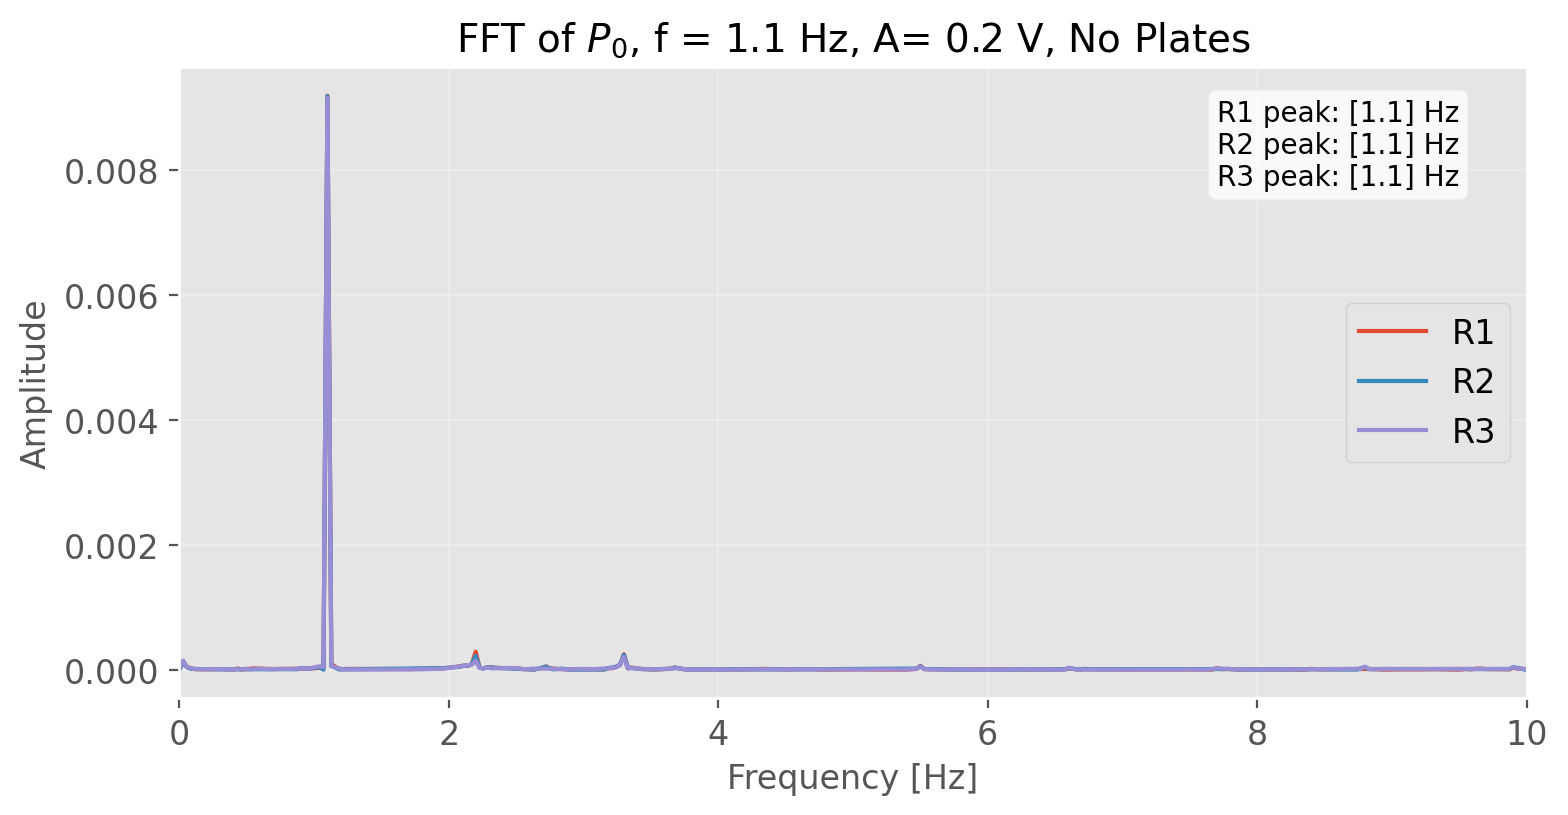

<Figure size 1280x960 with 0 Axes>

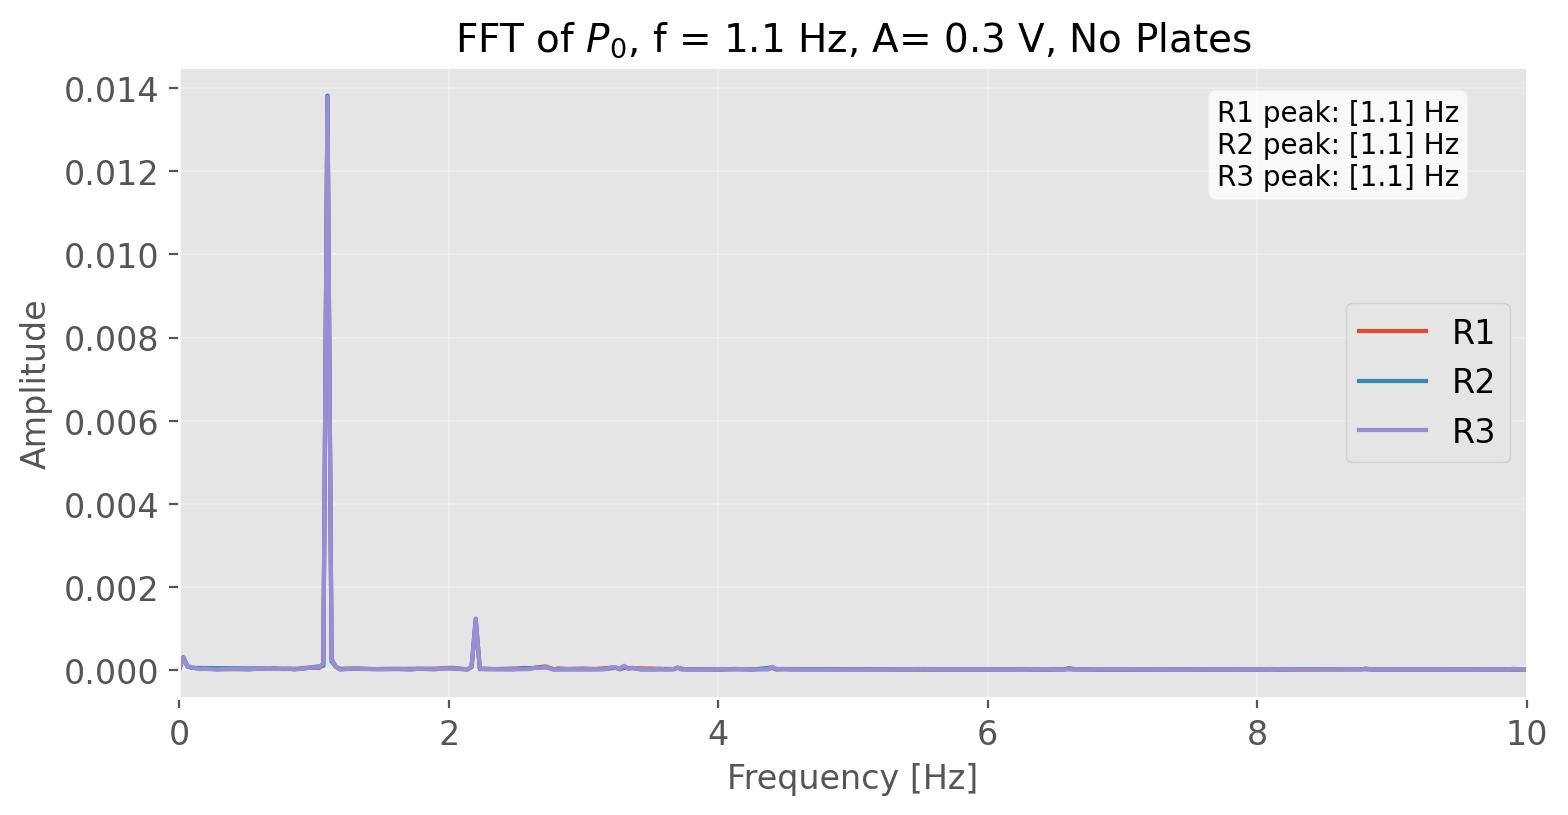

<Figure size 1280x960 with 0 Axes>

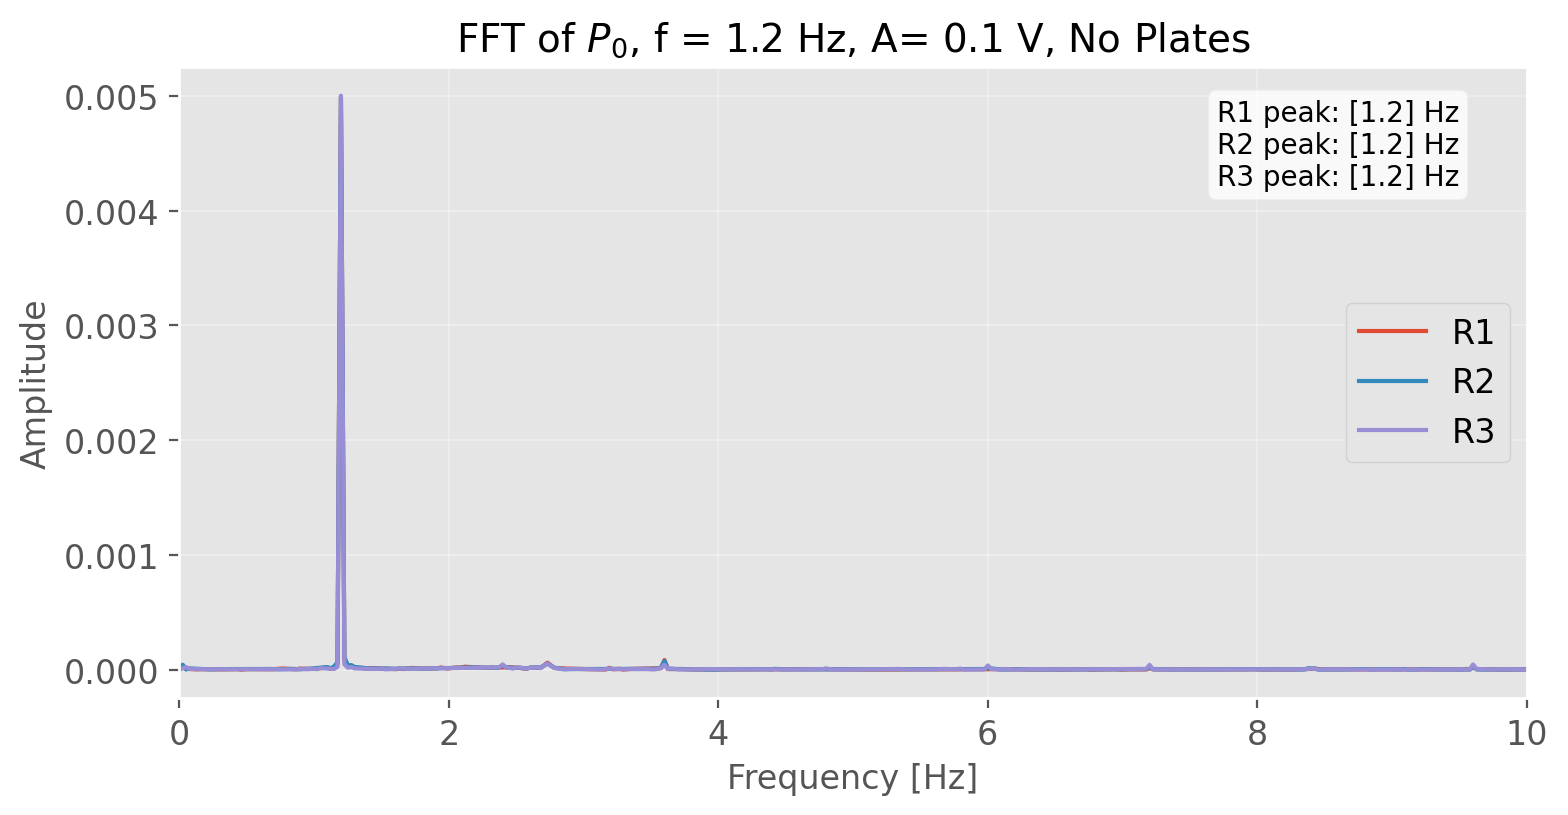

<Figure size 1280x960 with 0 Axes>

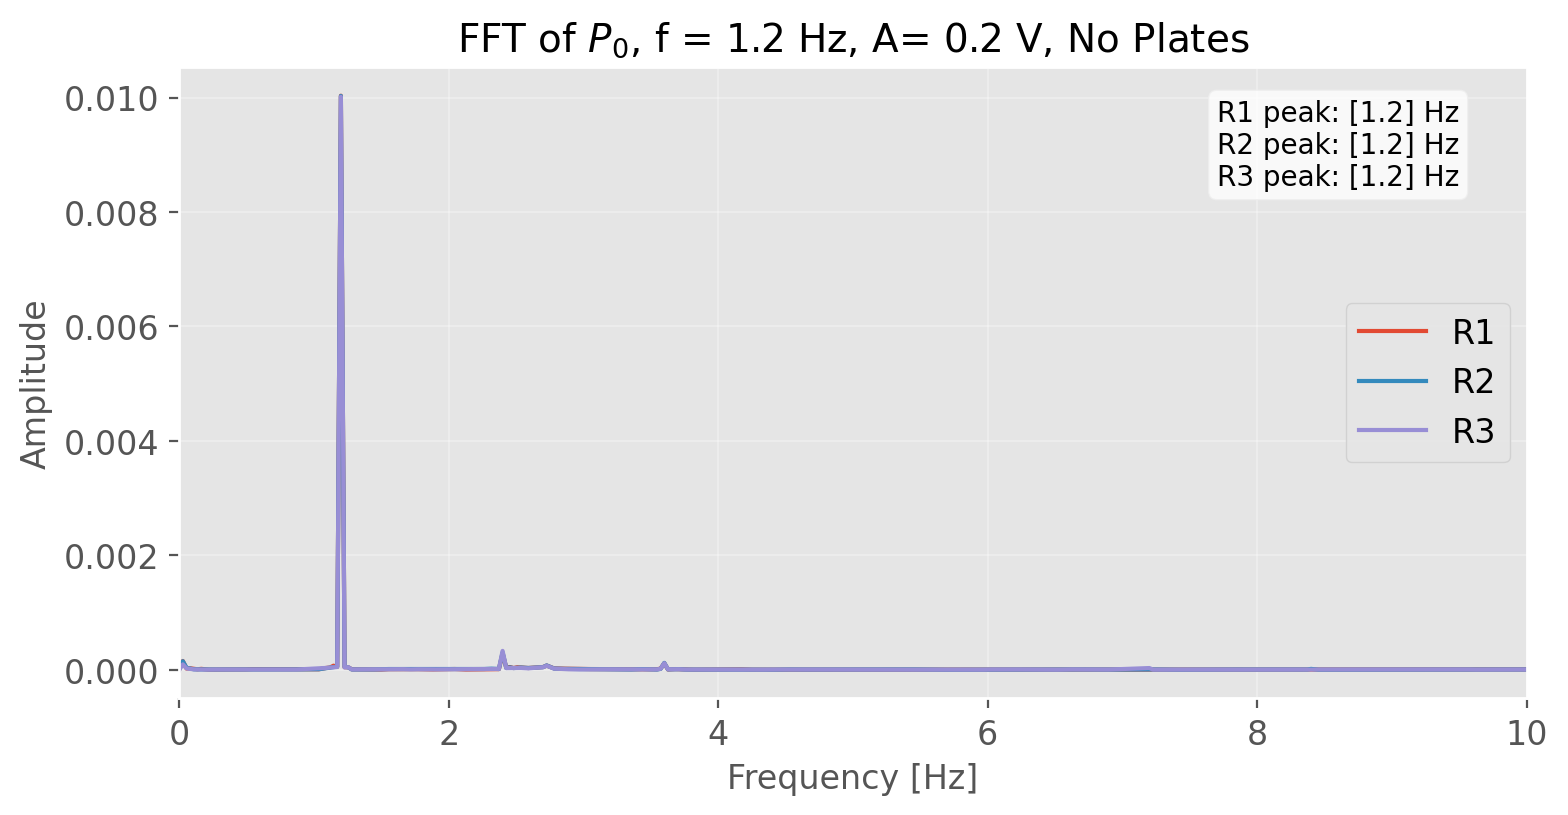

<Figure size 1280x960 with 0 Axes>

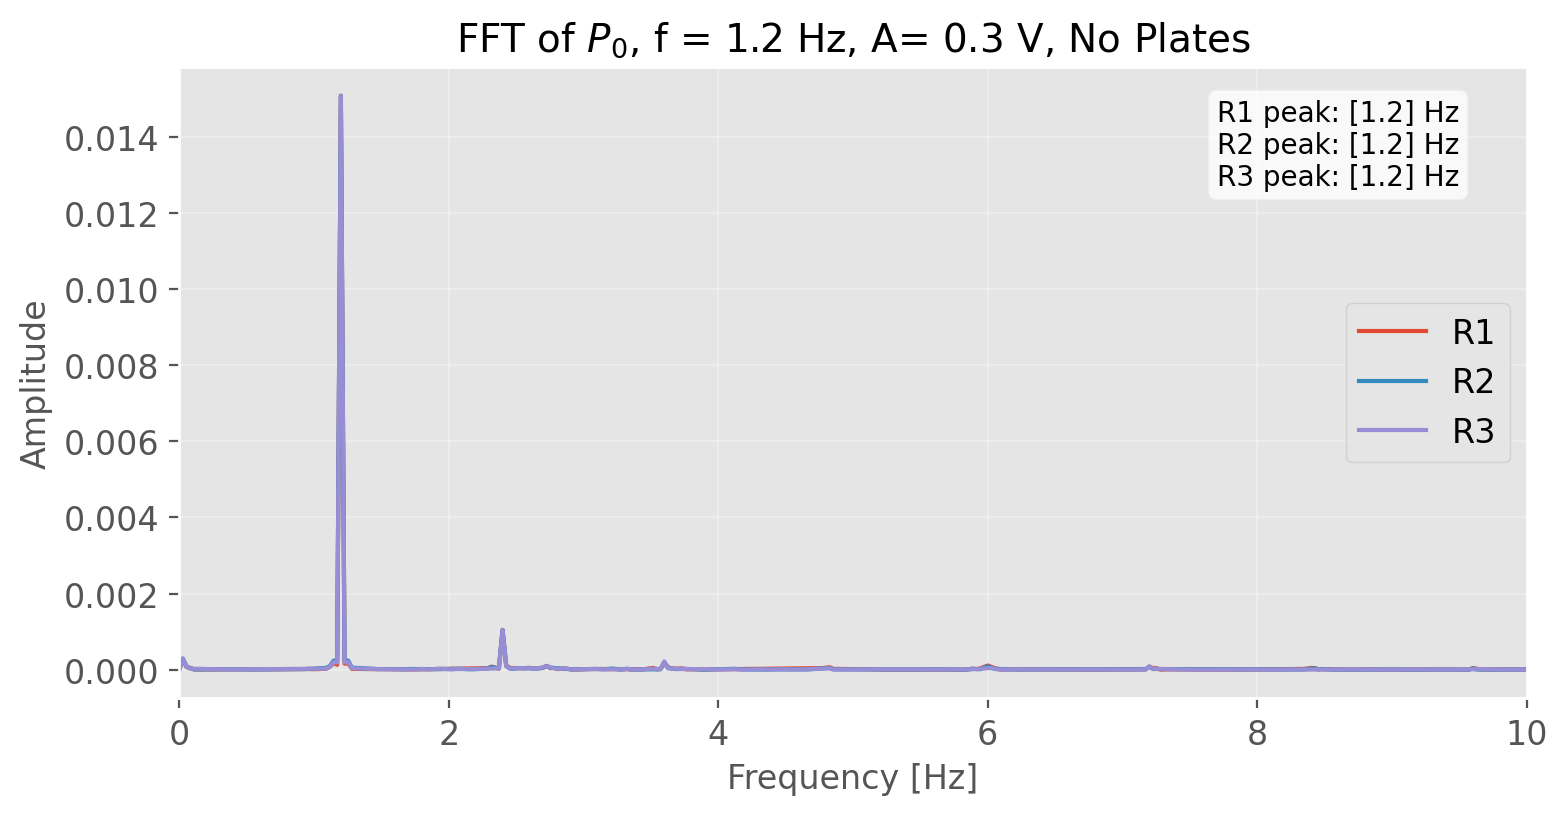

<Figure size 1280x960 with 0 Axes>

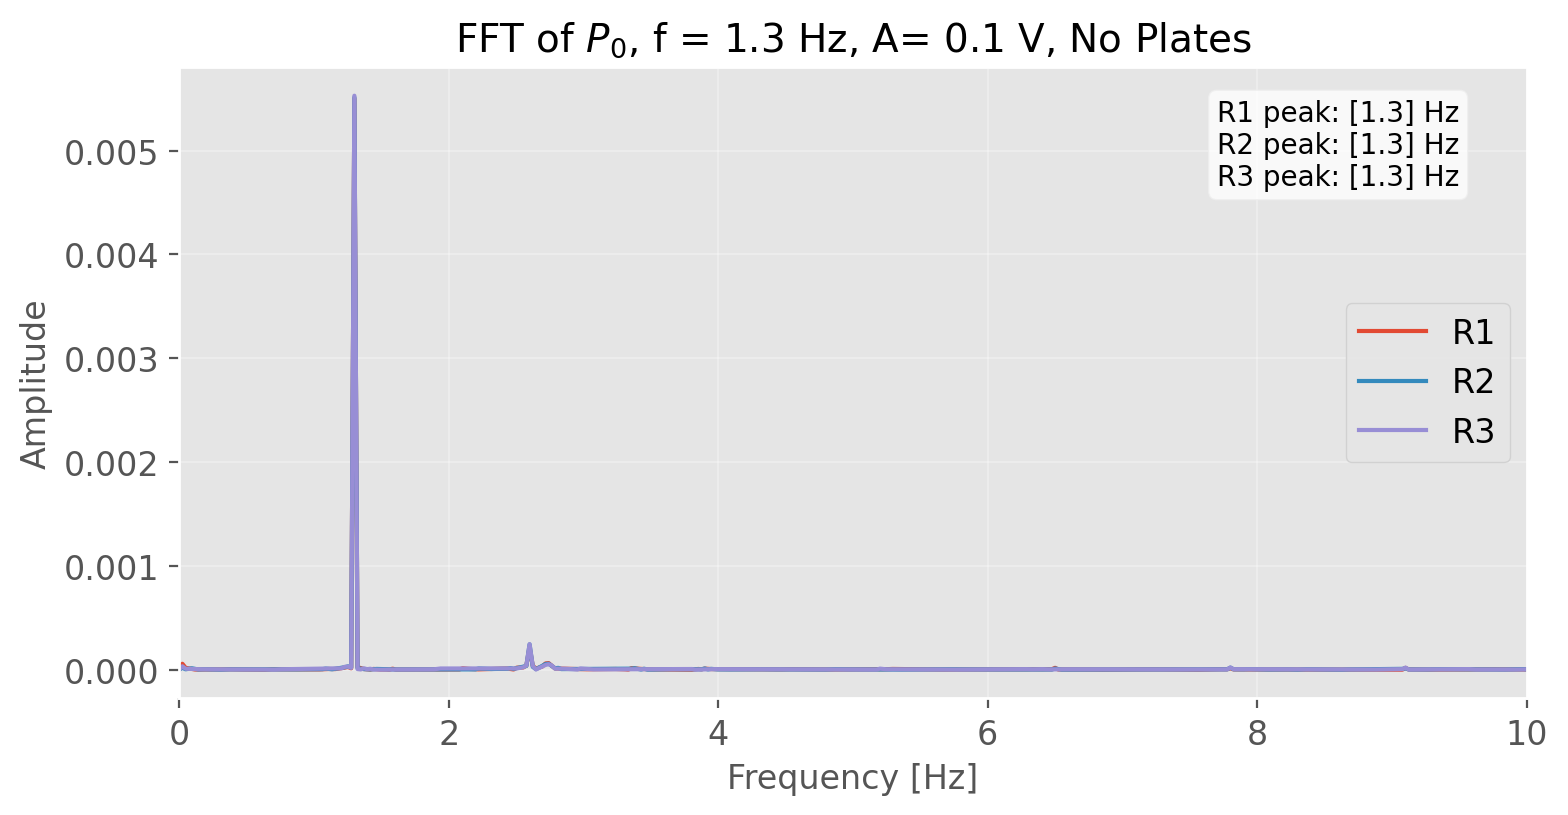

<Figure size 1280x960 with 0 Axes>

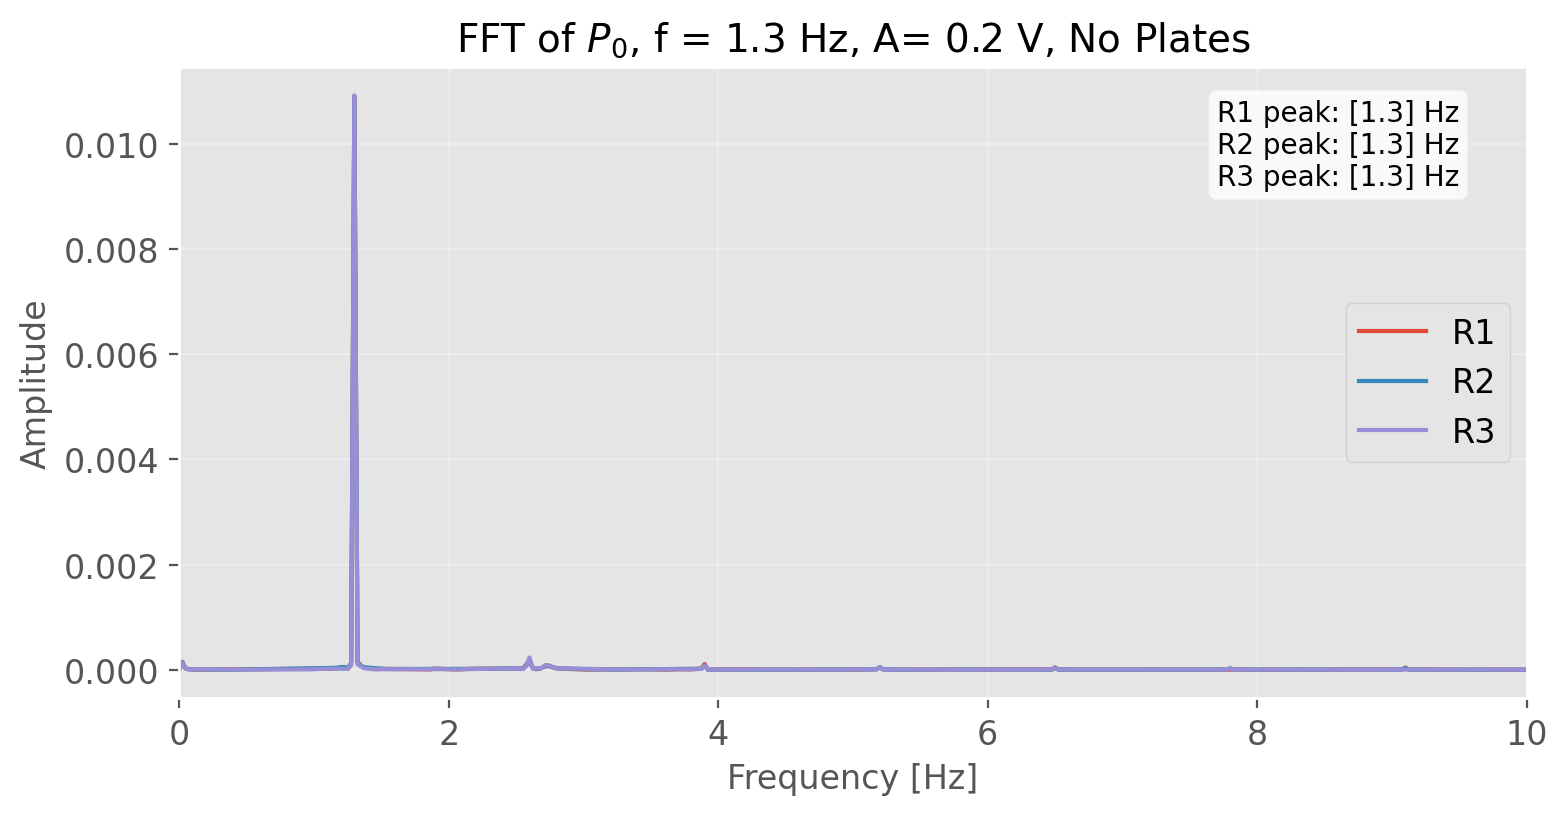

<Figure size 1280x960 with 0 Axes>

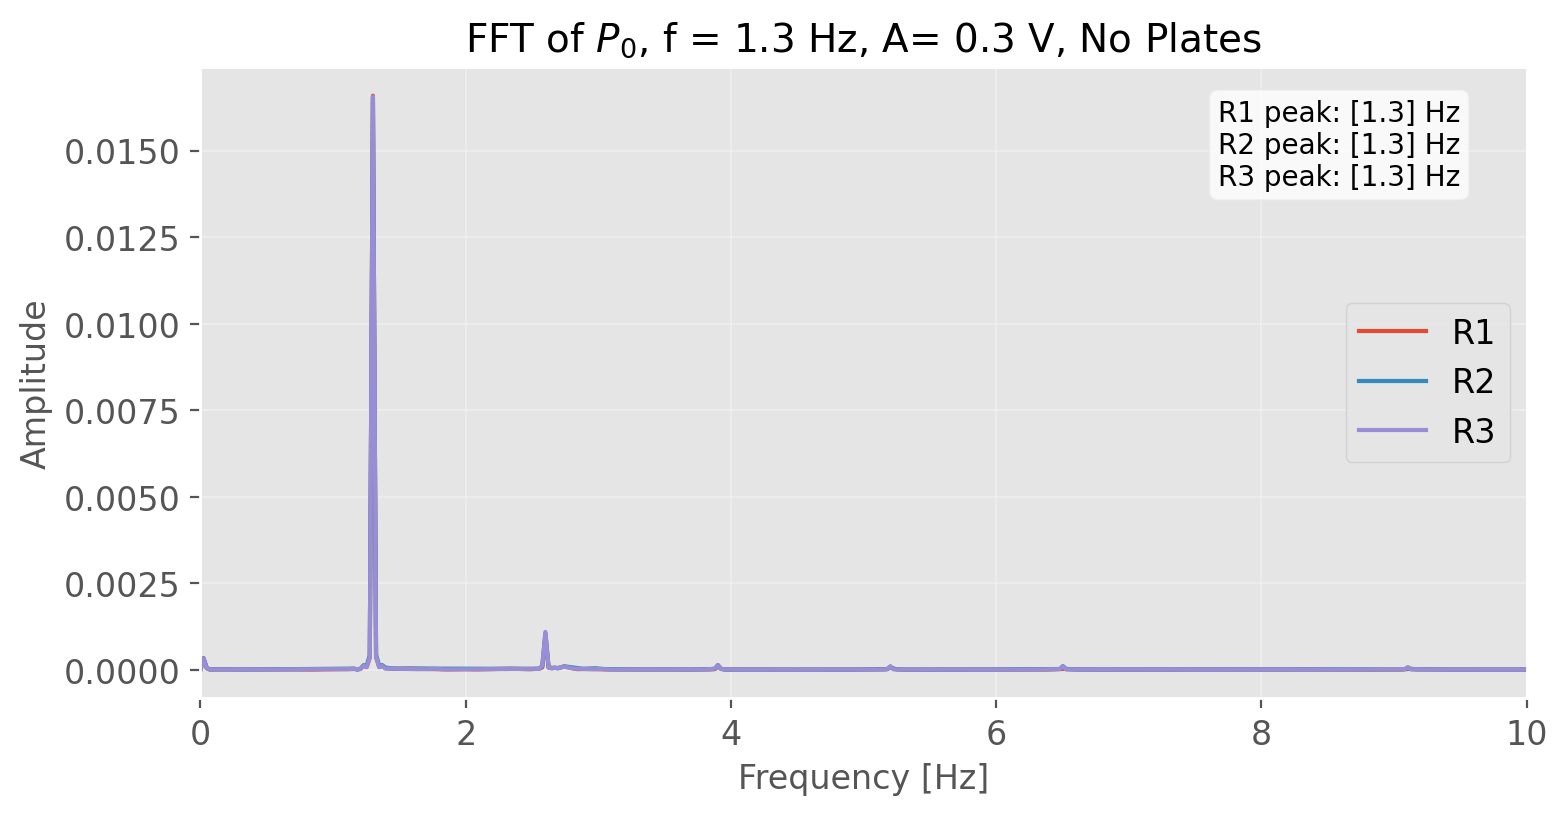

<Figure size 1280x960 with 0 Axes>

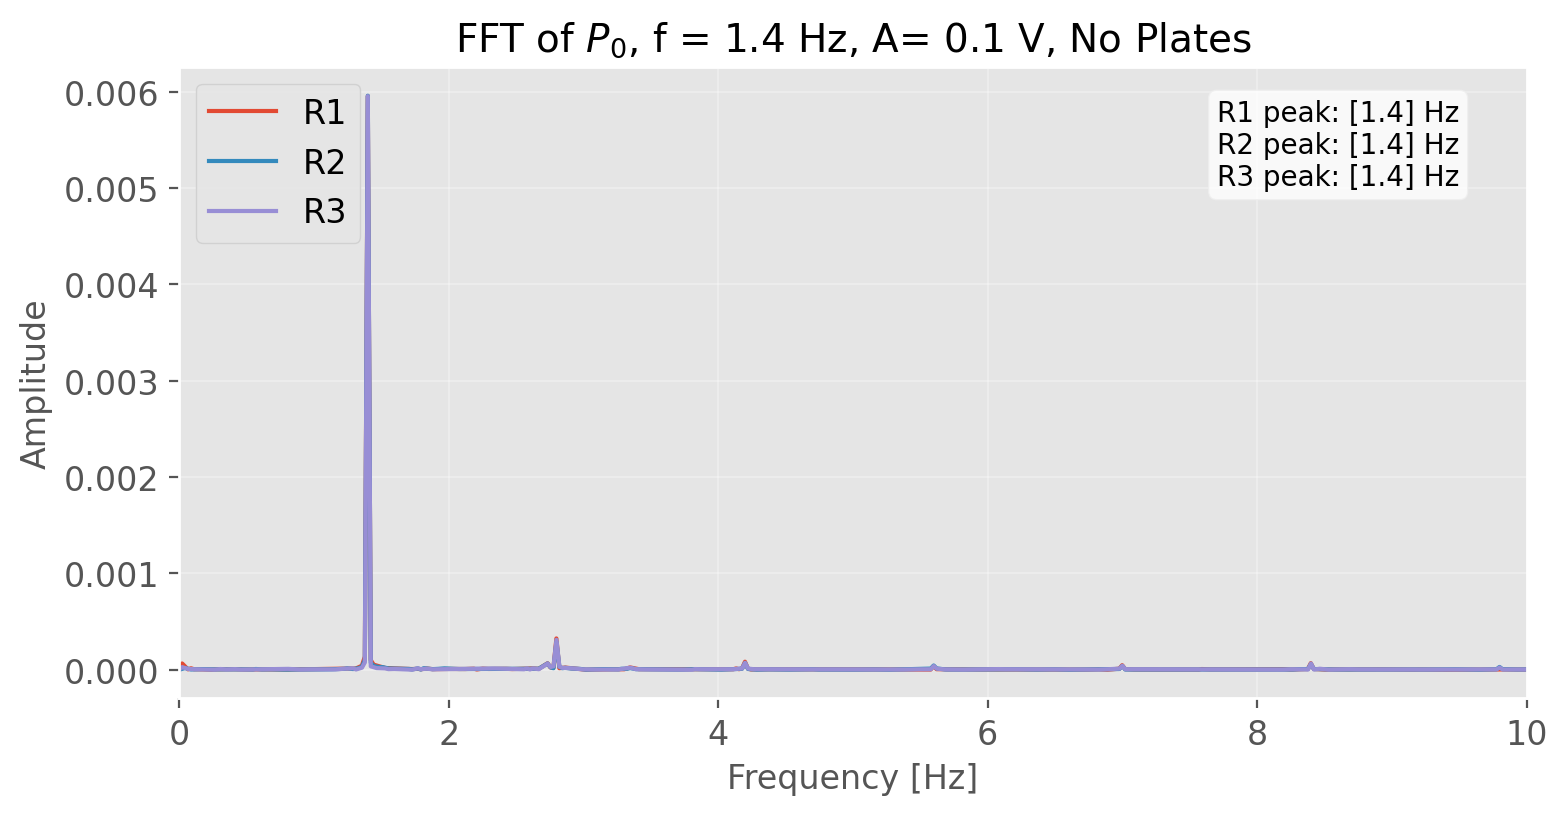

<Figure size 1280x960 with 0 Axes>

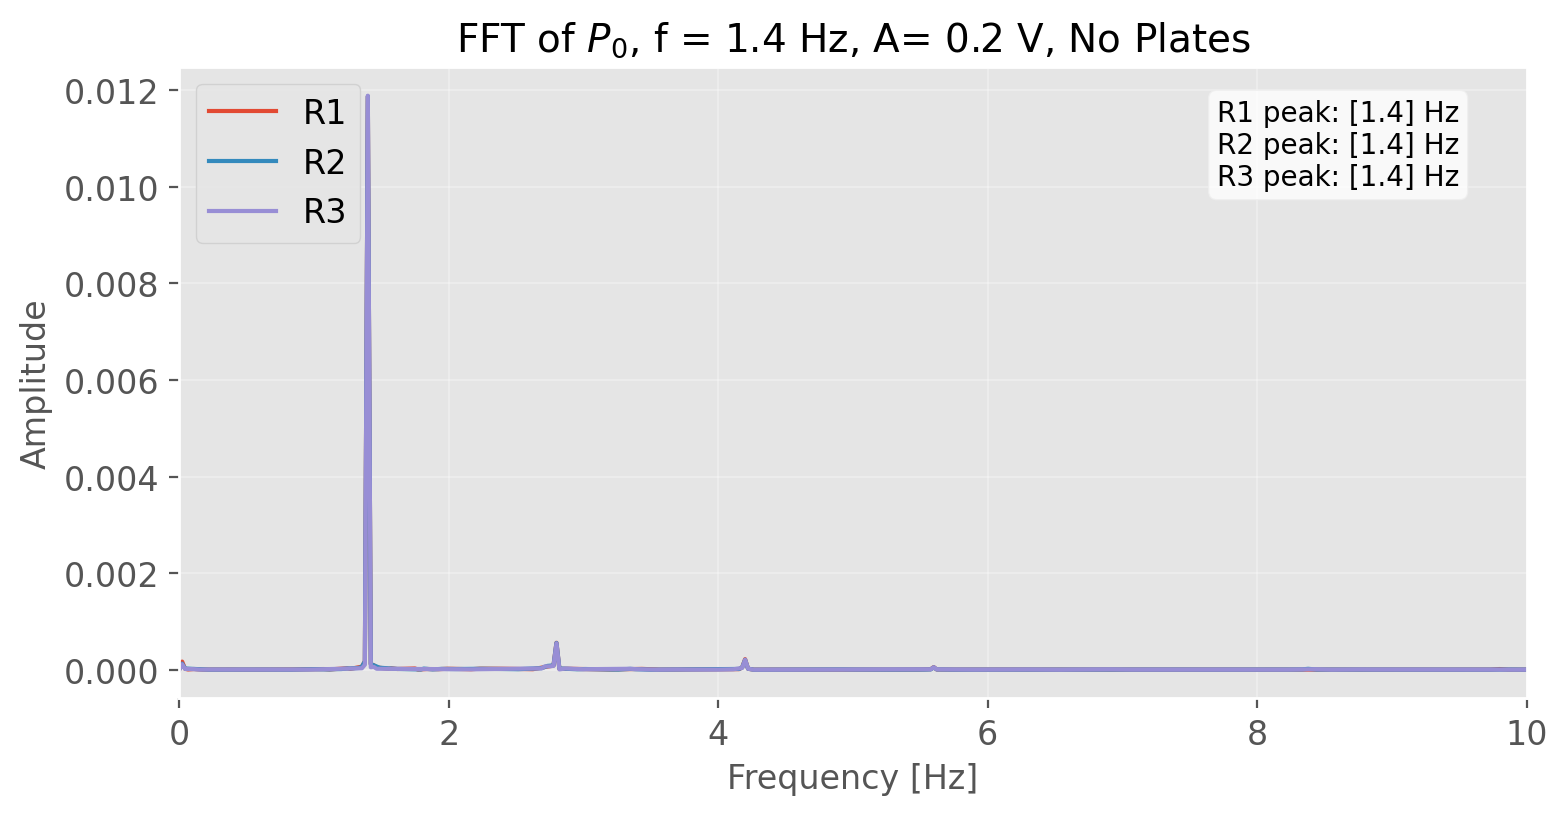

<Figure size 1280x960 with 0 Axes>

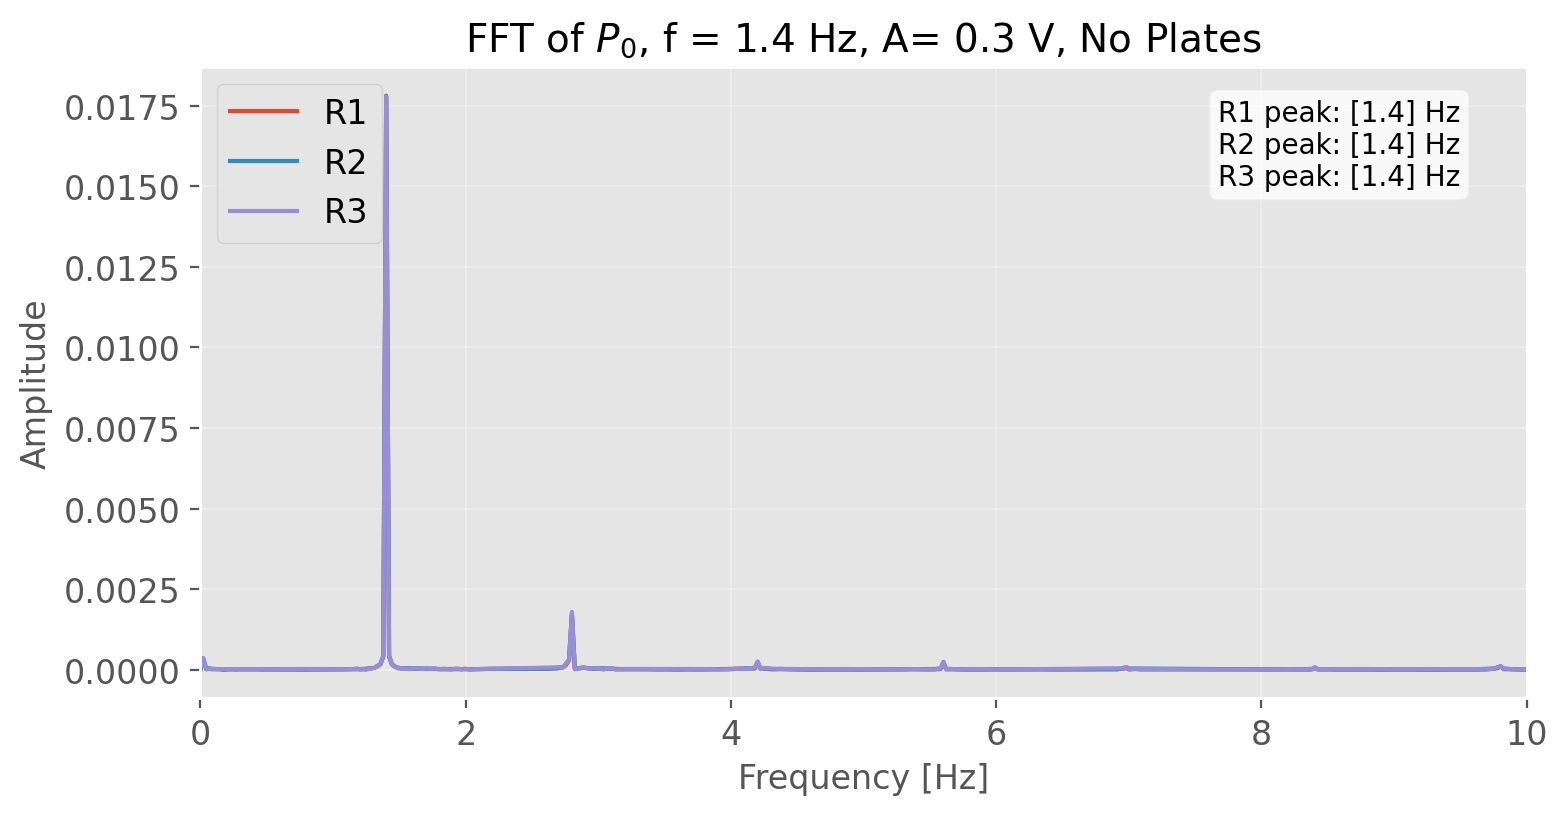

<Figure size 1280x960 with 0 Axes>

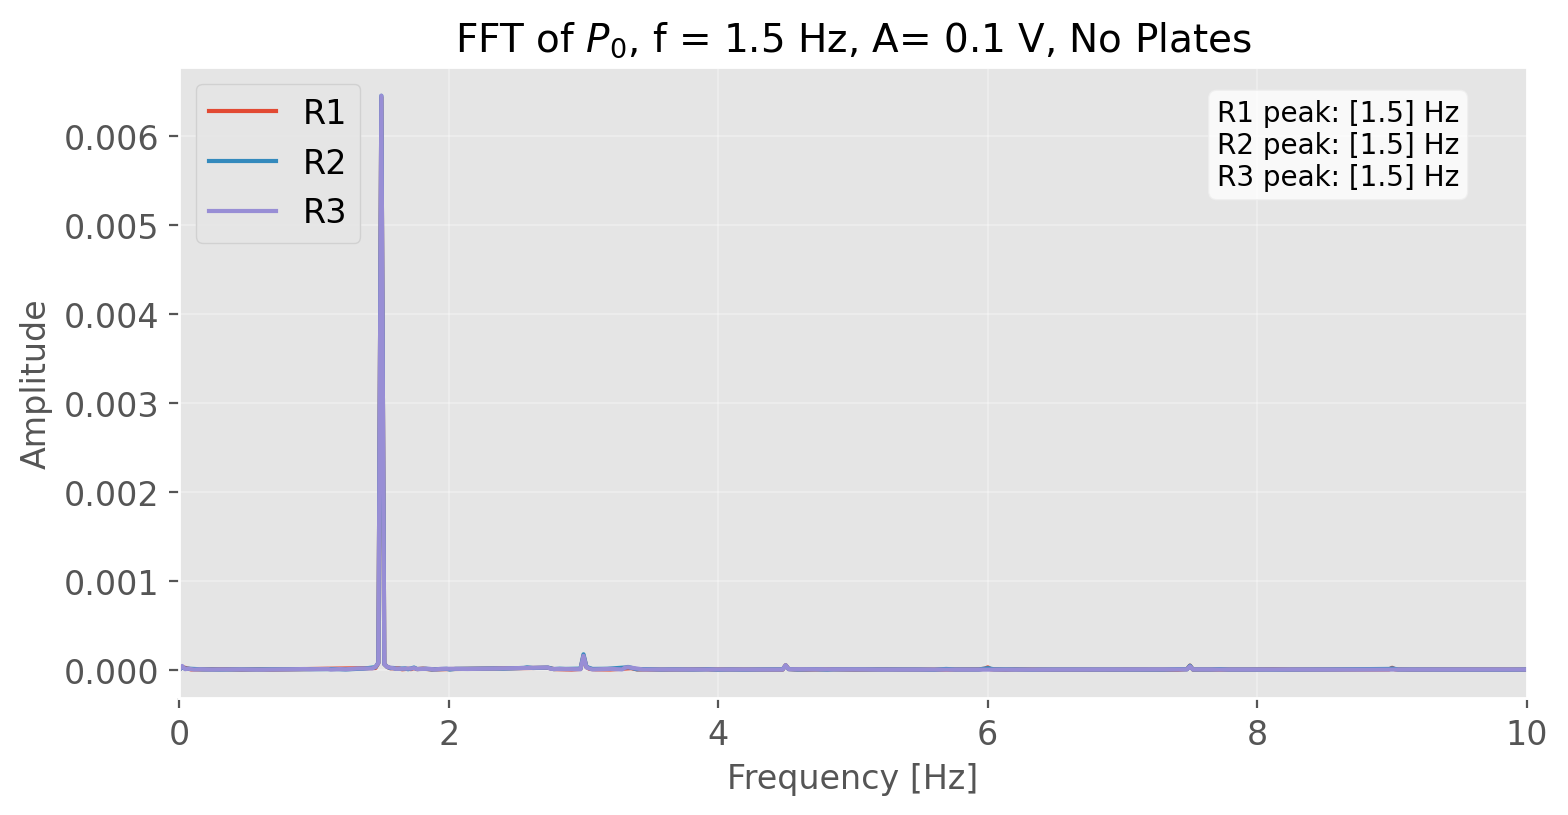

<Figure size 1280x960 with 0 Axes>

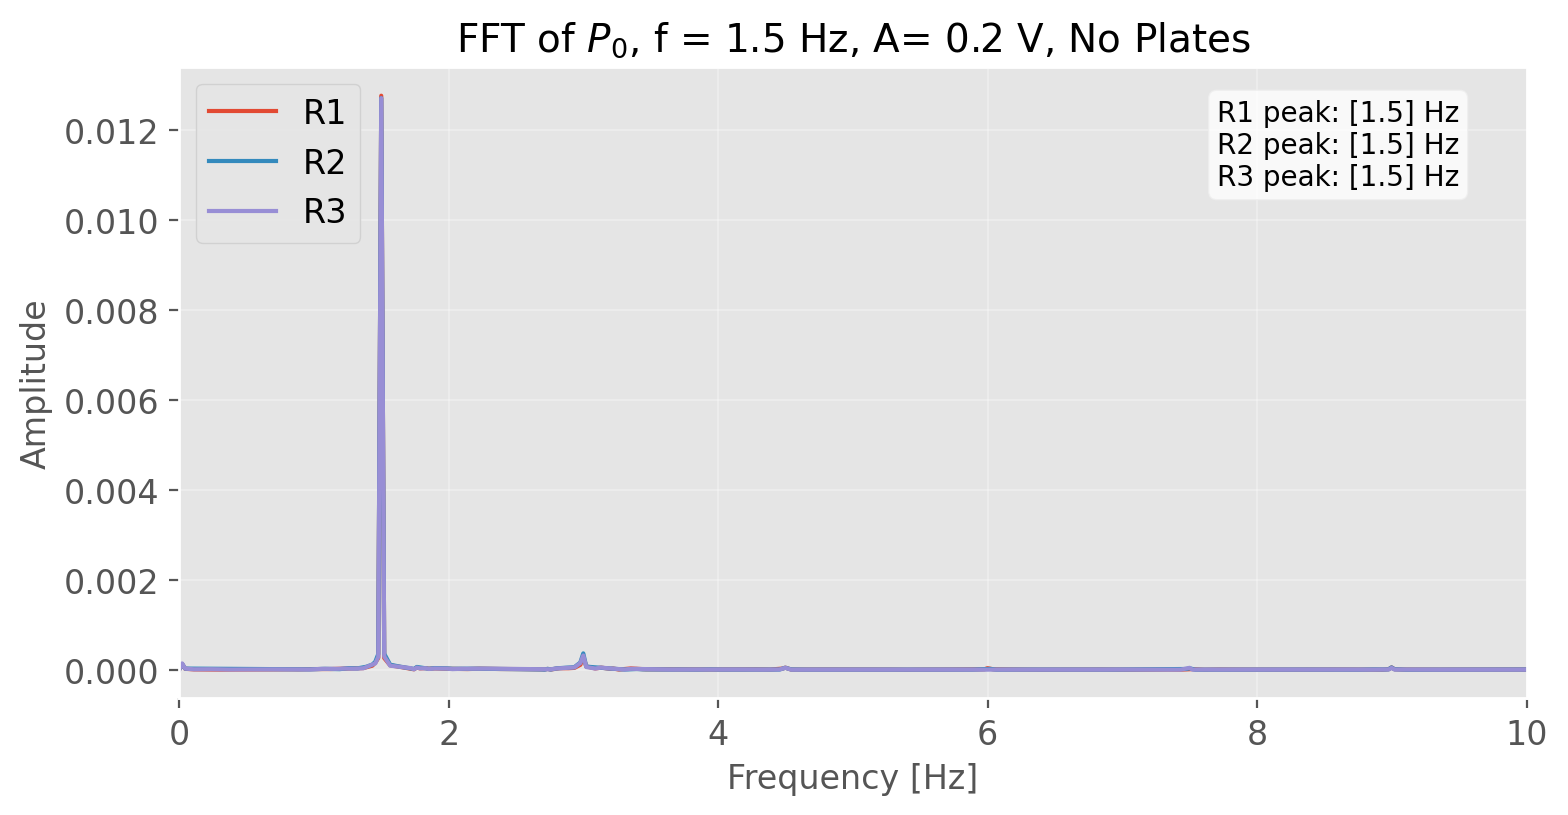

<Figure size 1280x960 with 0 Axes>

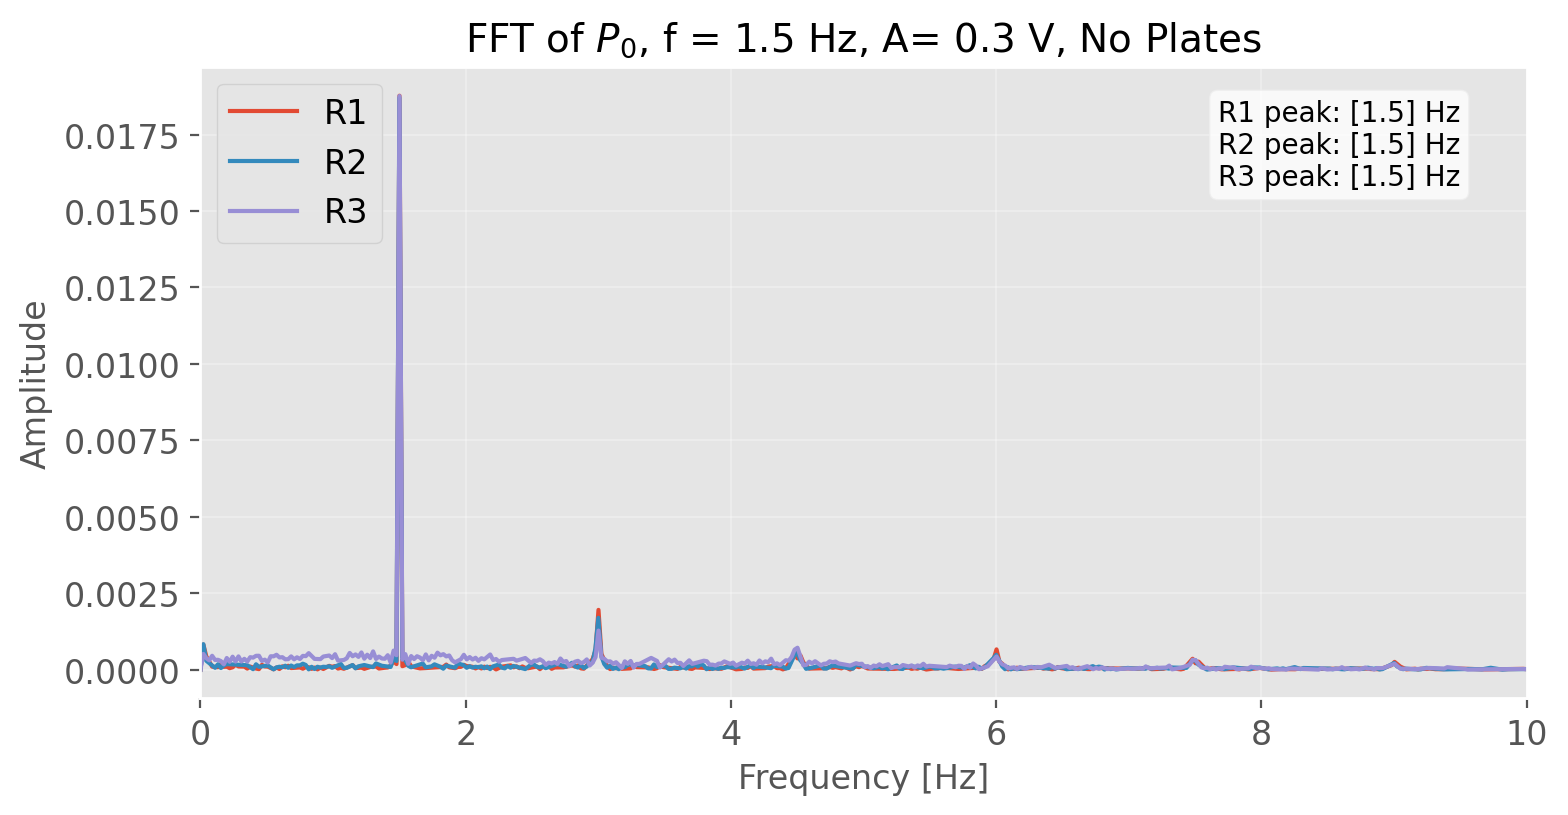

<Figure size 1280x960 with 0 Axes>

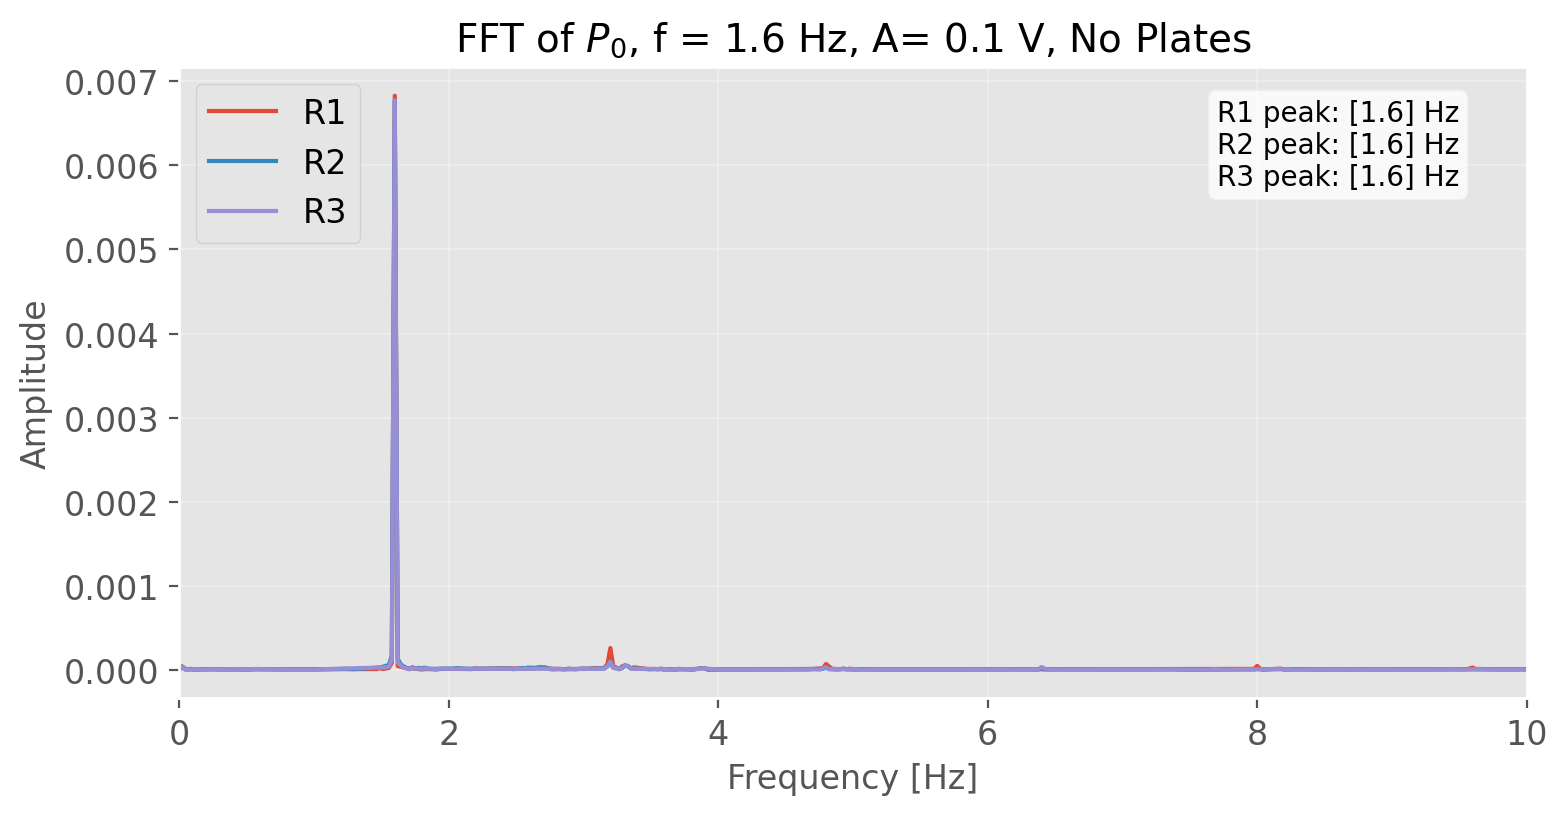

<Figure size 1280x960 with 0 Axes>

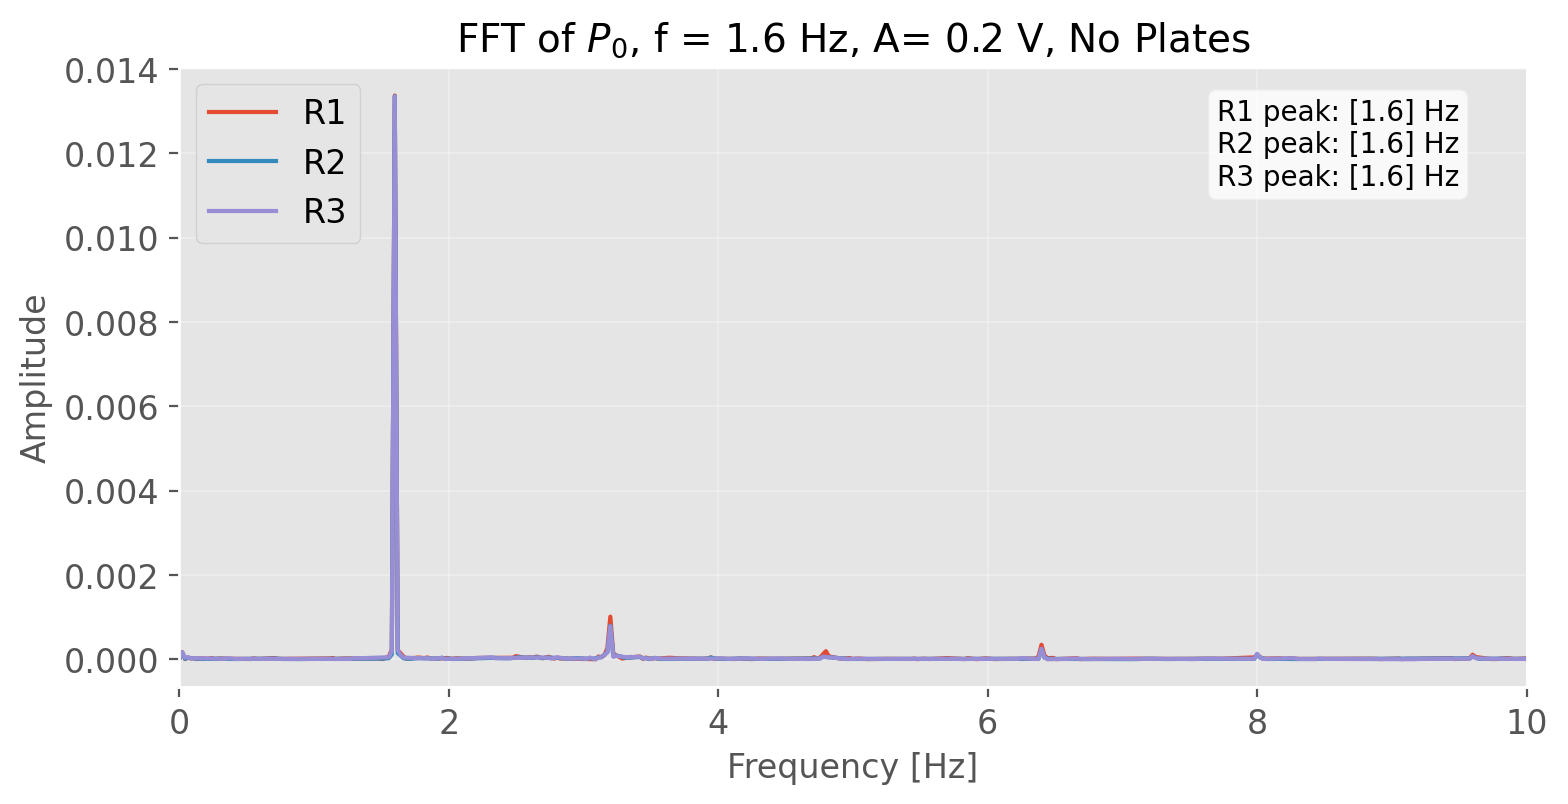

<Figure size 1280x960 with 0 Axes>

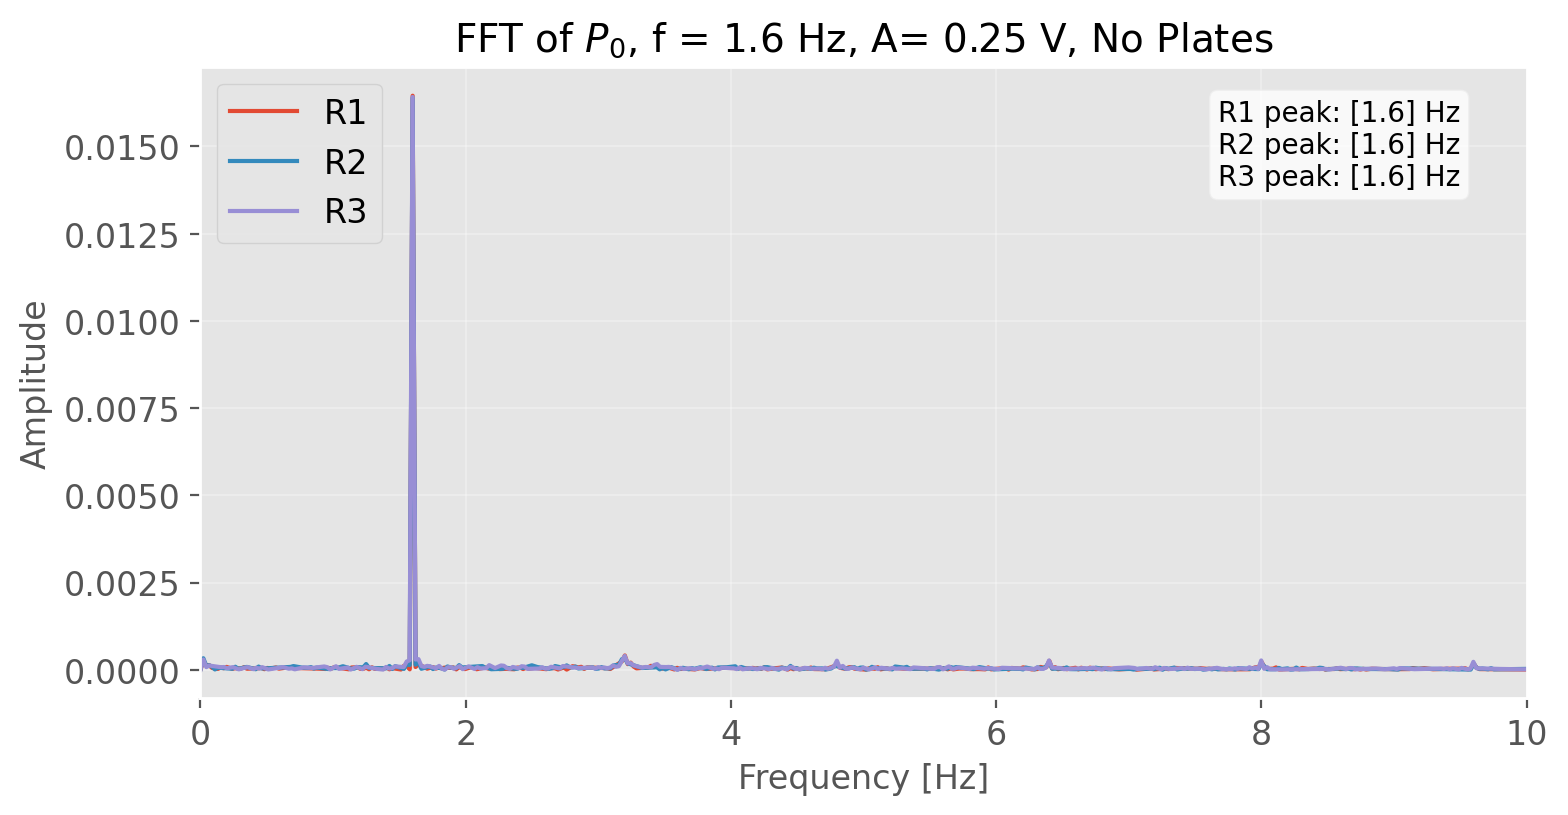

<Figure size 1280x960 with 0 Axes>

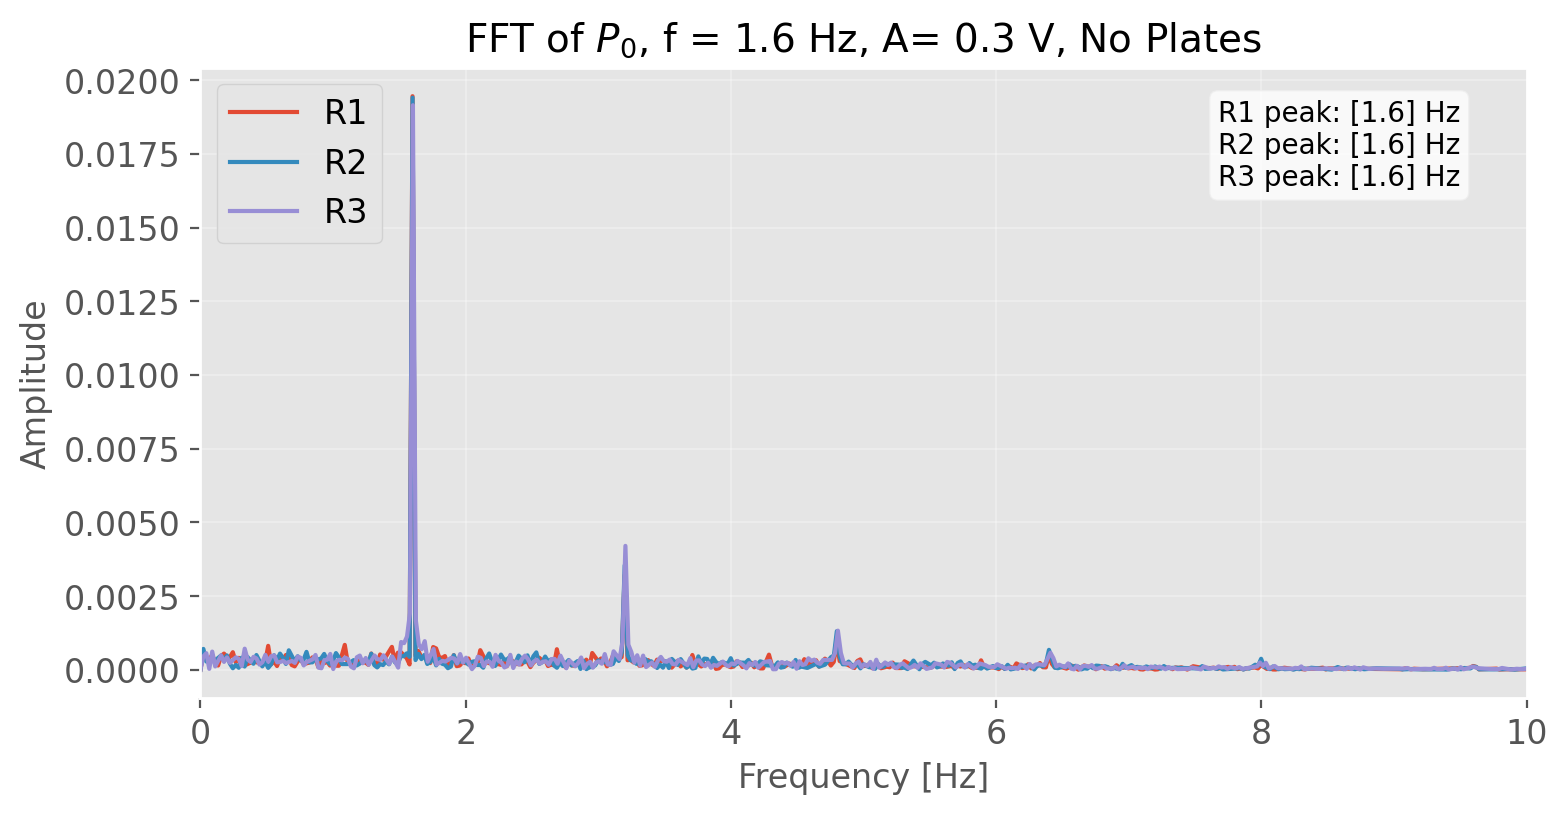

<Figure size 1280x960 with 0 Axes>

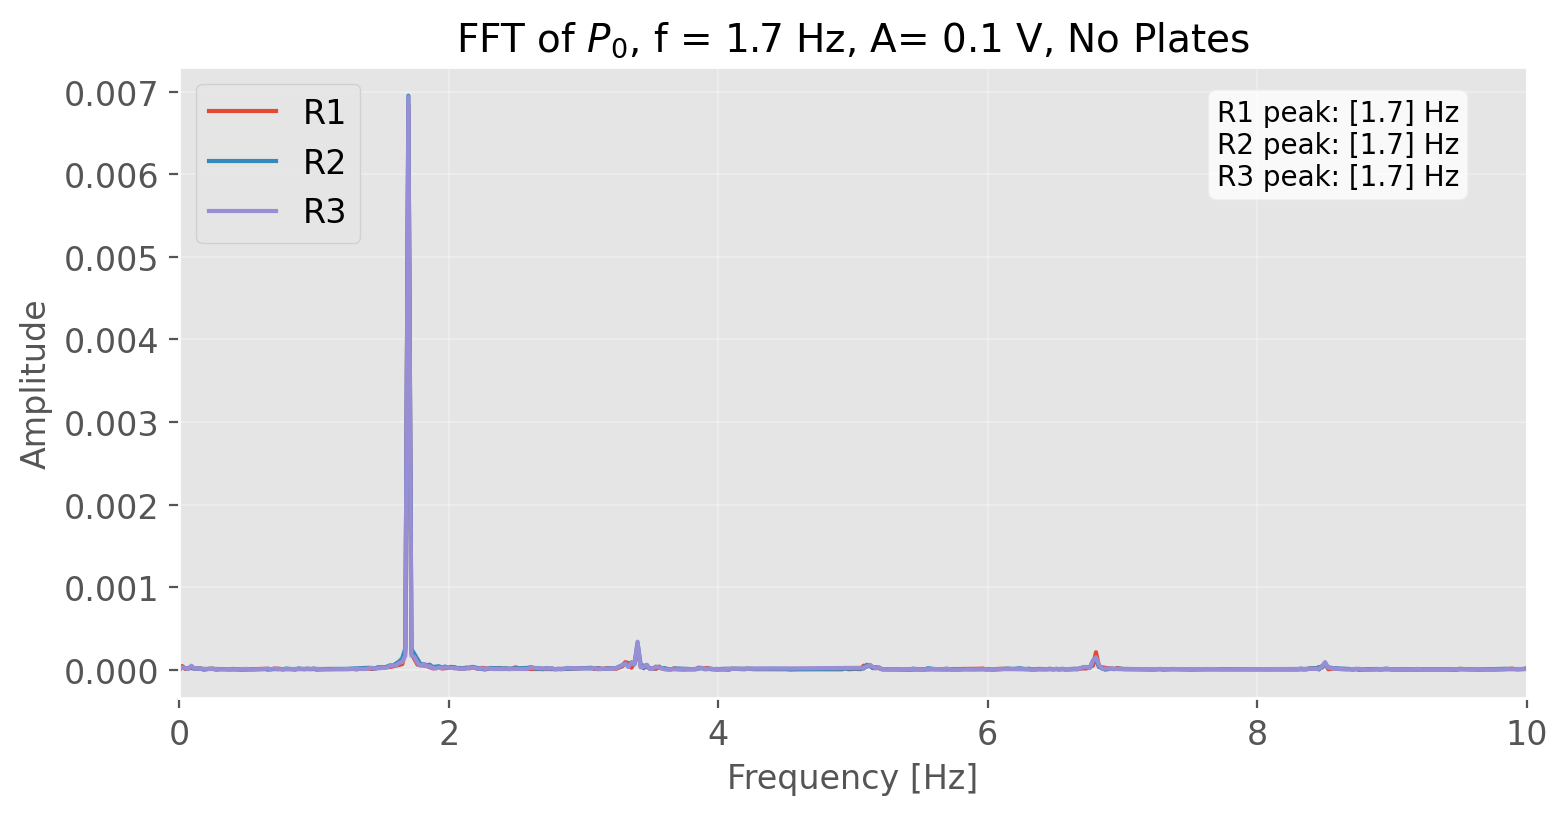

<Figure size 1280x960 with 0 Axes>

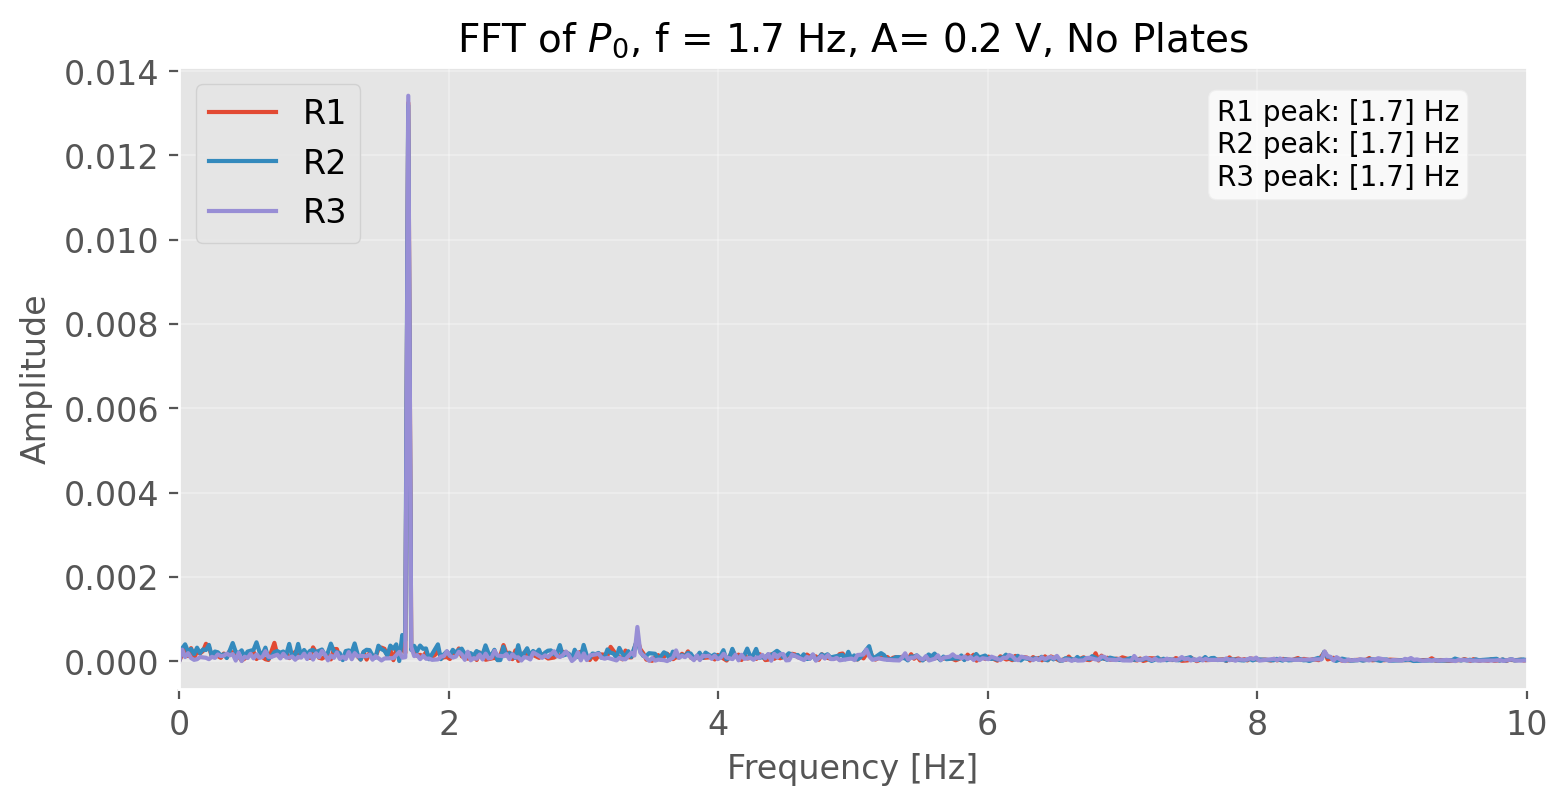

<Figure size 1280x960 with 0 Axes>

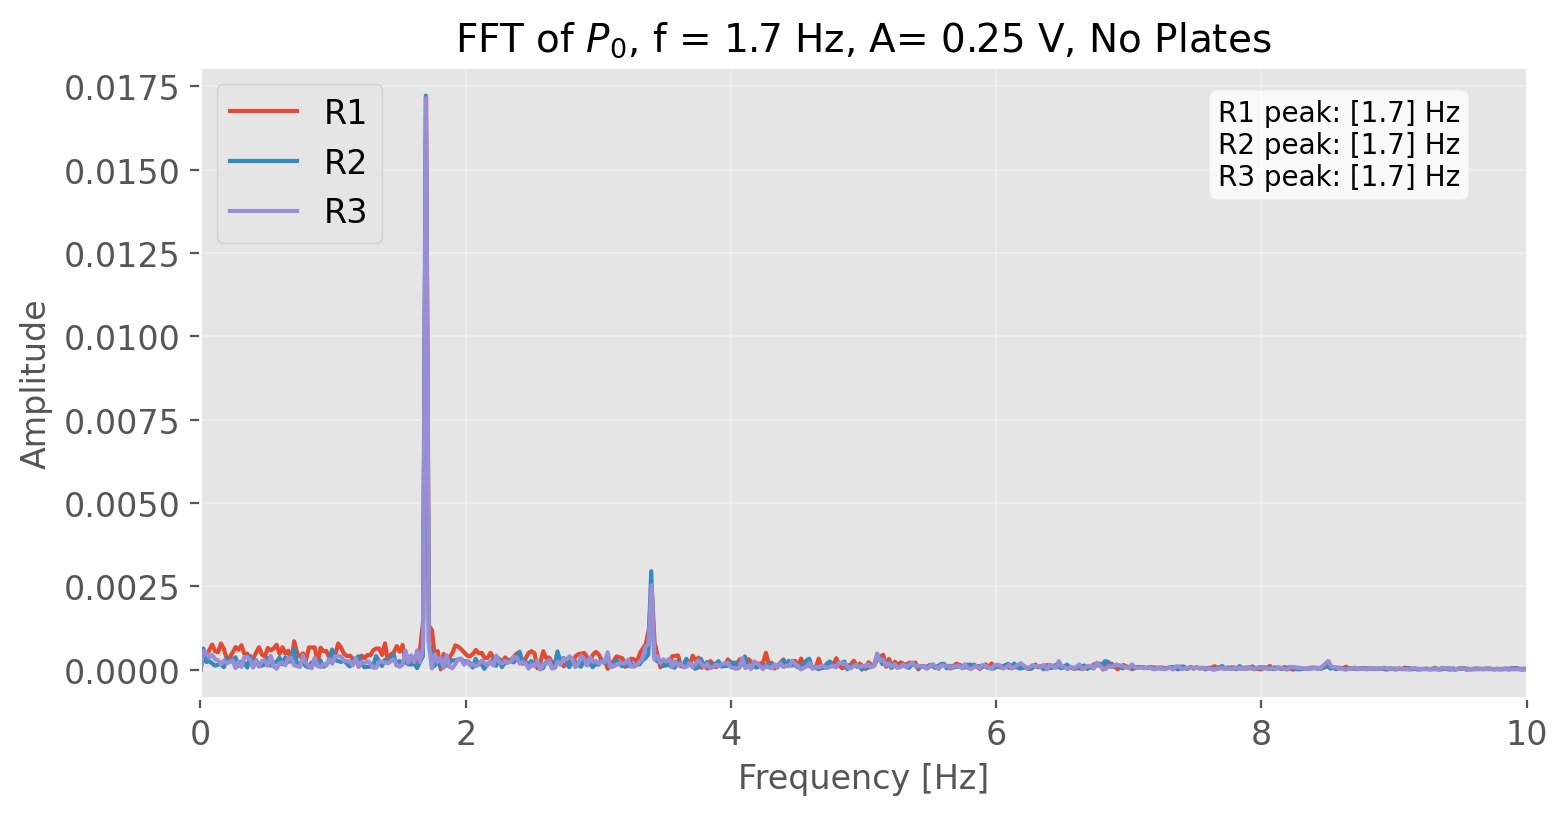

<Figure size 1280x960 with 0 Axes>

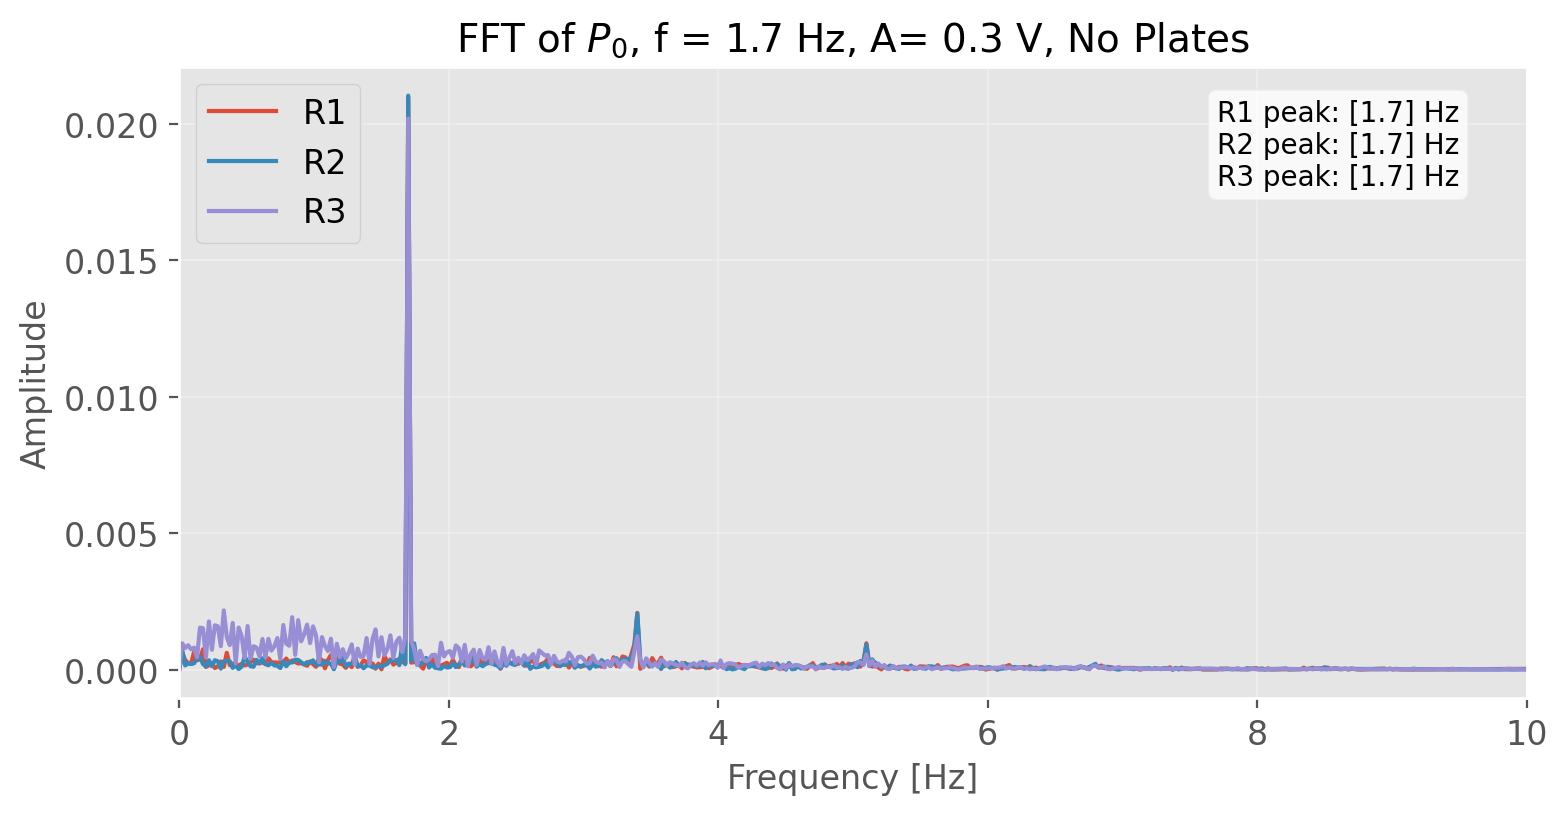

<Figure size 1280x960 with 0 Axes>

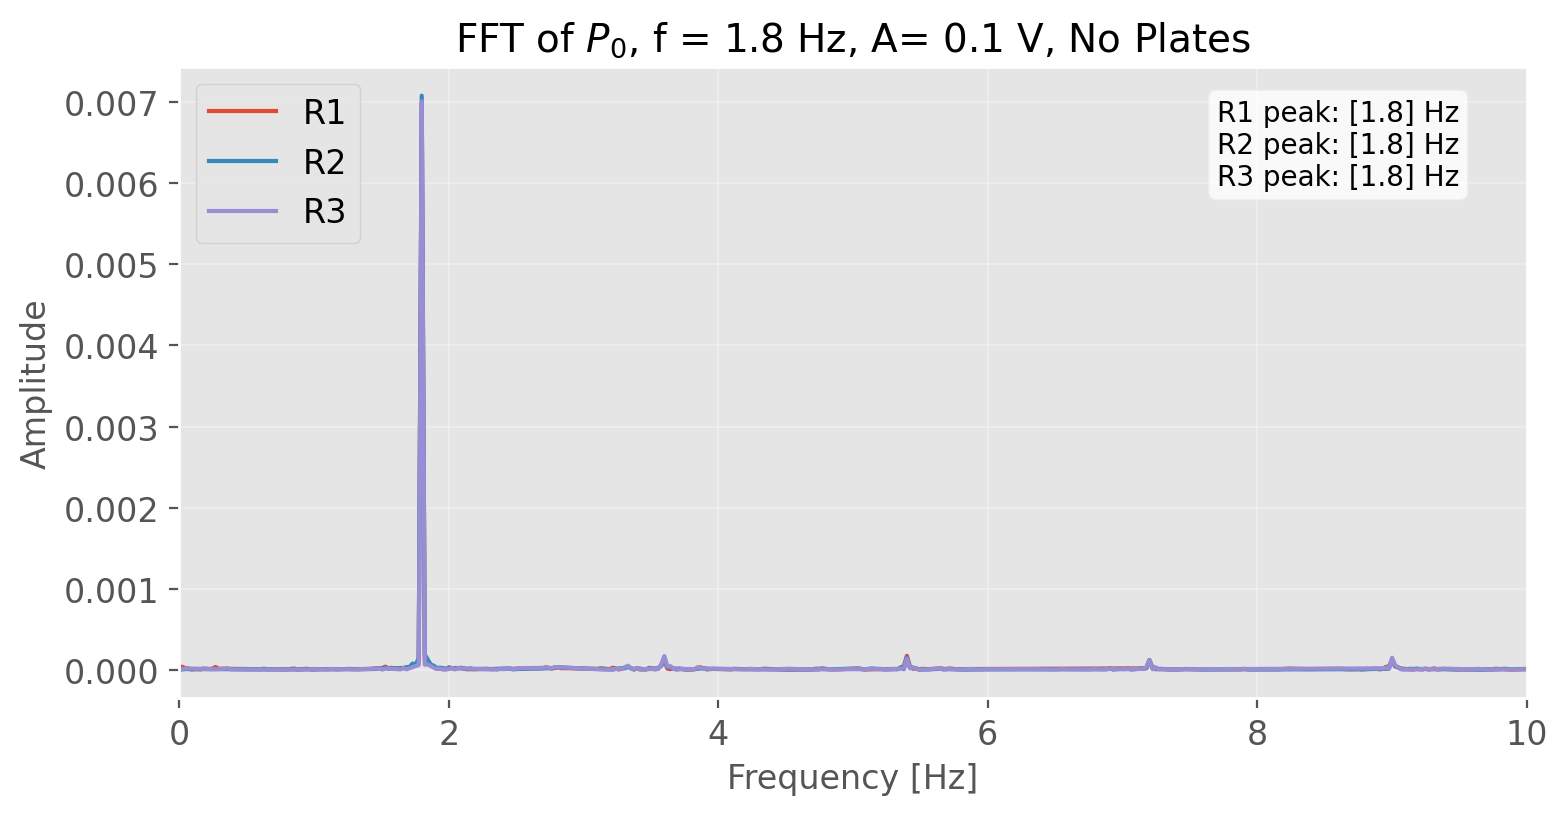

<Figure size 1280x960 with 0 Axes>

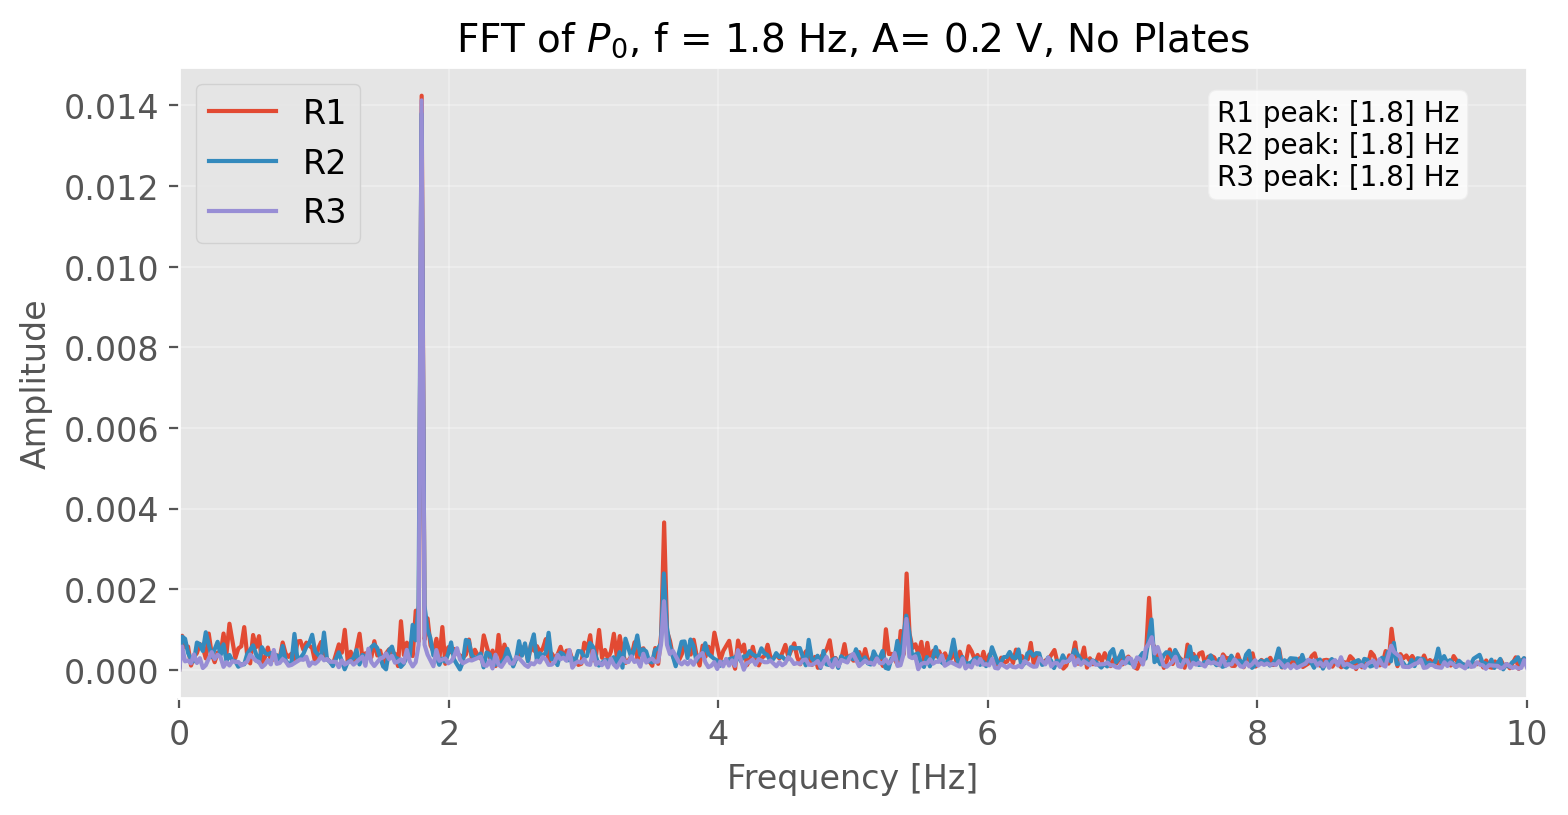

<Figure size 1280x960 with 0 Axes>

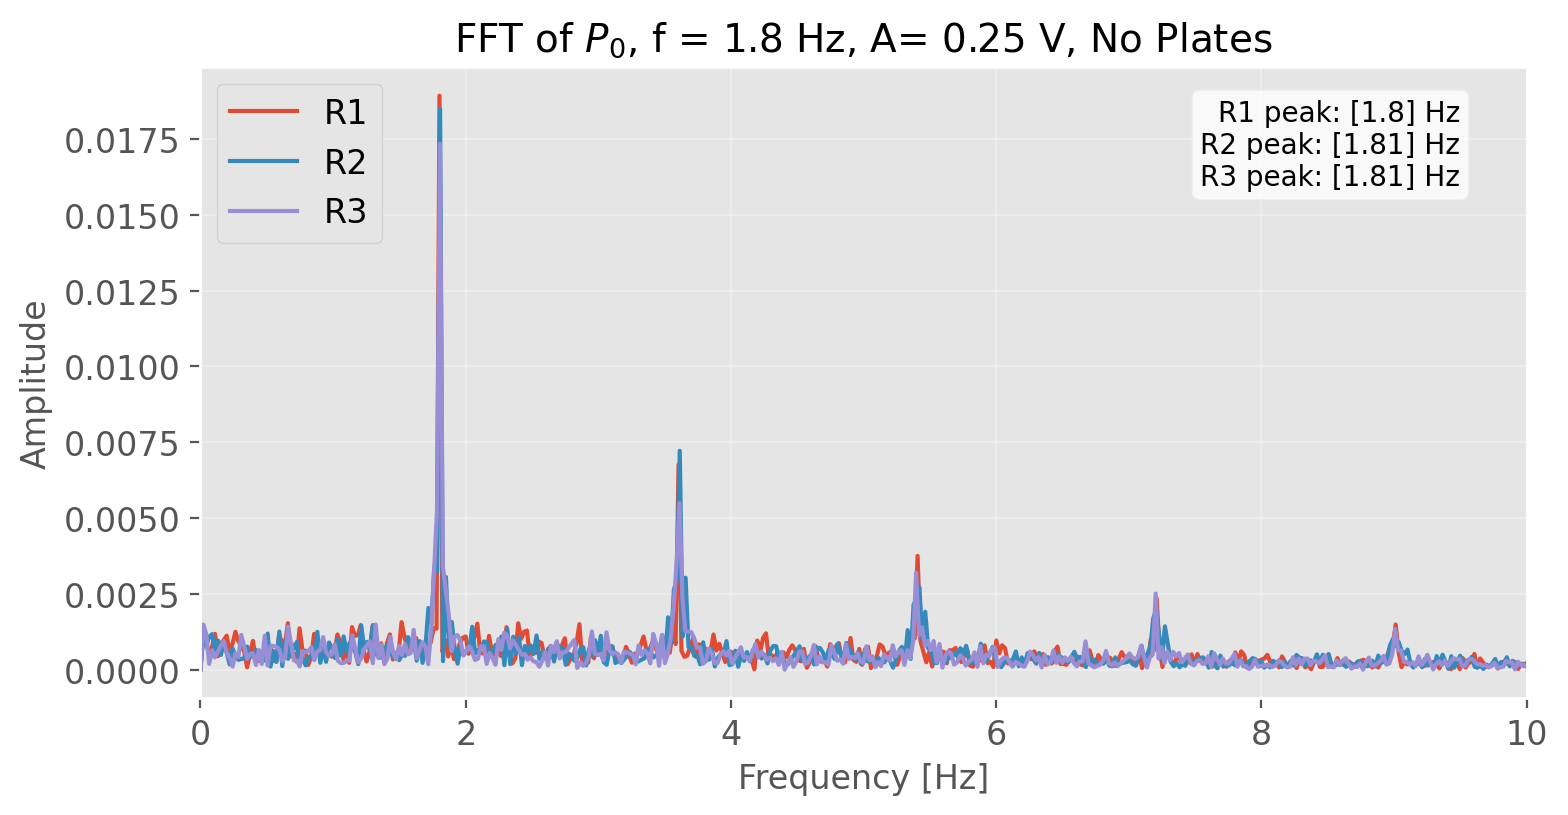

<Figure size 1280x960 with 0 Axes>

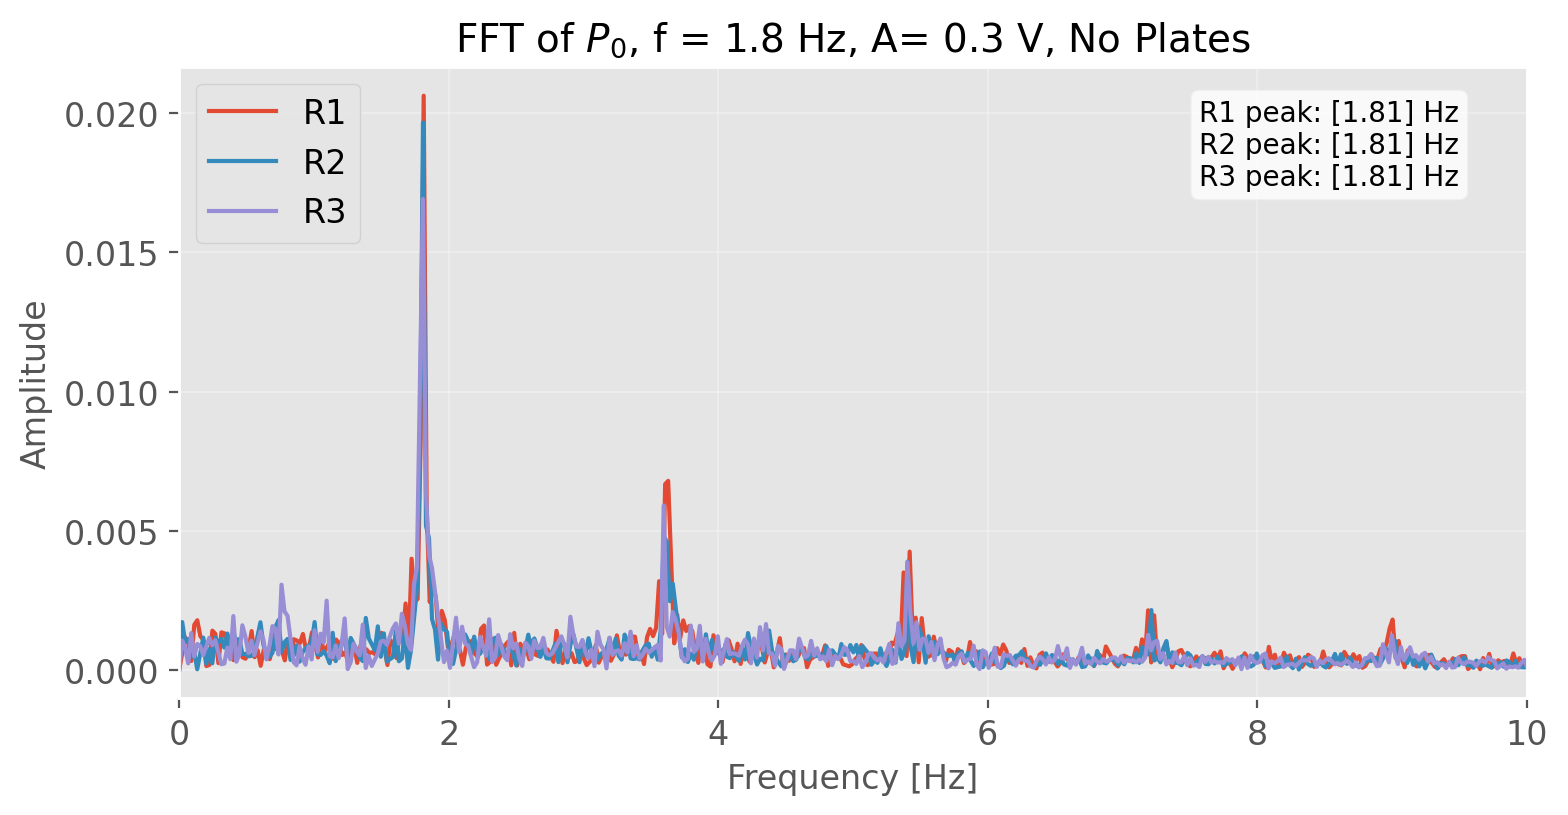

<Figure size 1280x960 with 0 Axes>

In [42]:
for i, f in enumerate(freqs20):
    for v in volts20[i]:
        p0_r1 = data20[f][v]["None"]["R1"]['P_0'].dropna().values
        p0_r2 = data20[f][v]["None"]["R2"]['P_0'].dropna().values
        p0_r3 = data20[f][v]["None"]["R3"]['P_0'].dropna().values
        plot_fft(p0_r1, p0_r2, p0_r3)

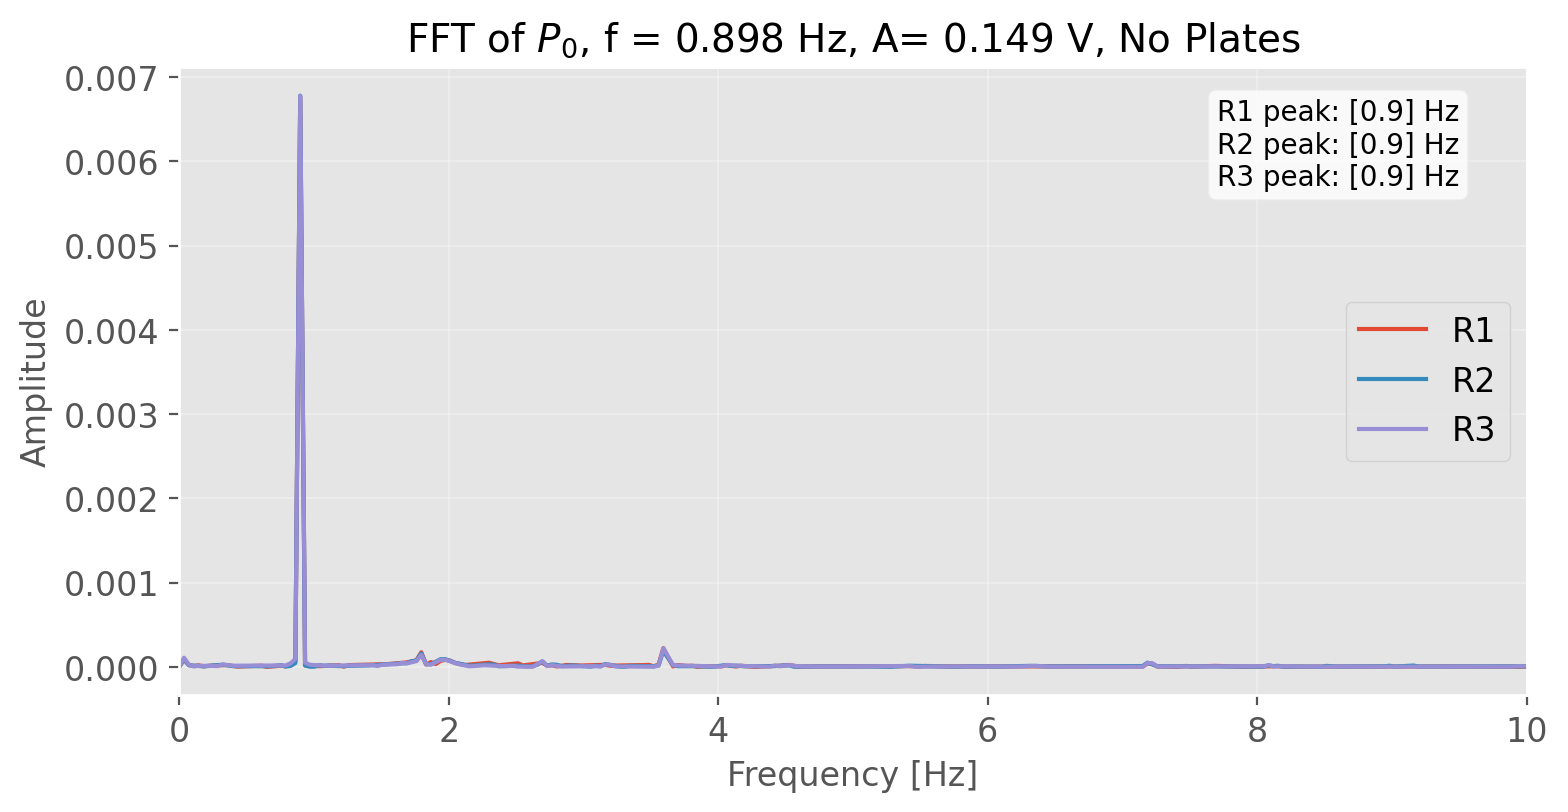

<Figure size 1280x960 with 0 Axes>

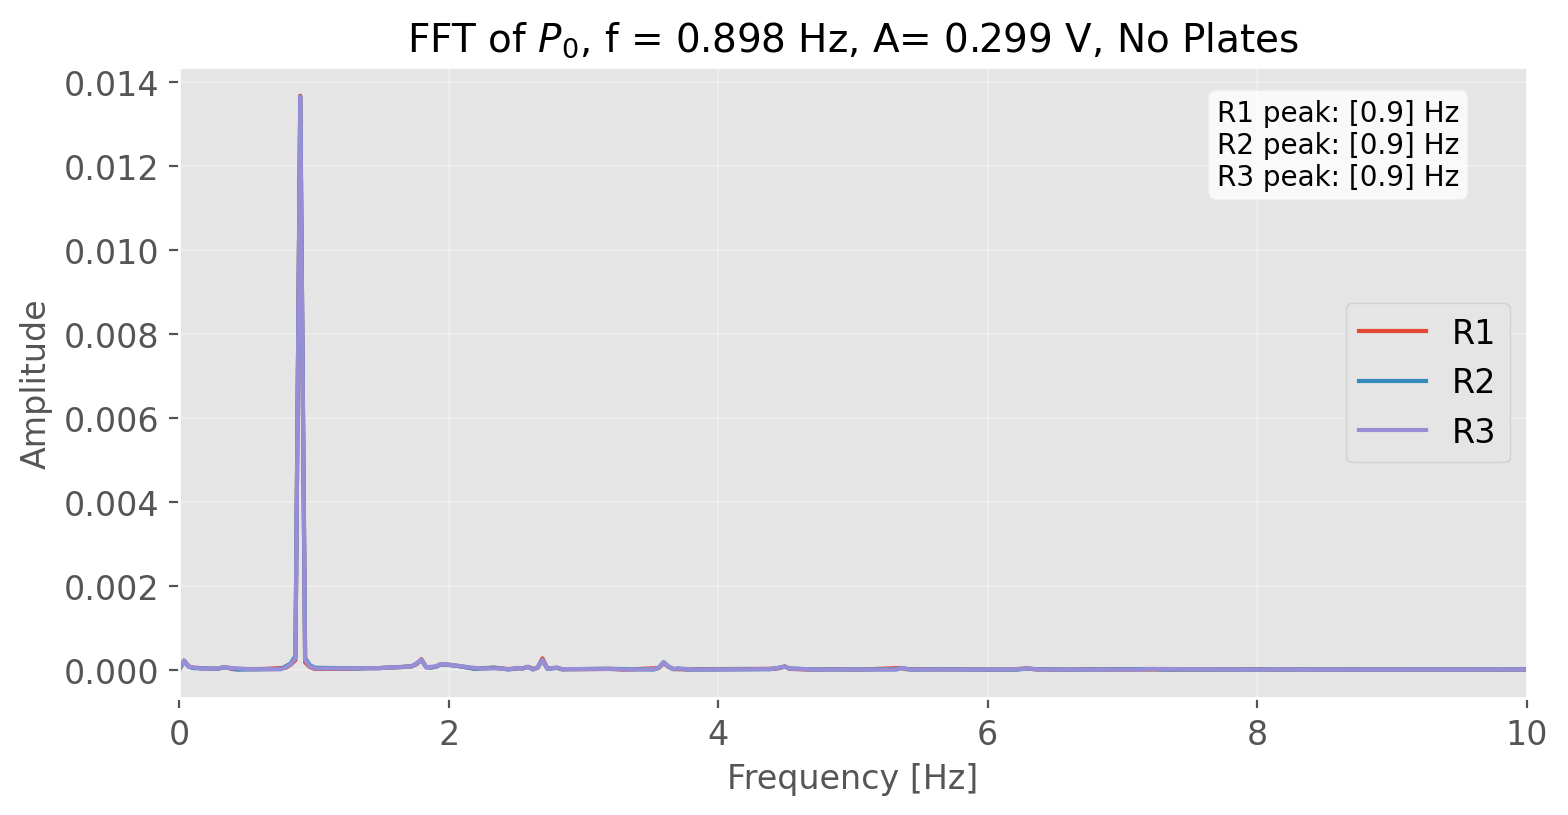

<Figure size 1280x960 with 0 Axes>

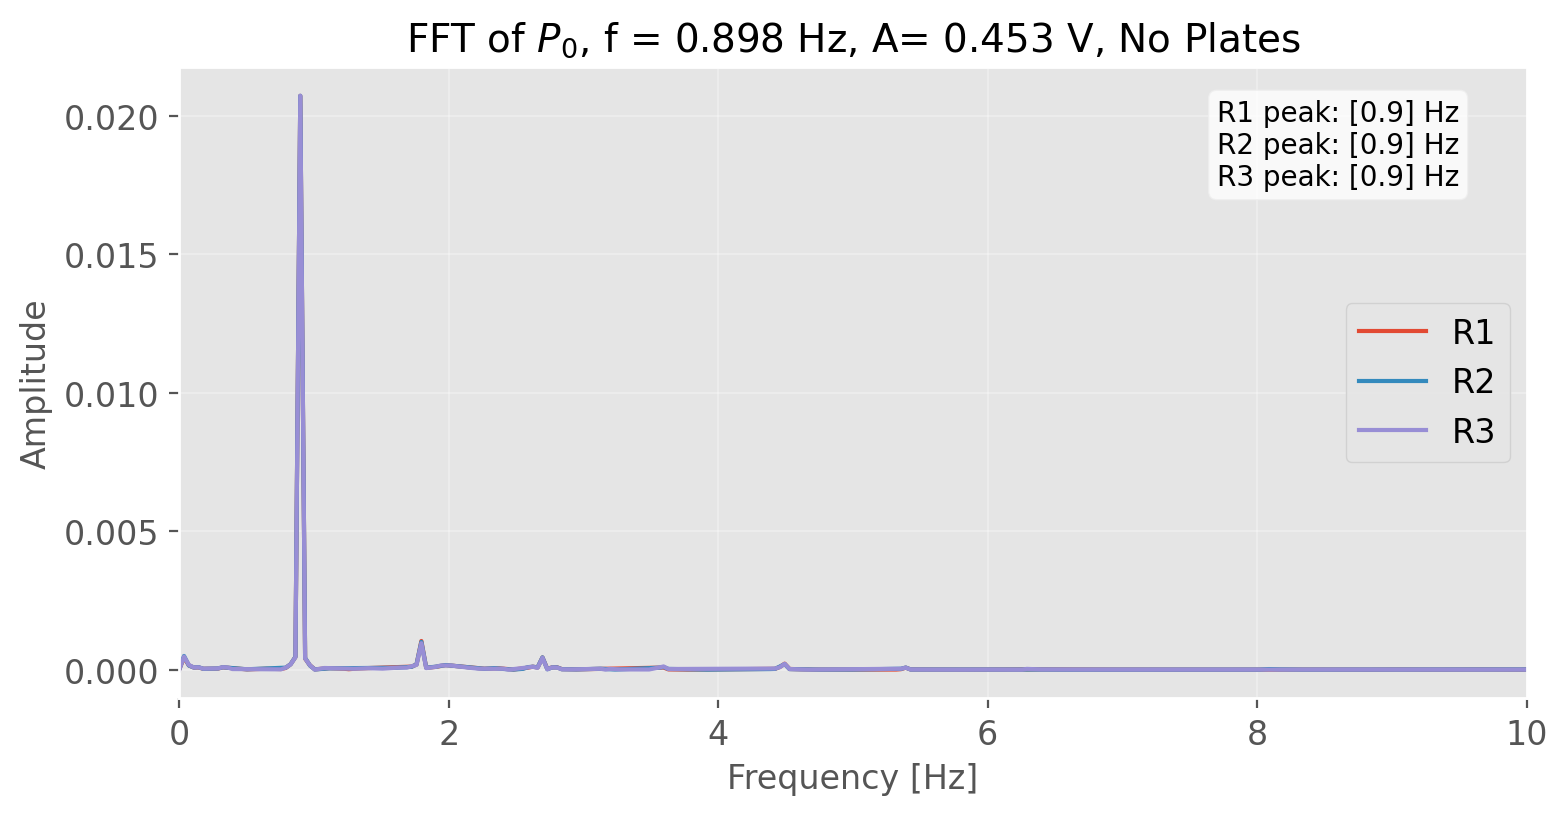

<Figure size 1280x960 with 0 Axes>

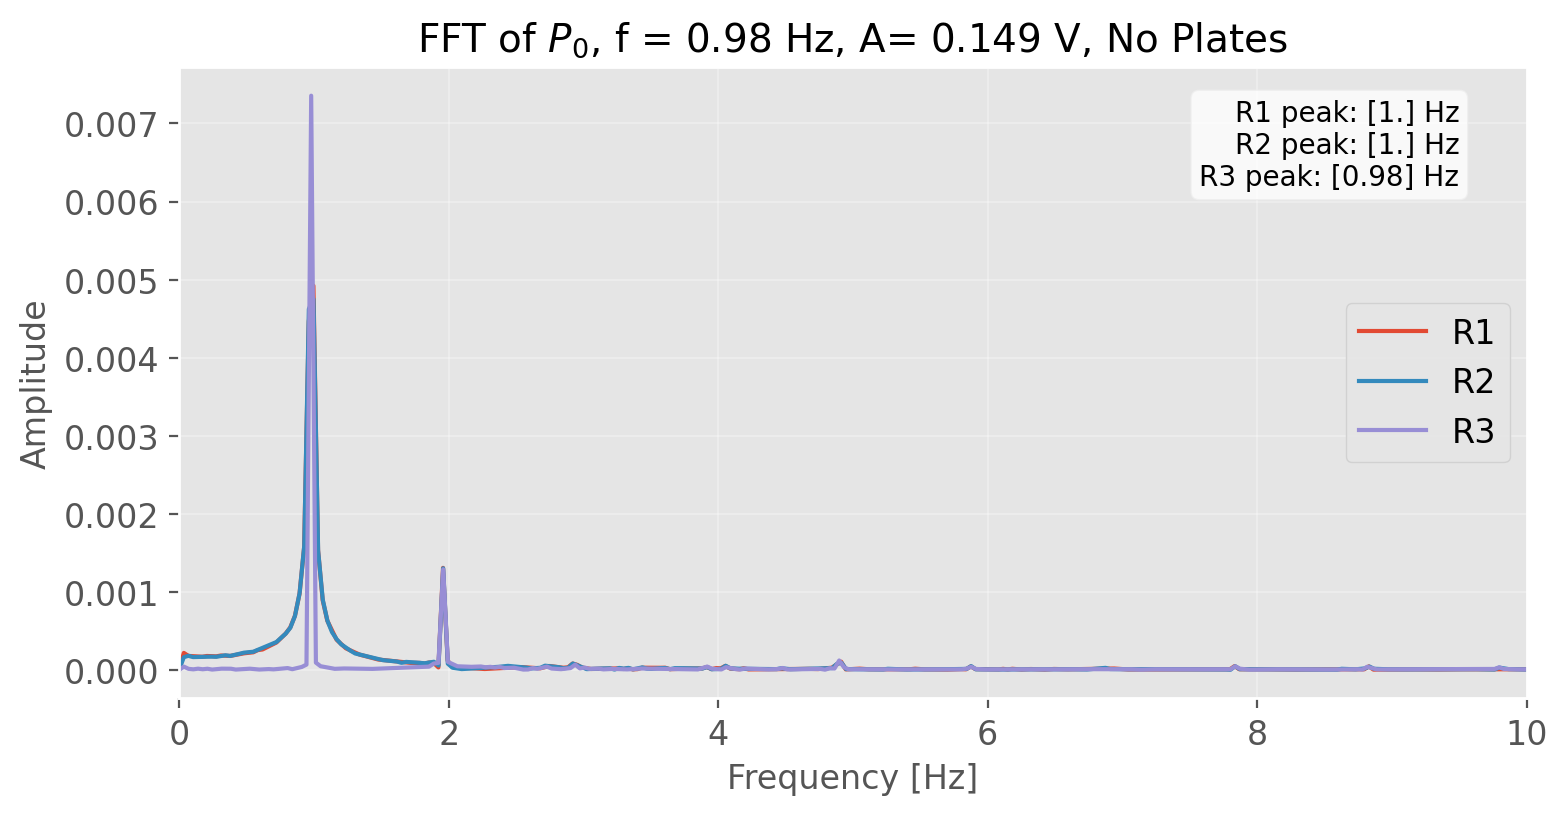

<Figure size 1280x960 with 0 Axes>

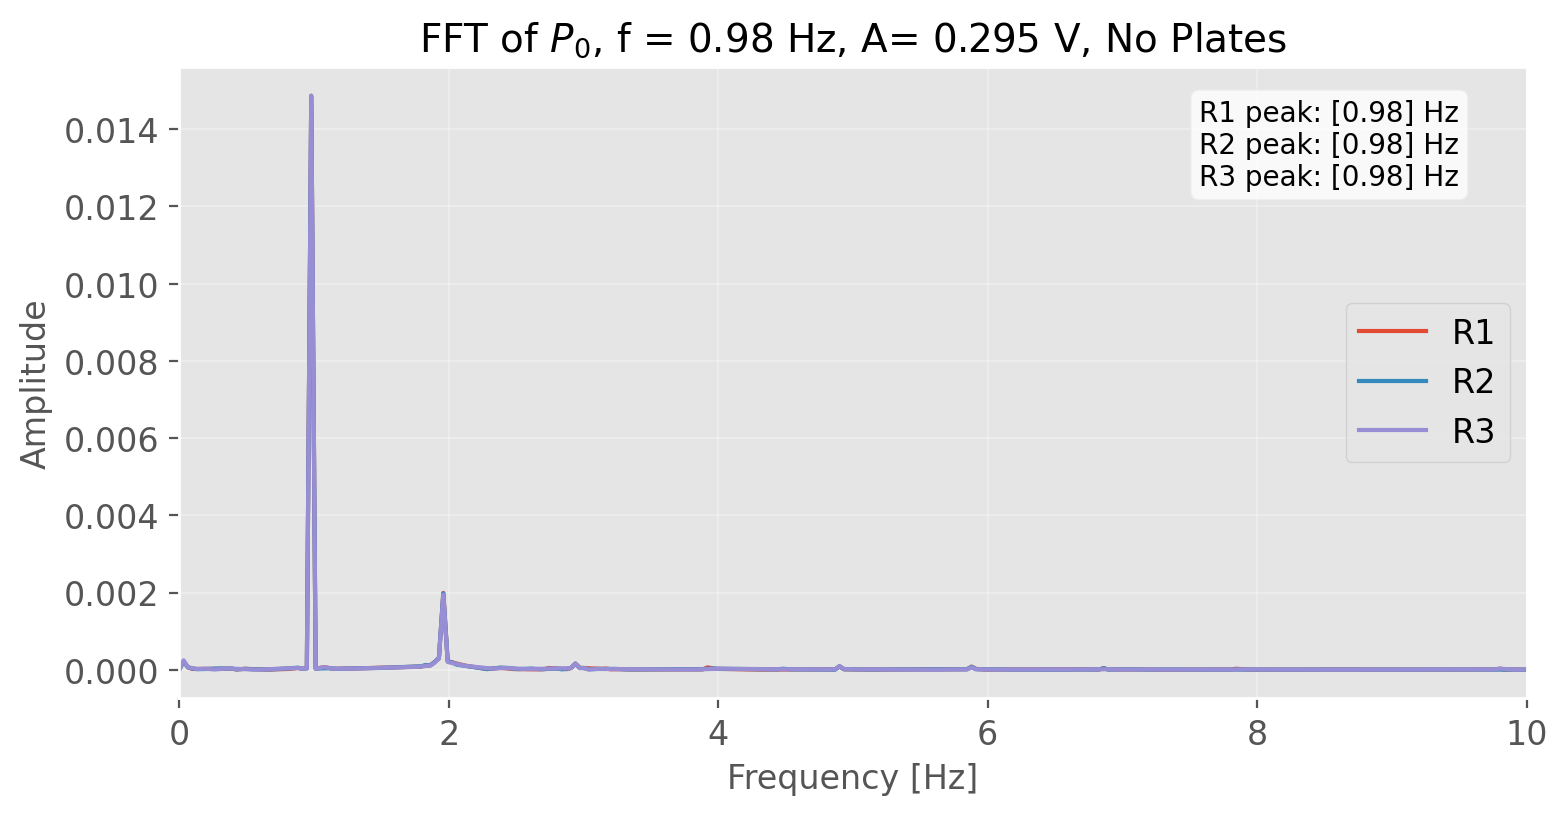

<Figure size 1280x960 with 0 Axes>

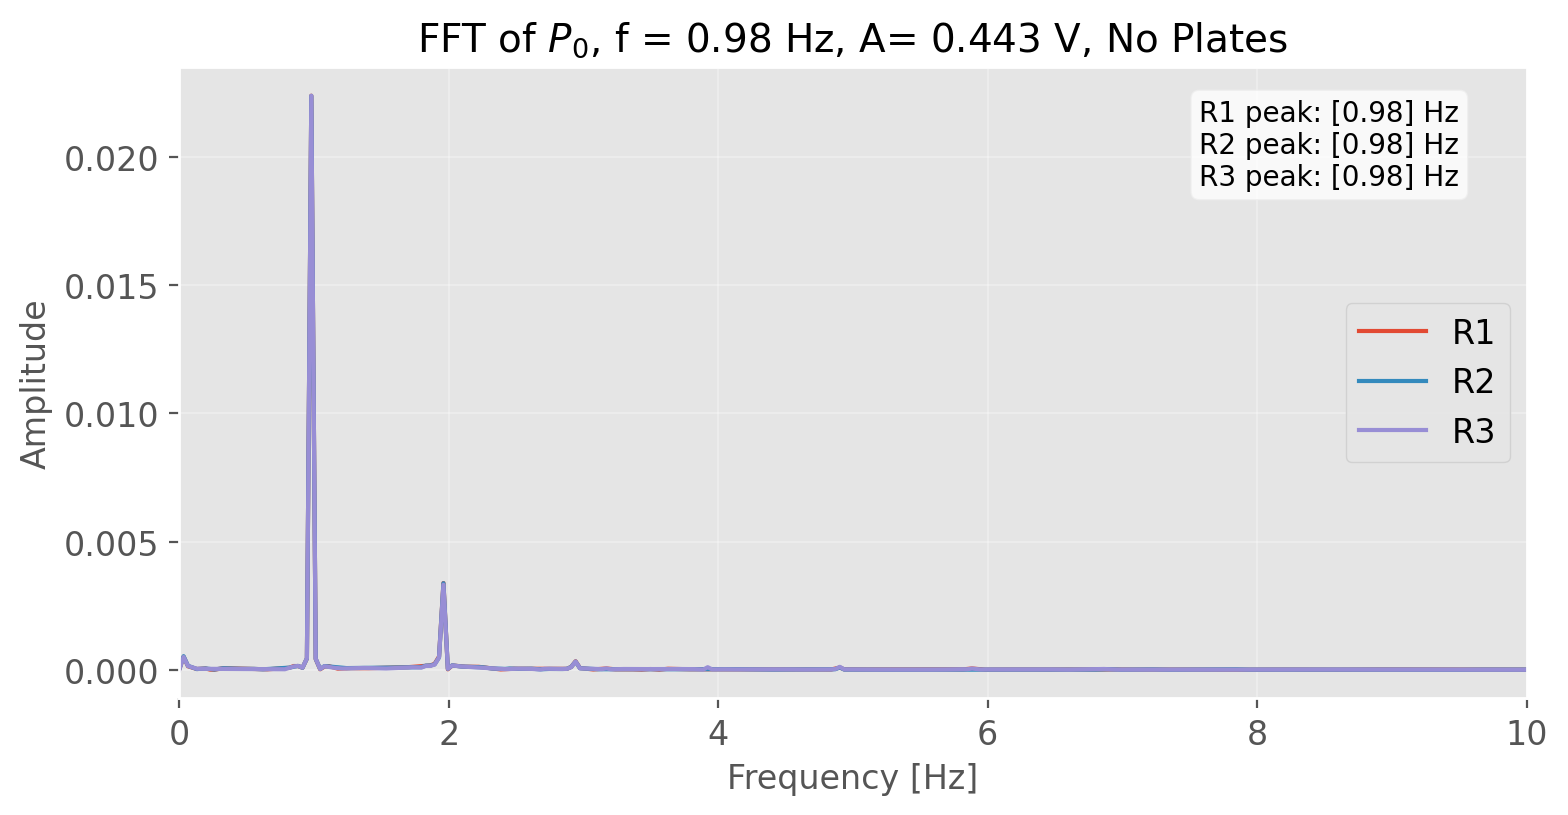

<Figure size 1280x960 with 0 Axes>

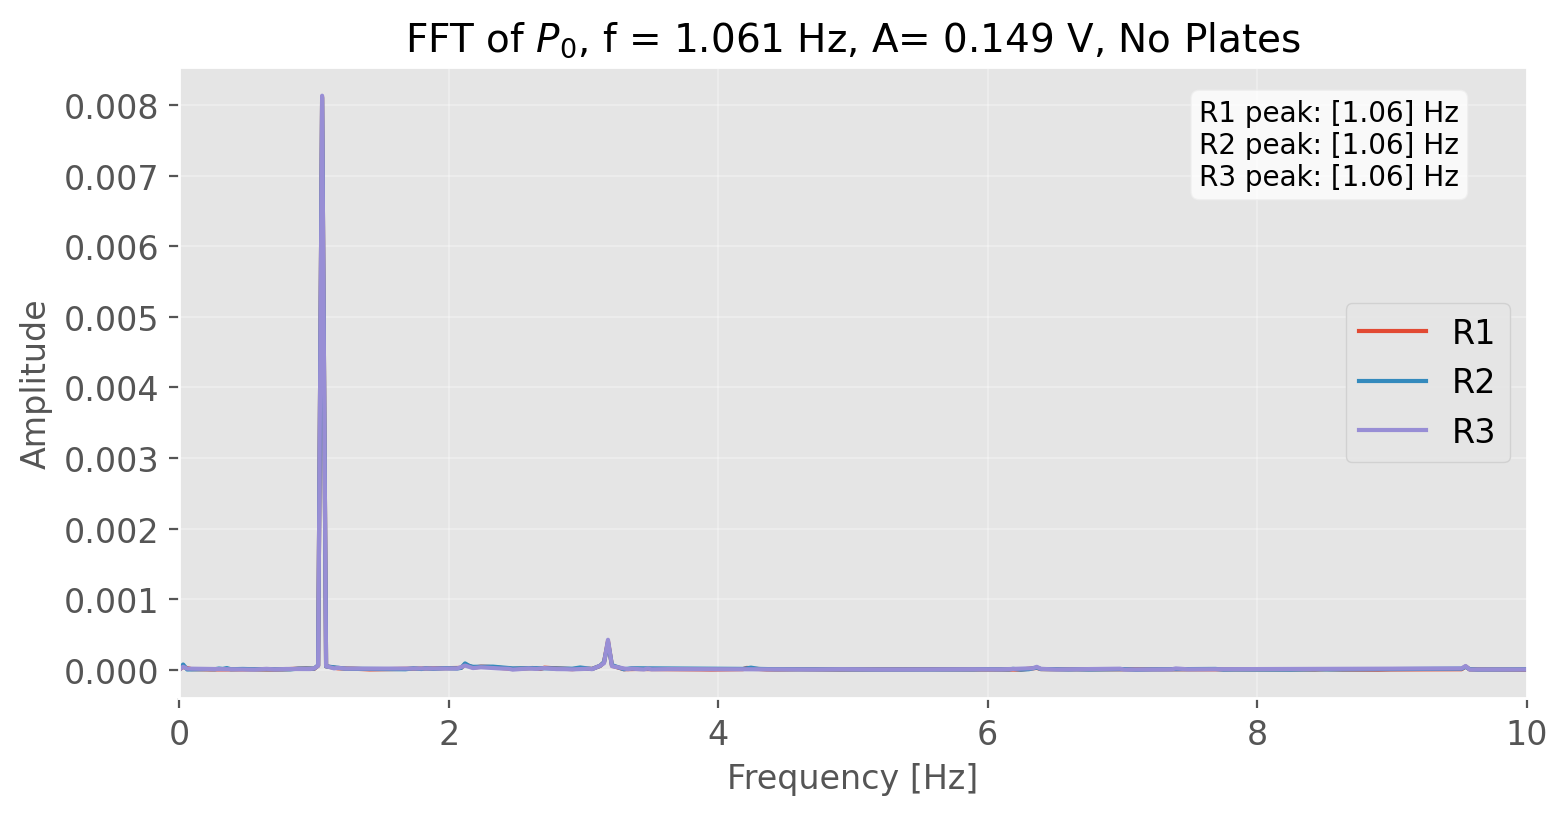

<Figure size 1280x960 with 0 Axes>

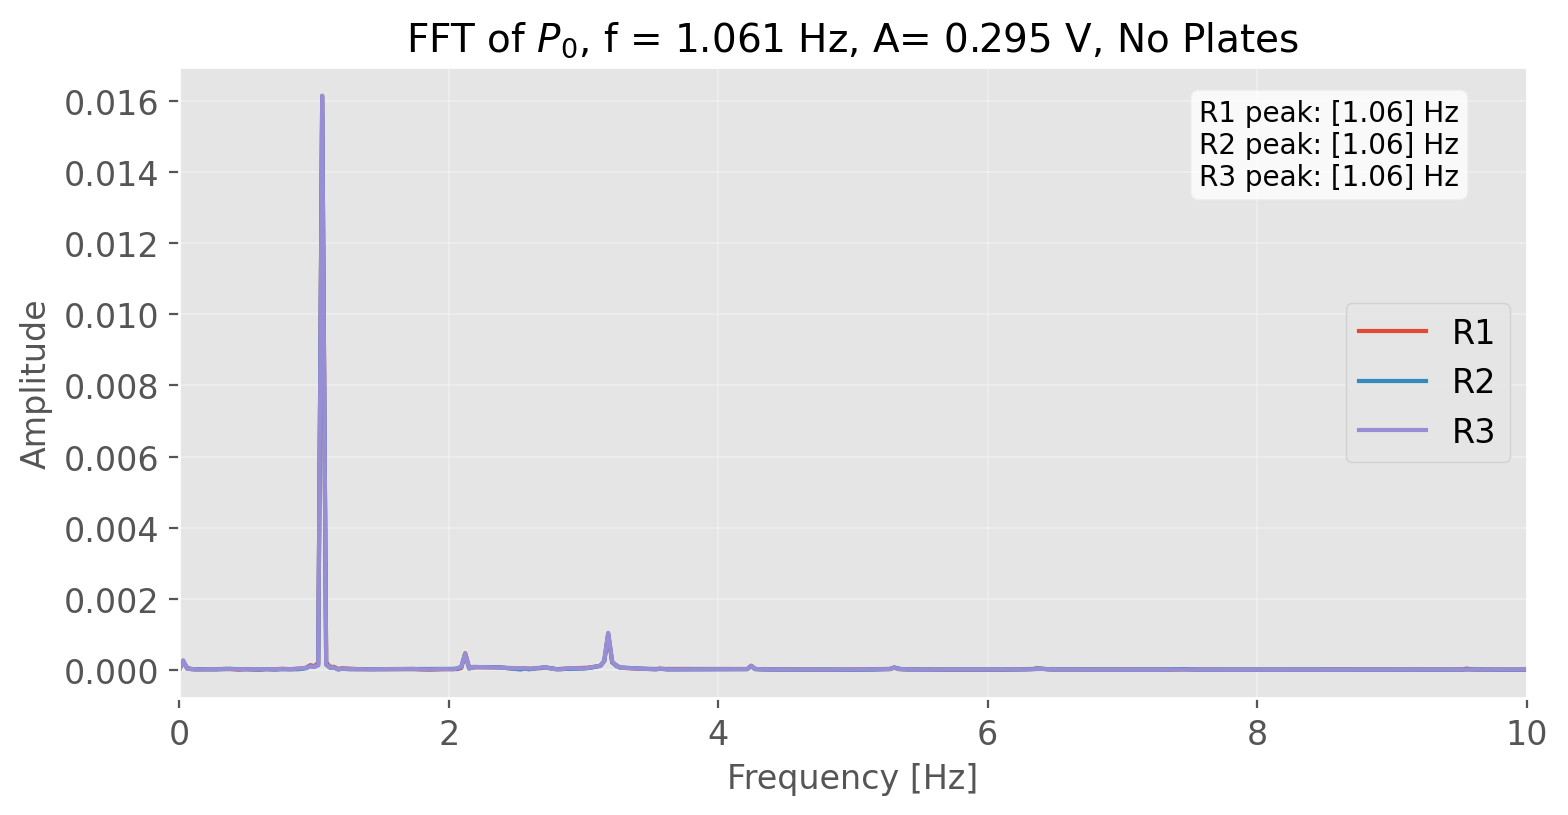

<Figure size 1280x960 with 0 Axes>

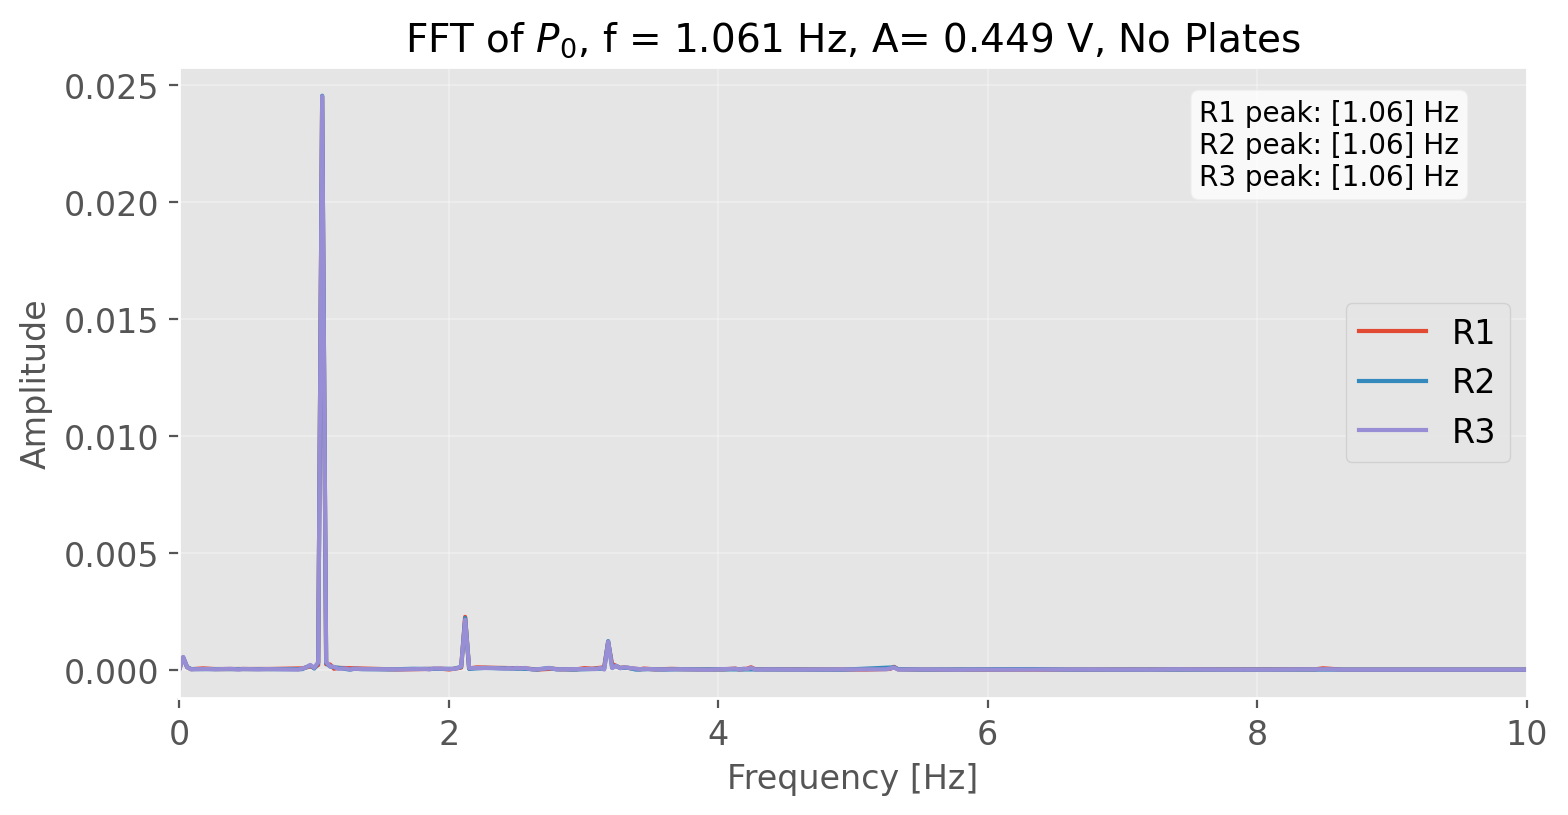

<Figure size 1280x960 with 0 Axes>

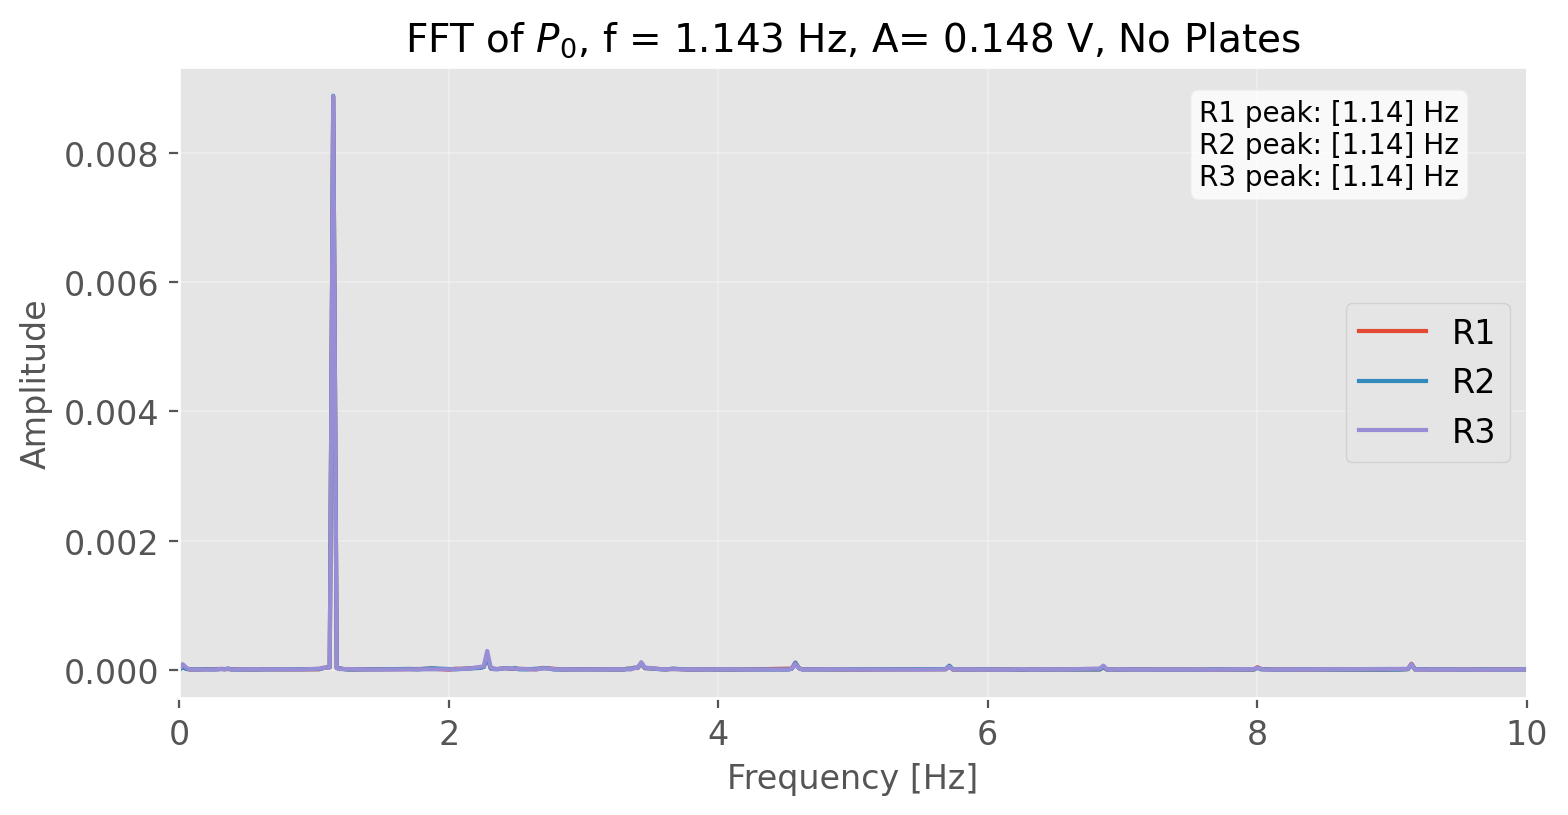

<Figure size 1280x960 with 0 Axes>

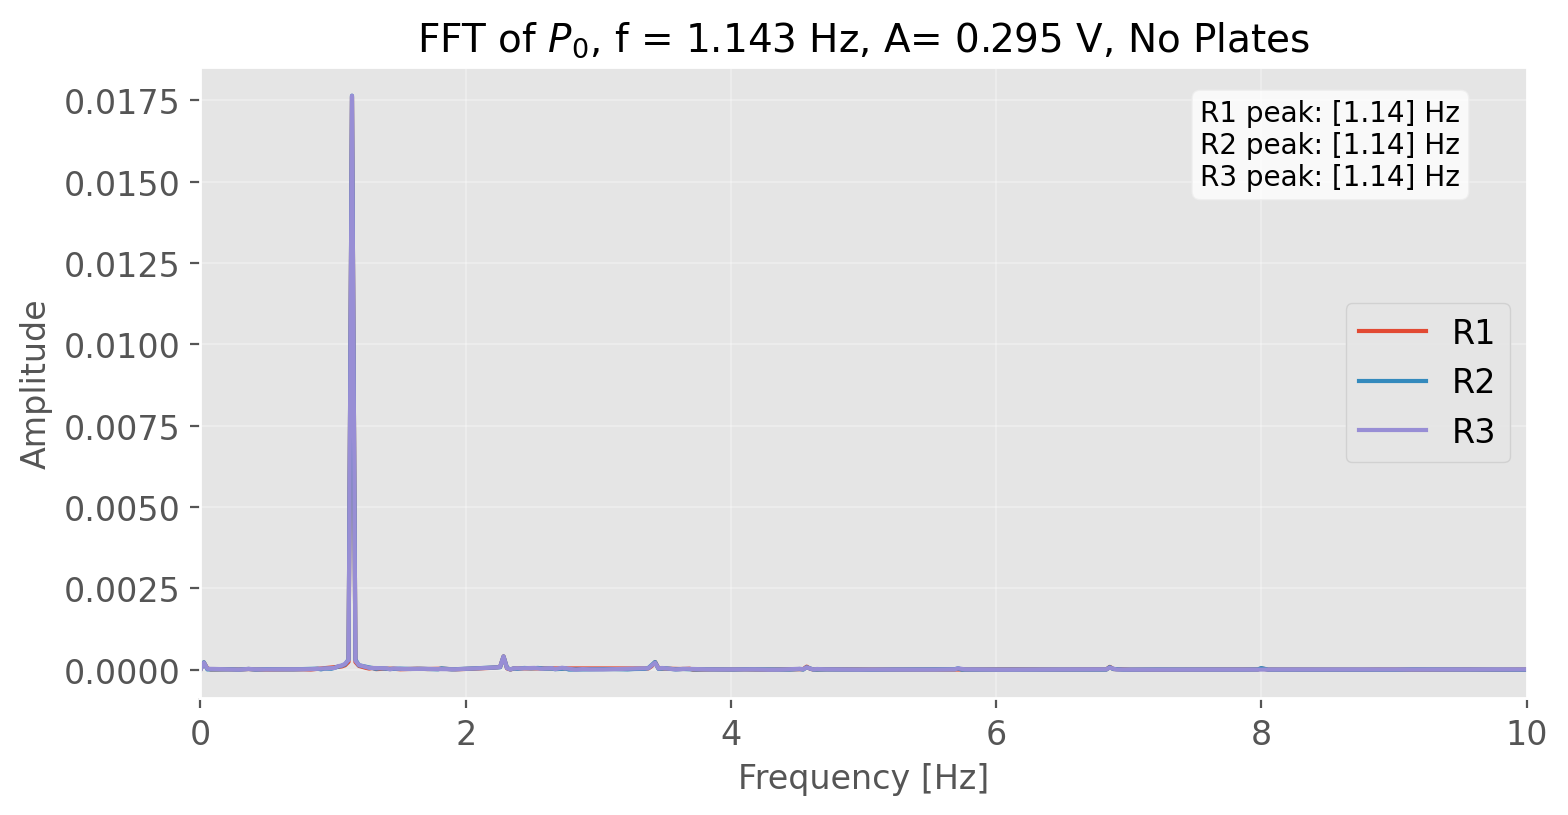

<Figure size 1280x960 with 0 Axes>

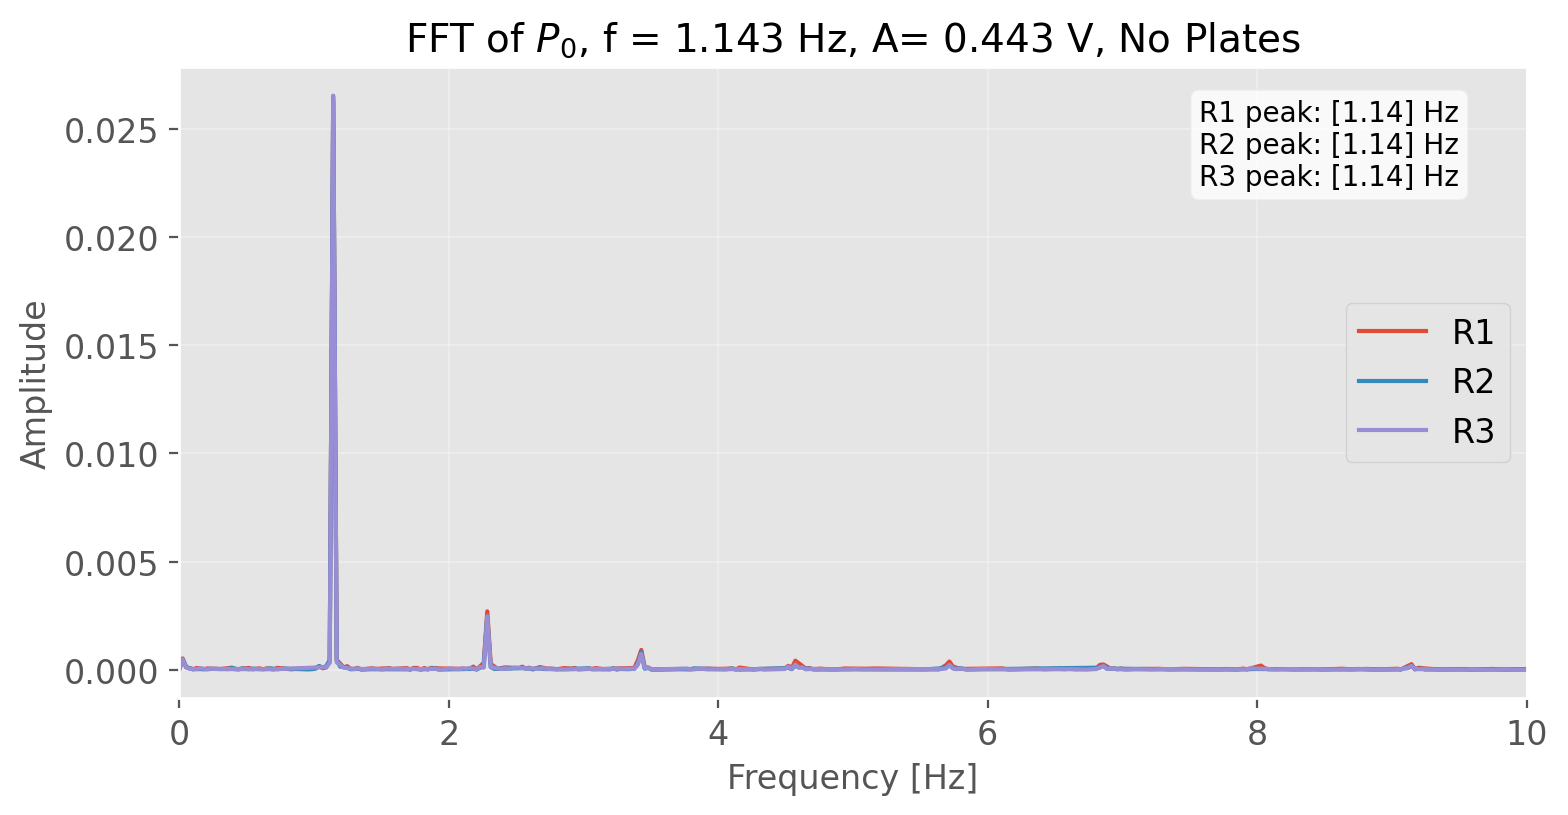

<Figure size 1280x960 with 0 Axes>

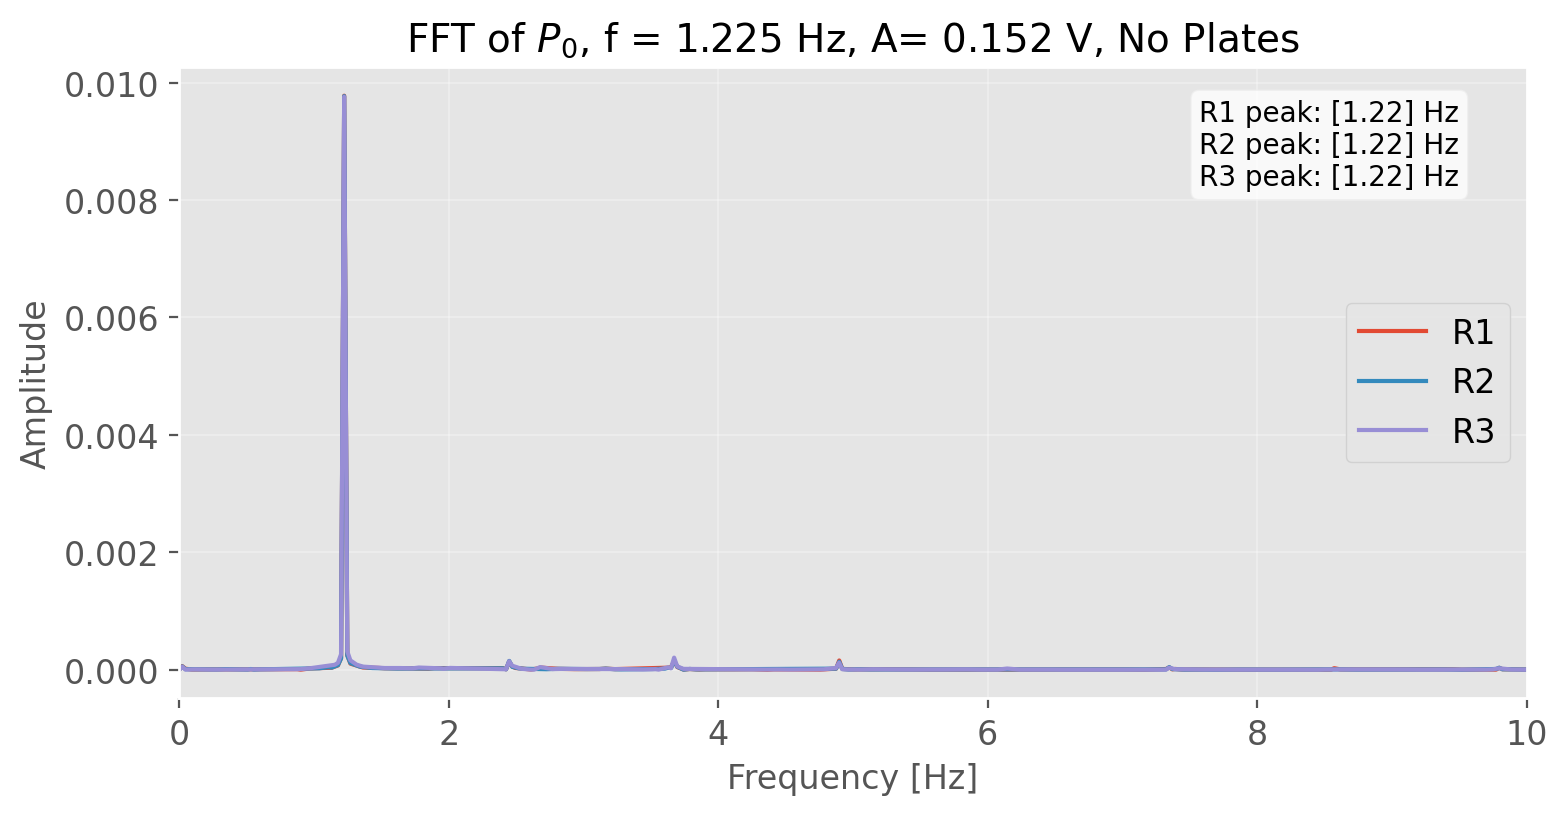

<Figure size 1280x960 with 0 Axes>

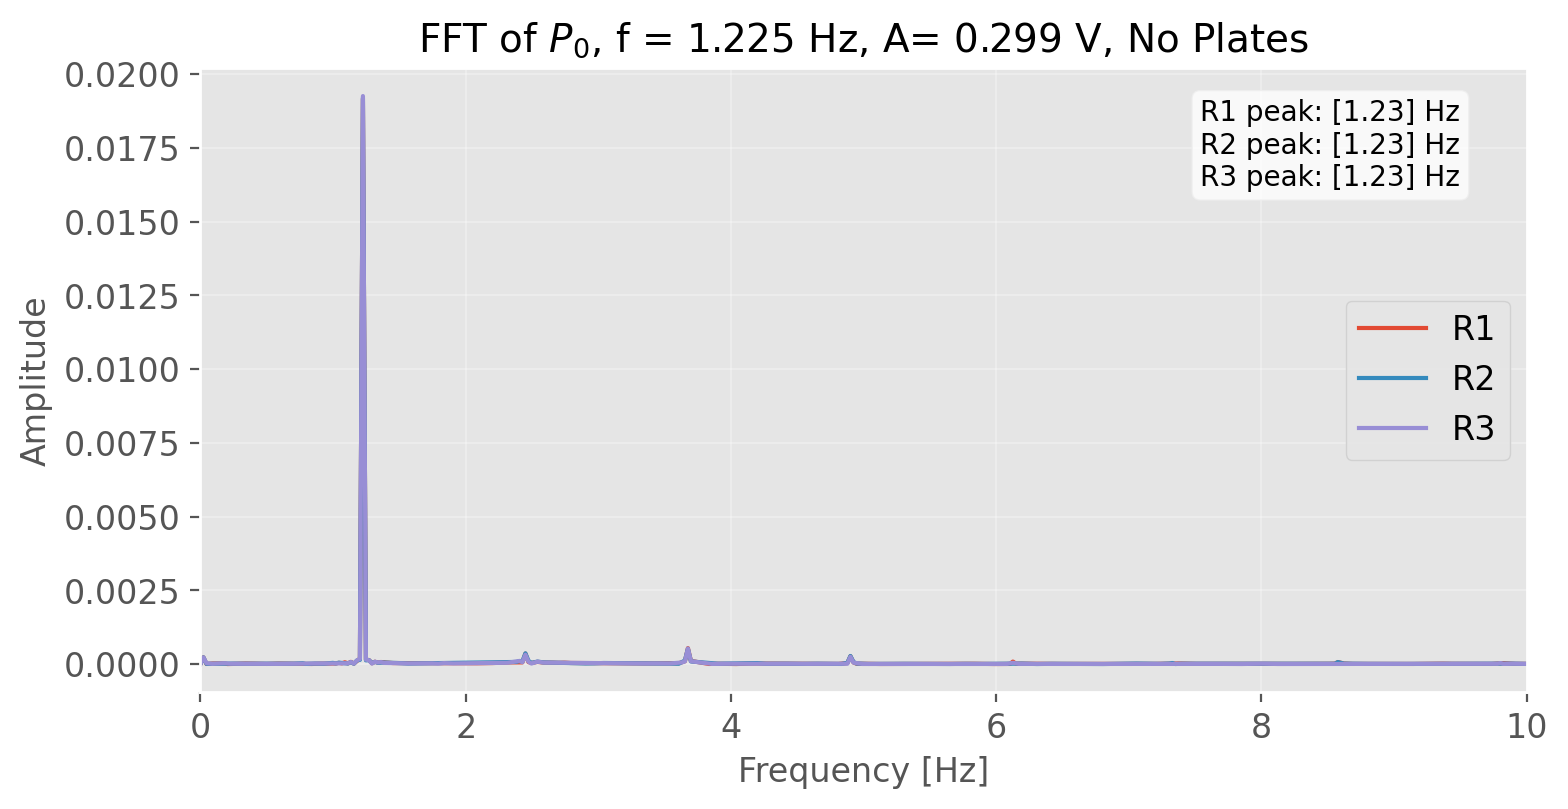

<Figure size 1280x960 with 0 Axes>

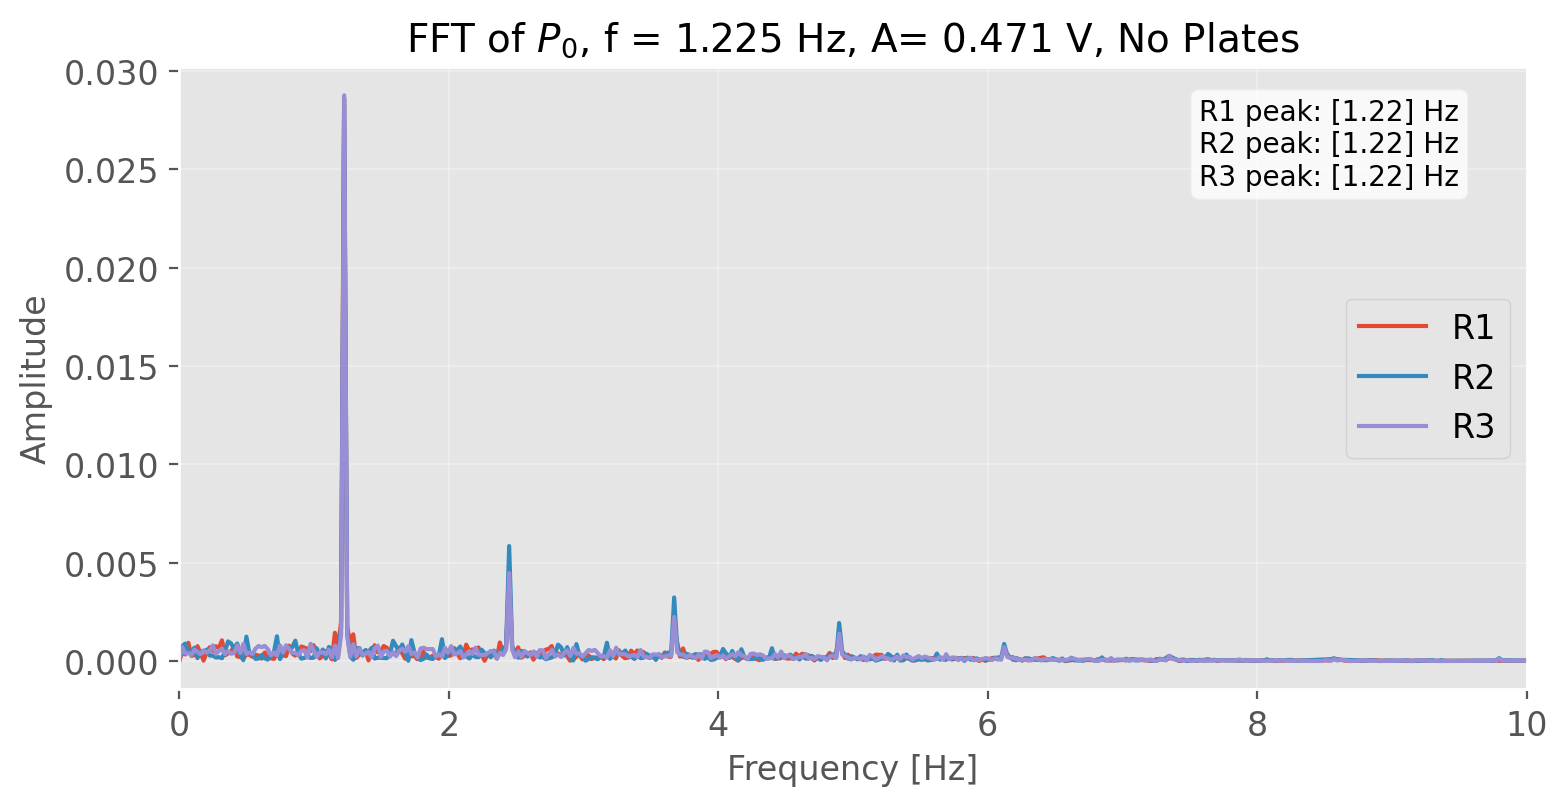

<Figure size 1280x960 with 0 Axes>

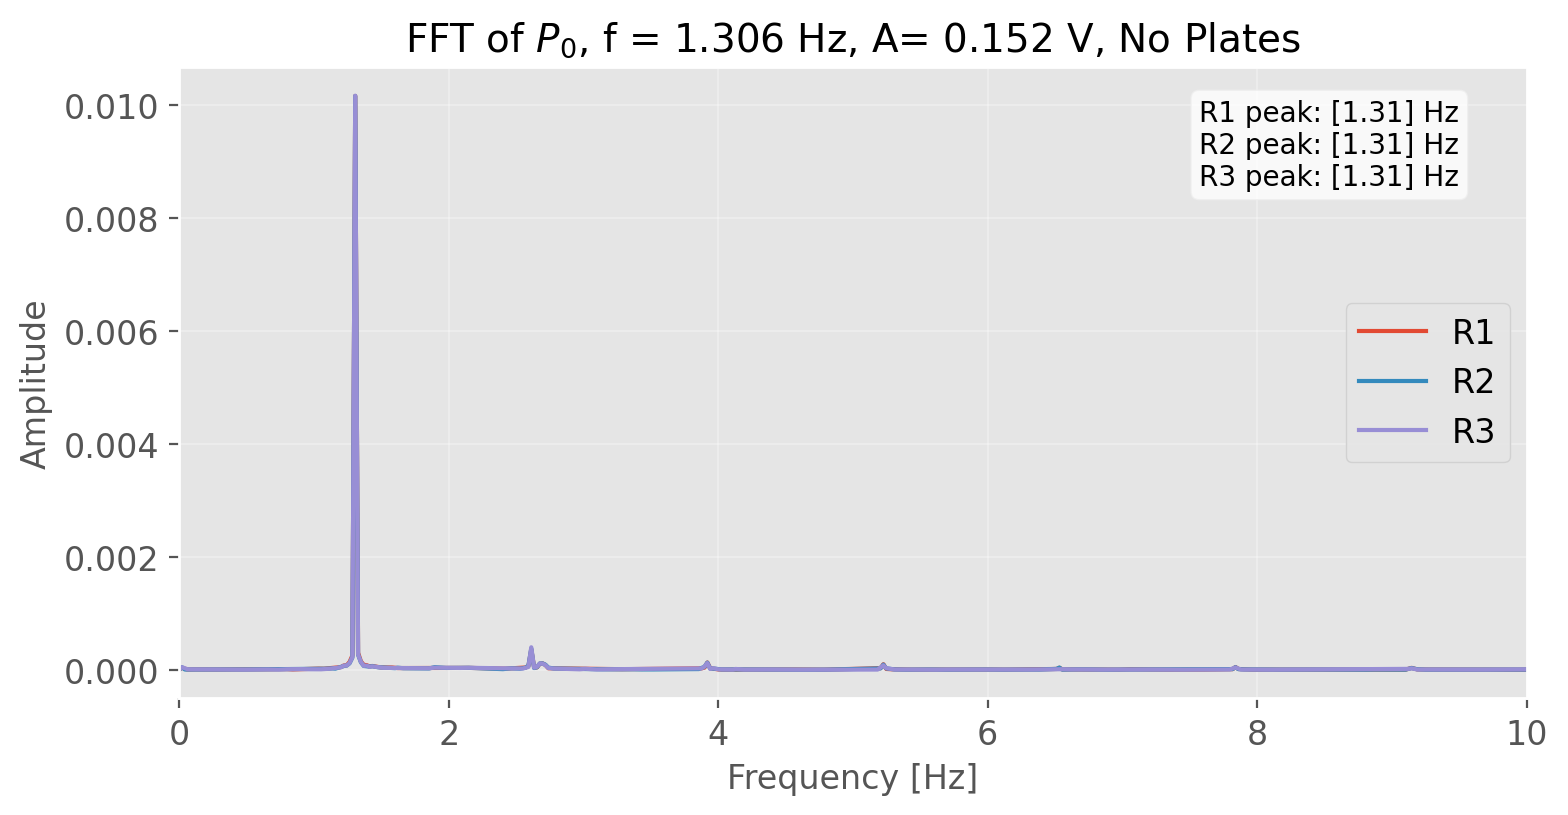

<Figure size 1280x960 with 0 Axes>

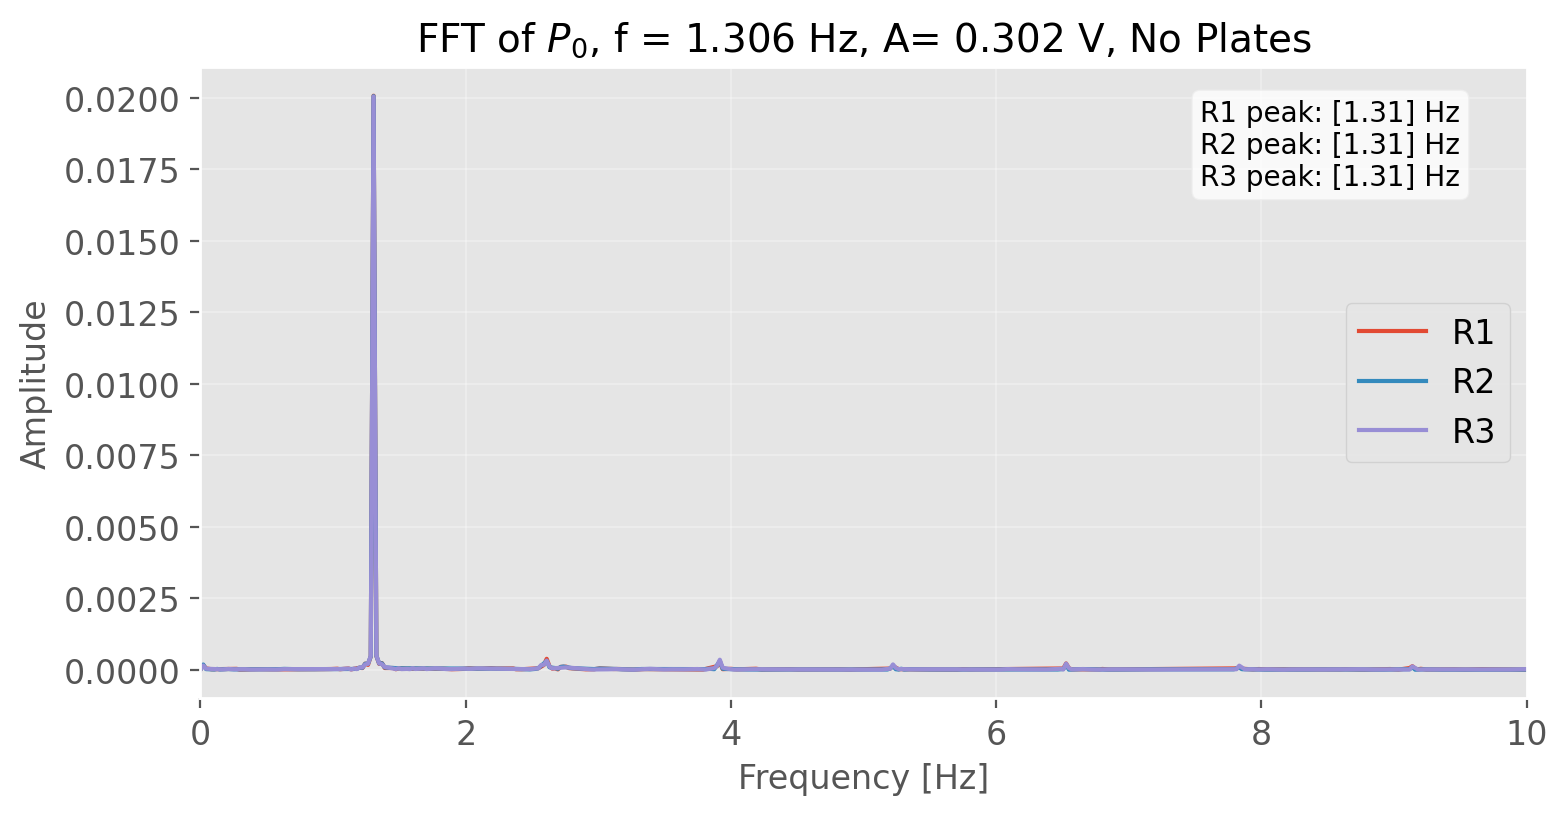

<Figure size 1280x960 with 0 Axes>

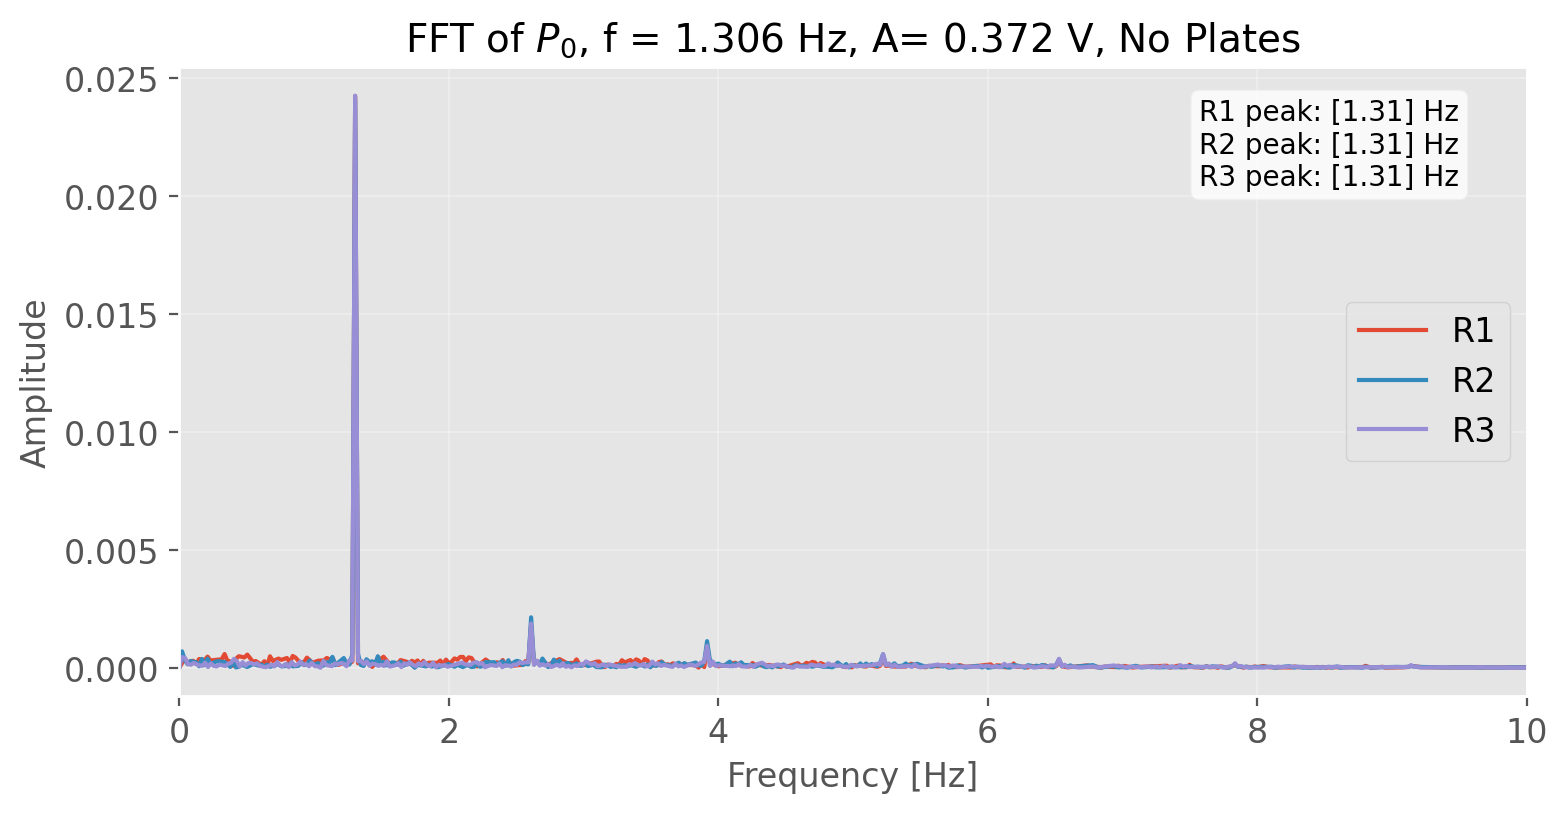

<Figure size 1280x960 with 0 Axes>

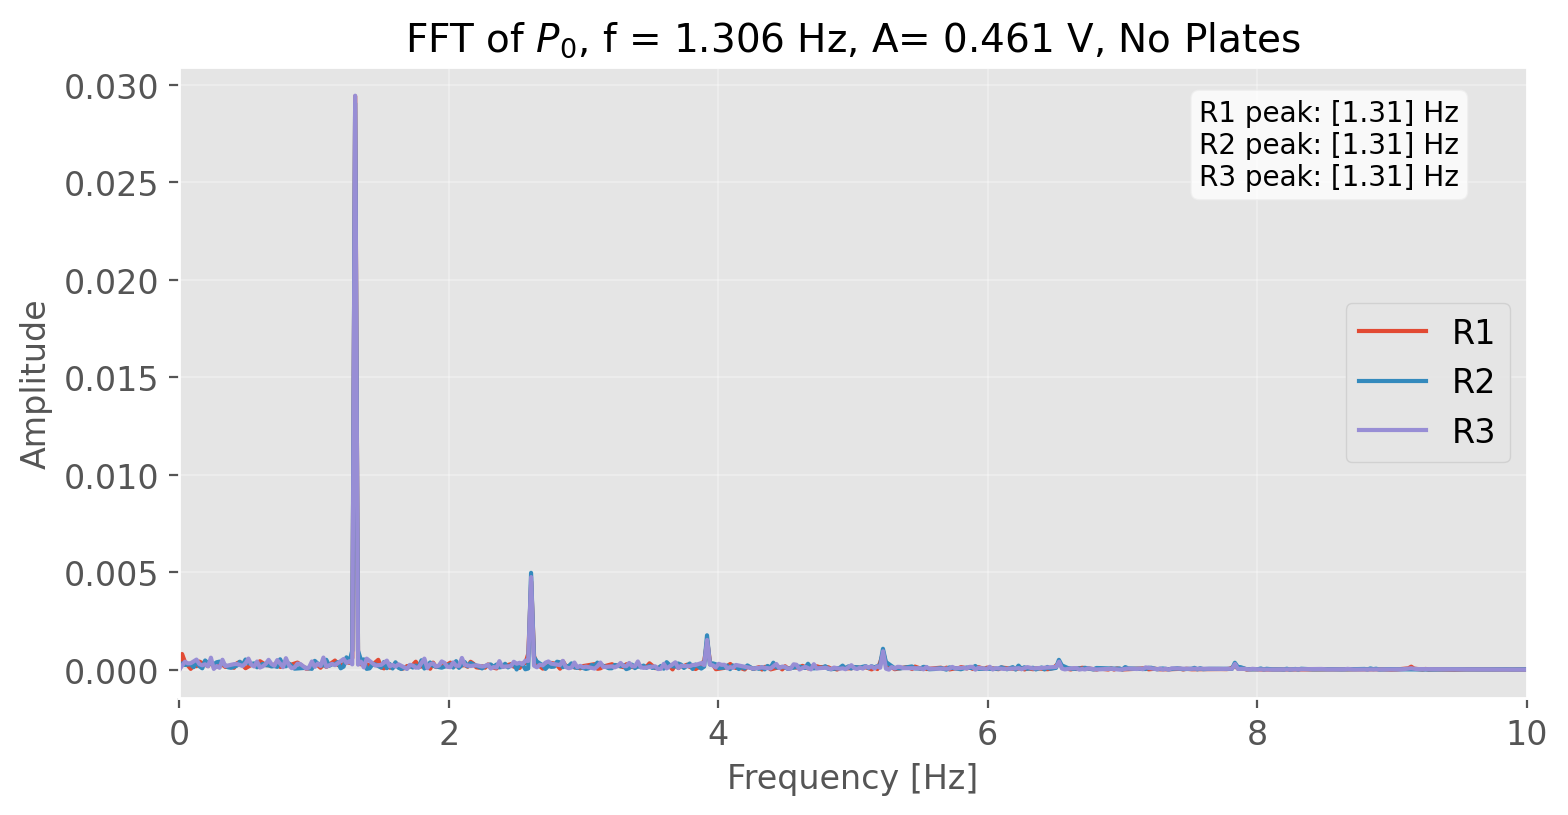

<Figure size 1280x960 with 0 Axes>

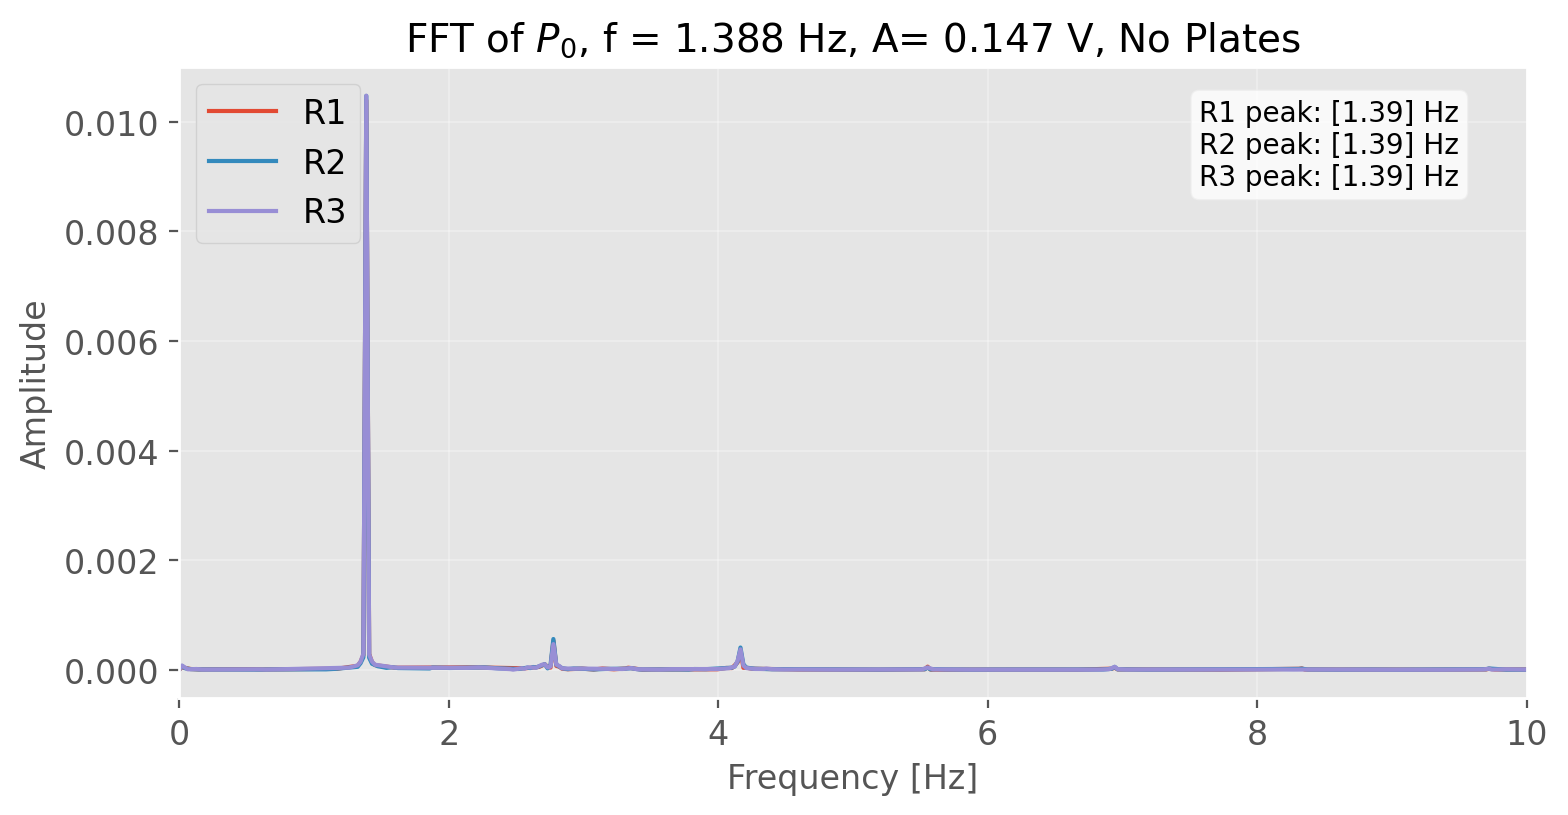

<Figure size 1280x960 with 0 Axes>

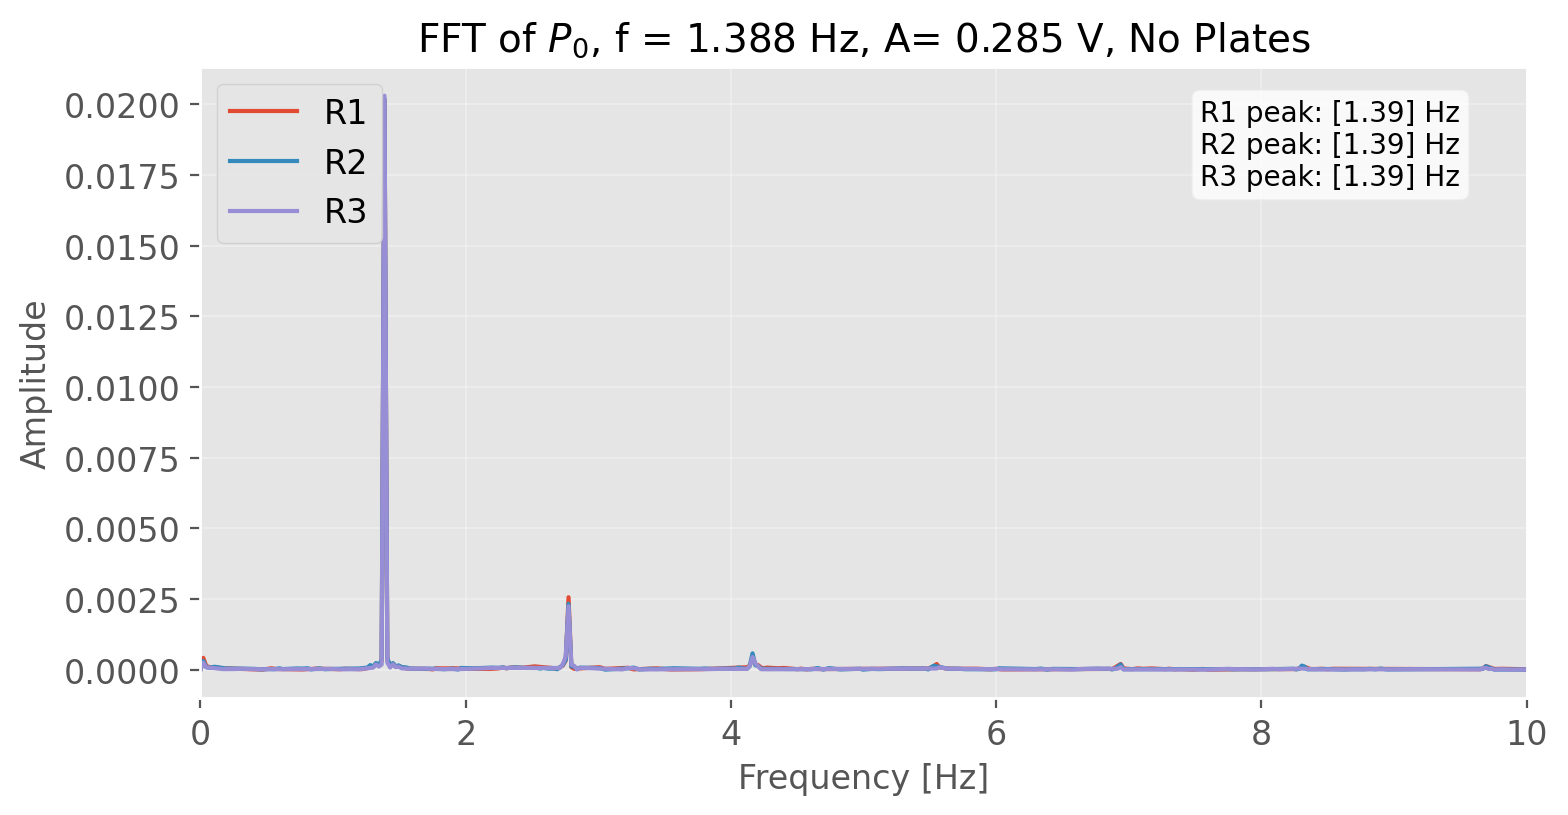

<Figure size 1280x960 with 0 Axes>

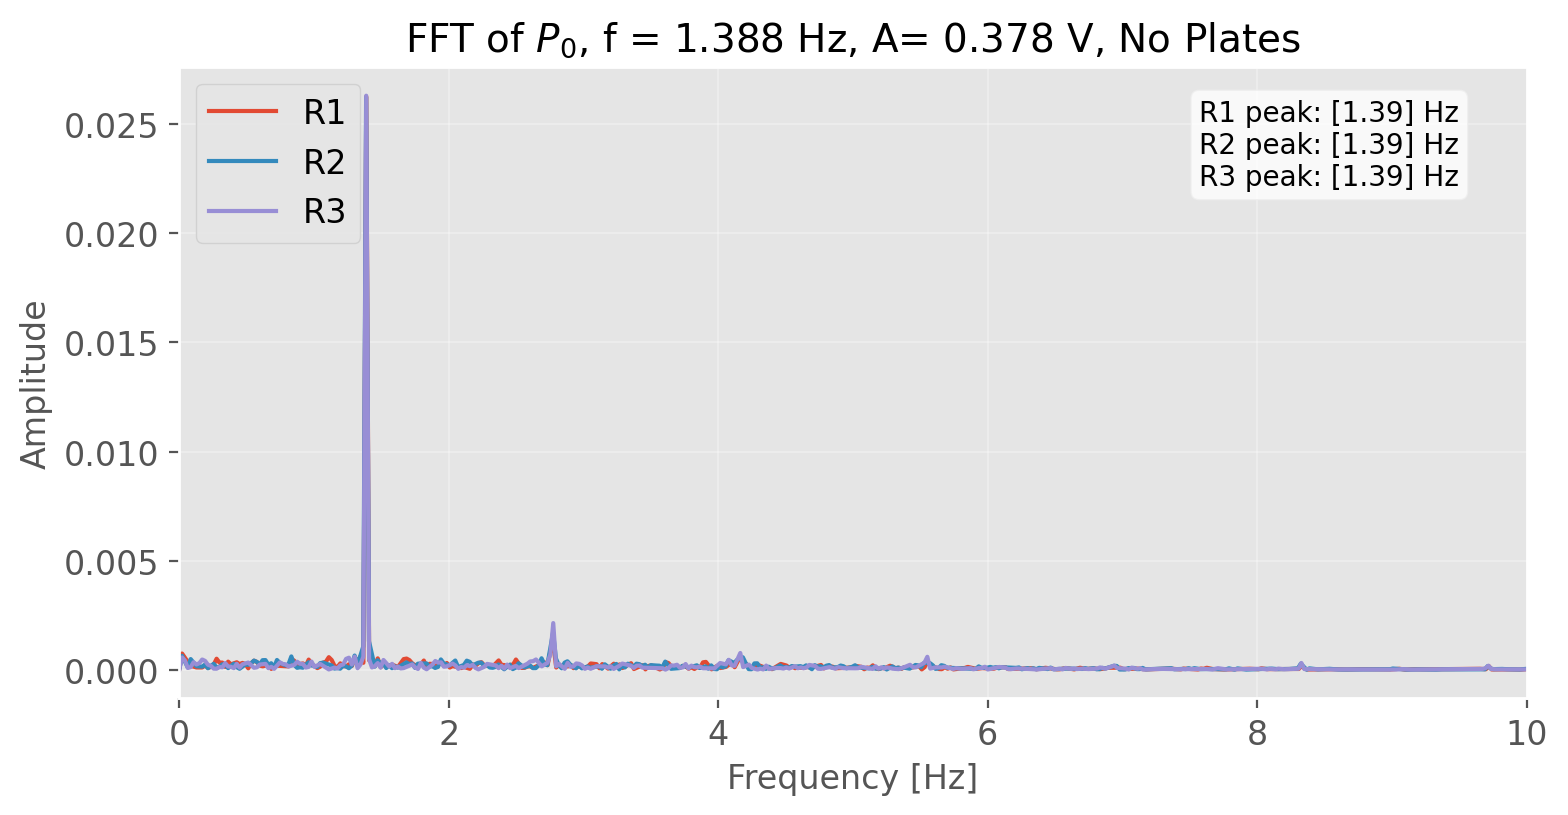

<Figure size 1280x960 with 0 Axes>

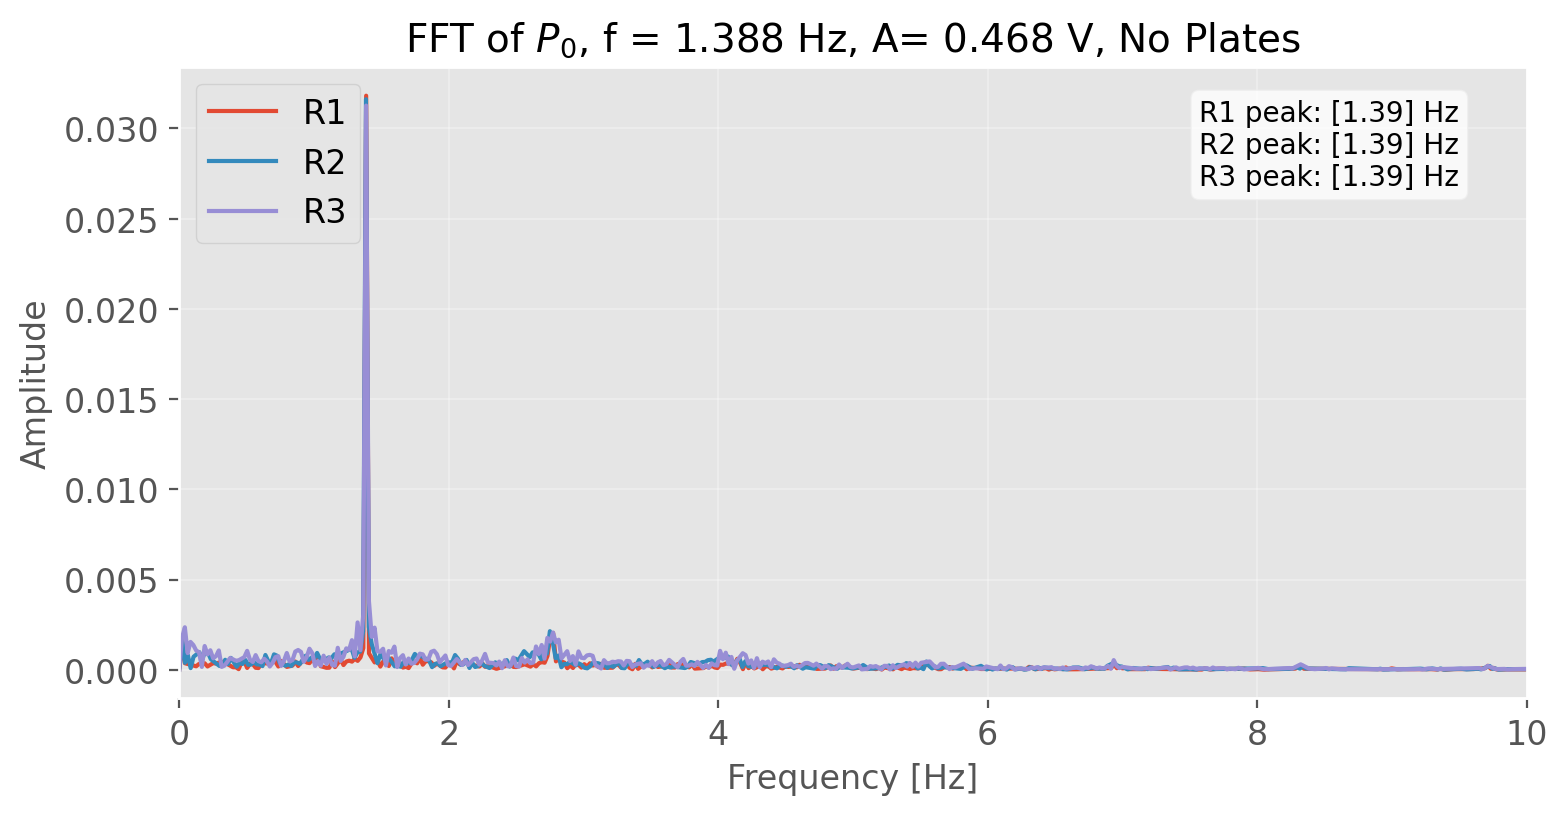

<Figure size 1280x960 with 0 Axes>

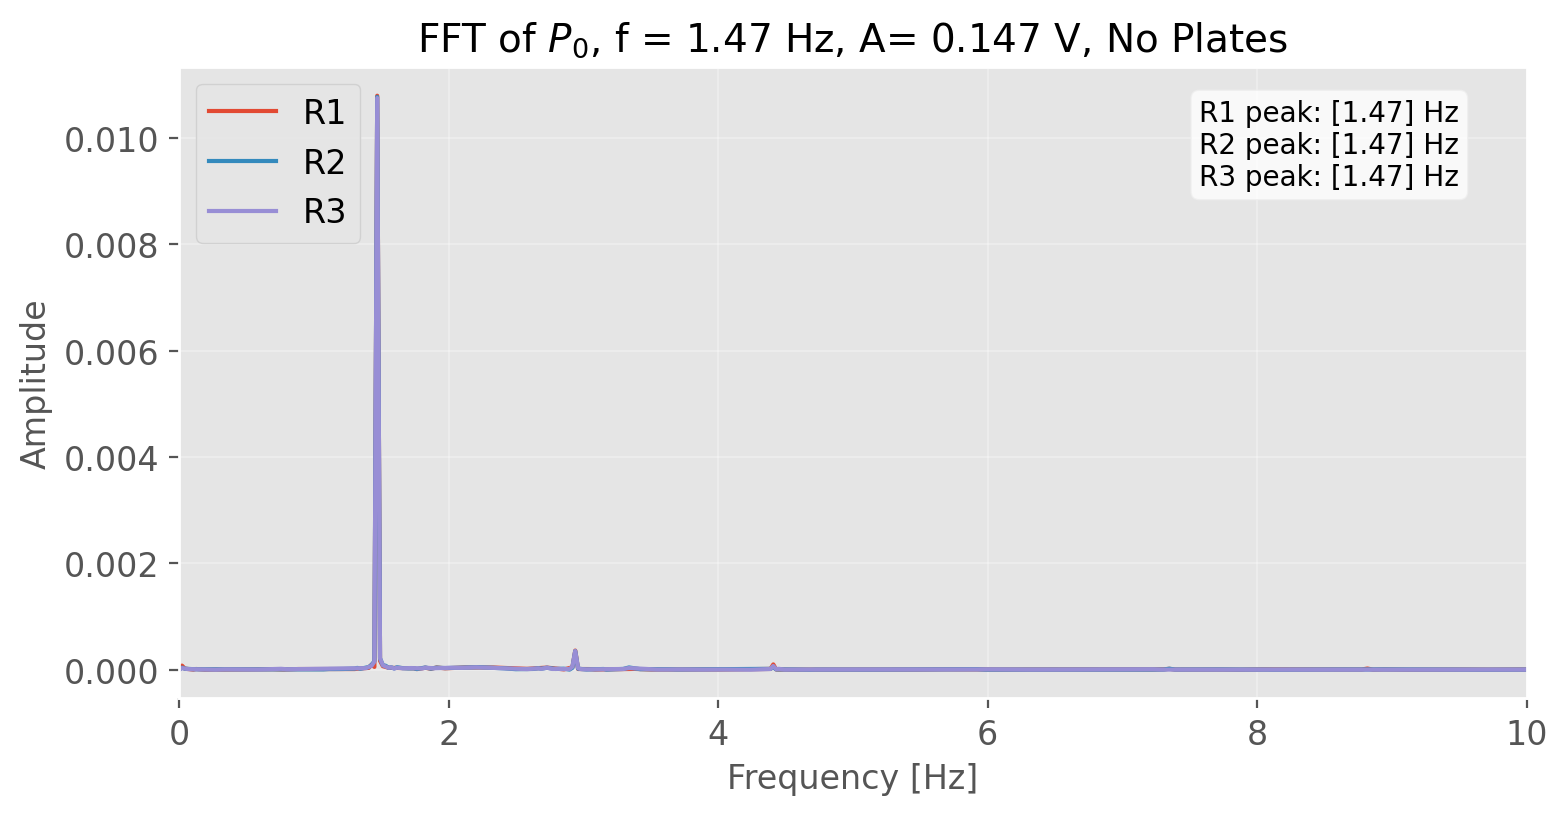

<Figure size 1280x960 with 0 Axes>

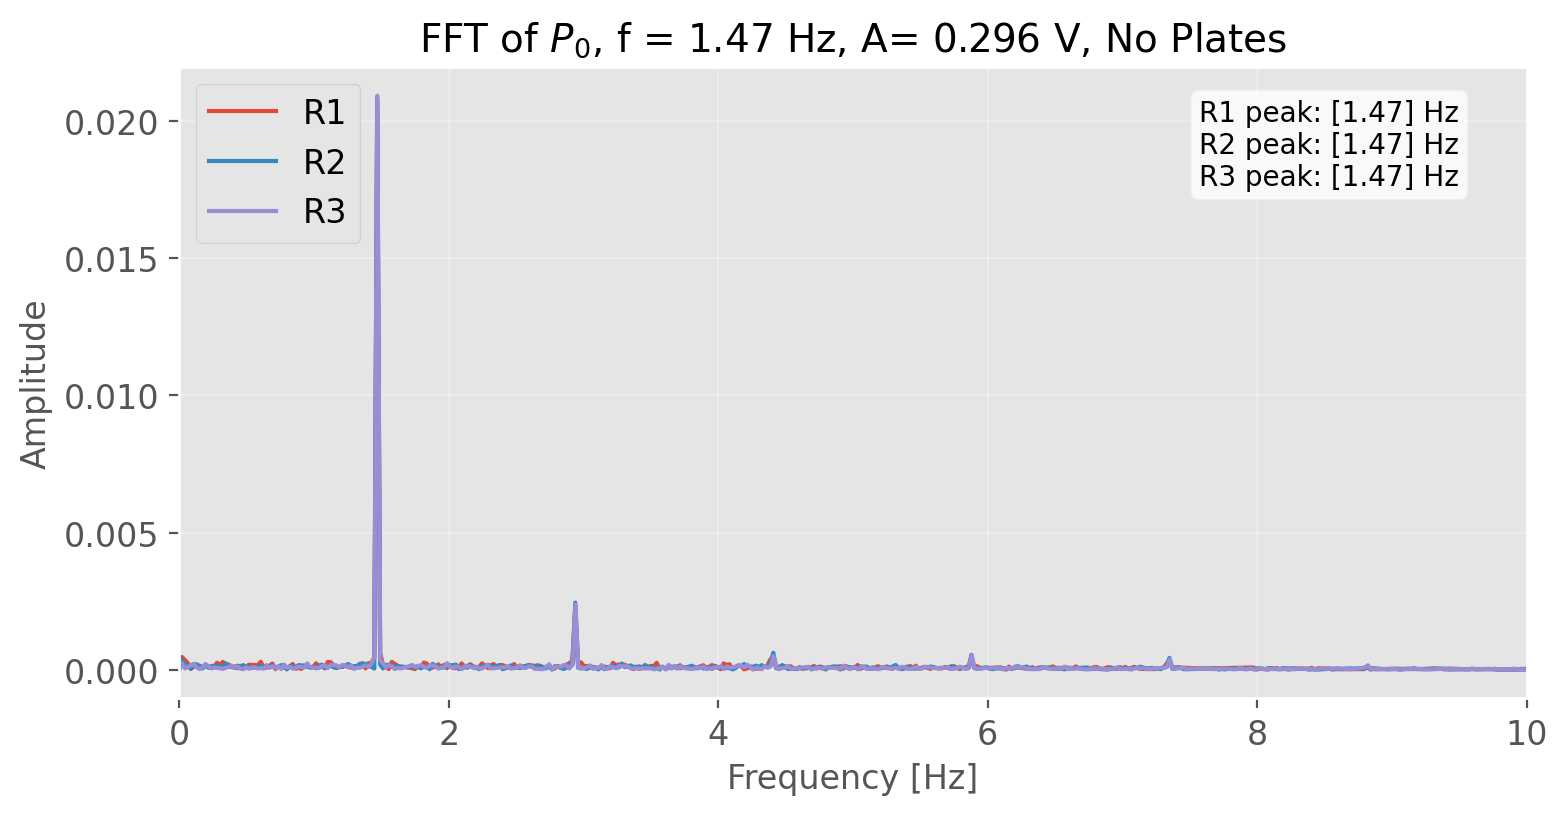

<Figure size 1280x960 with 0 Axes>

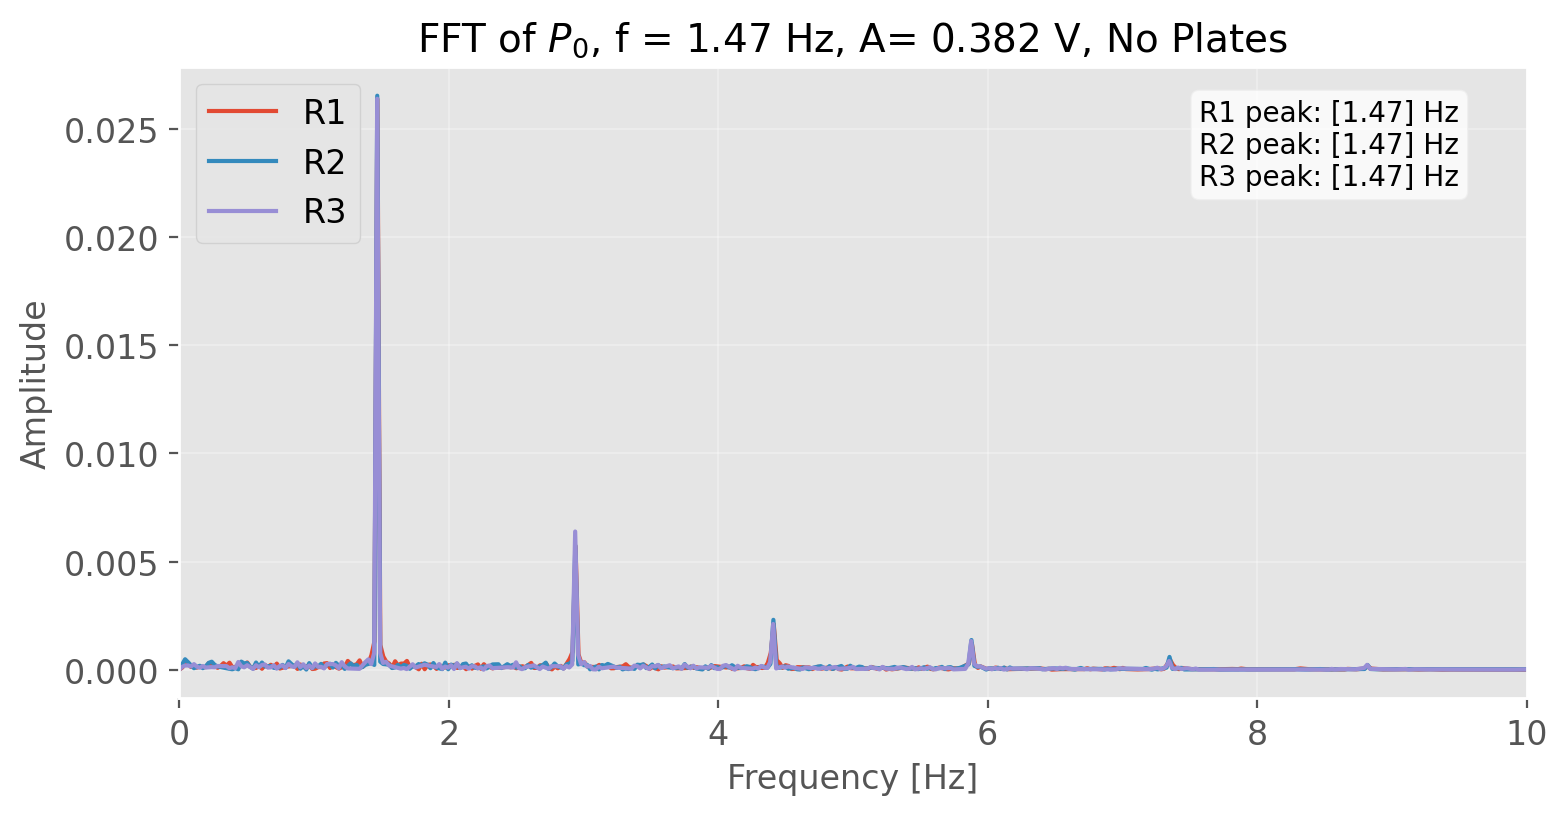

<Figure size 1280x960 with 0 Axes>

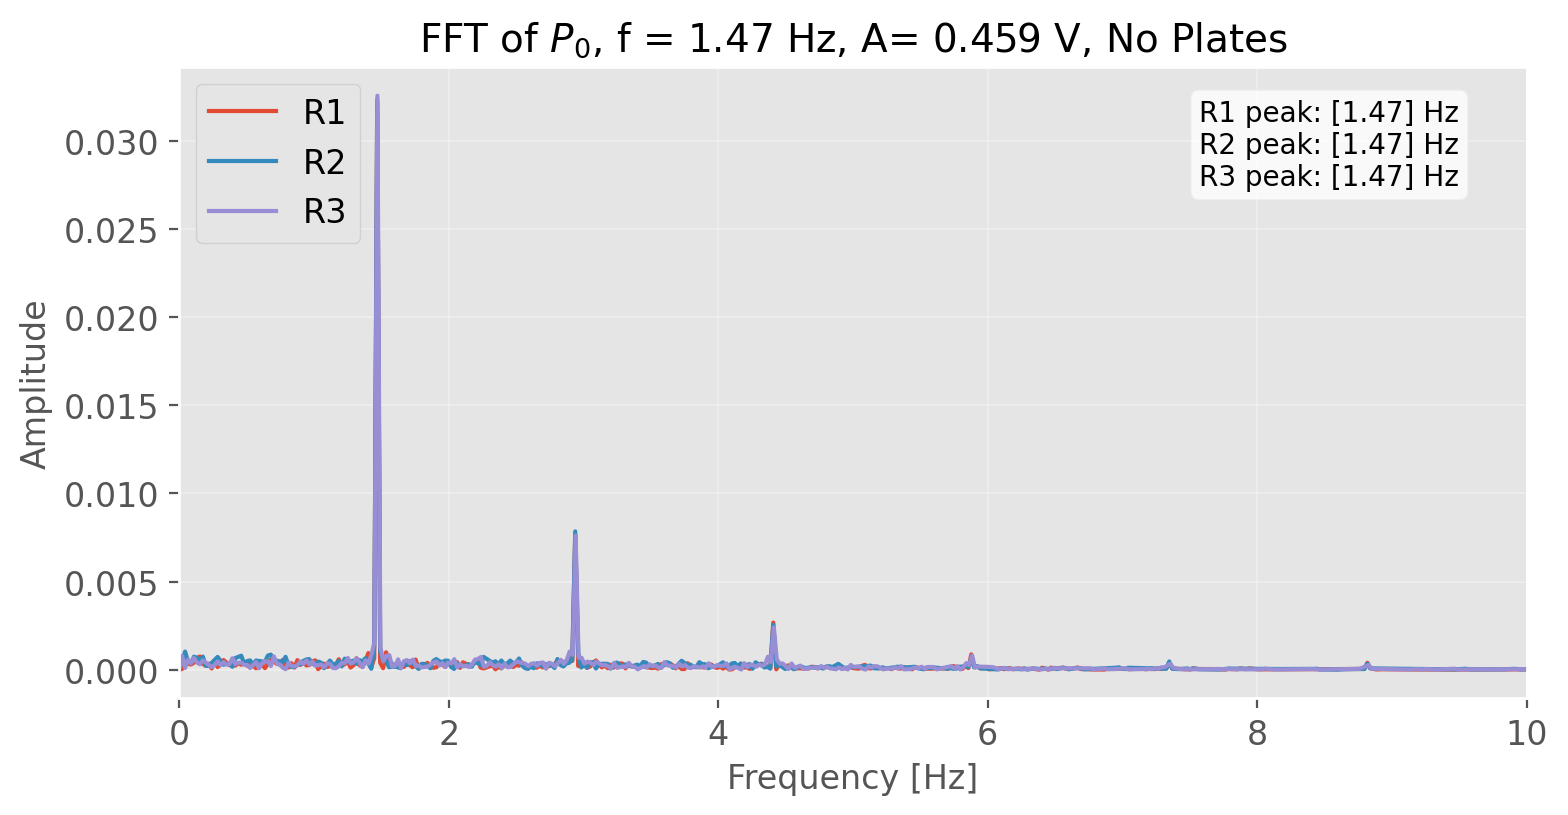

<Figure size 1280x960 with 0 Axes>

In [43]:
for i, f in enumerate(freqs30):
    for v in volts30[i]:
        p0_r1 = data30[f][v]["None"]["R1"]['P_0'].dropna().values
        p0_r2 = data30[f][v]["None"]["R2"]['P_0'].dropna().values
        p0_r3 = data30[f][v]["None"]["R3"]['P_0'].dropna().values
        plot_fft(p0_r1, p0_r2, p0_r3)